# Phase 4: Machine Learning Analysis for Energy Production
## ML in Energy Production - Thesis Analysis

This notebook contains comprehensive machine learning analysis for photovoltaic (PV) energy production datasets.

### Dataset Overview:
- **Dataset 1**: Targets - `tot_pv_ec`, `tot_pv_ec_inv3`, `total_pv_production`
- **Dataset 2**: Targets - `tot_pv_castelfidardo`, `tot_pv_i3p`, `tot_pv_ec_inv4`, `tot_pv_ec_inv1`, `tot_pv_ec_inv2`, `tot_pv_aule_r`, `total_pv_production`
- **Dataset 3**: Targets - `tot_pv_aule_p`, `tot_pv_aule_p_i2`, `tot_pv_aule_p_i1`, `total_pv_production`
- **Dataset 4**: Targets - `tot_pv_cit`
- **Merged I3P Dataset**: Targets - `tot_pv_i3p_est`, `tot_pv_i3p_ovest`, `total_pv_production`

### Analysis Approach:
For each dataset, we will:
1. Load and explore the data
2. Prepare features and targets
3. Apply multiple ML models (Linear Regression, Random Forest, XGBoost, SVR)
4. Compare model performances using appropriate metrics
5. Visualize results and provide insights

In [3]:


# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette(["#2e8b57", "#3cb371", "#66cdaa", "#98fb98", "#8fbc8f"])
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Utility functions for ML analysis (DEFAULT HYPERPARAMETERS)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from tqdm import tqdm
import time

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model performance"""
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

def prepare_features(df, target_columns, max_features=None):
    """Prepare features by removing target columns and non-numeric columns"""
    # Remove target columns and non-numeric columns
    feature_columns = df.columns.drop(target_columns + ['date'])
    
    # Select only numeric columns
    numeric_features = df[feature_columns].select_dtypes(include=[np.number])
    
    # Optional feature reduction for very large datasets
    if max_features and numeric_features.shape[1] > max_features:
        print(f"Reducing features from {numeric_features.shape[1]} to {max_features}")
        # Use variance threshold to remove low-variance features
        from sklearn.feature_selection import VarianceThreshold
        selector = VarianceThreshold(threshold=0.01)
        numeric_features = pd.DataFrame(
            selector.fit_transform(numeric_features),
            columns=numeric_features.columns[selector.get_support()]
        )
        
        # If still too many features, select top k by correlation
        if numeric_features.shape[1] > max_features and len(target_columns) > 0:
            first_target = target_columns[0]
            if first_target in df.columns:
                correlations = abs(numeric_features.corrwith(df[first_target], drop=True))
                top_features = correlations.nlargest(max_features).index
                numeric_features = numeric_features[top_features]
    
    return numeric_features

def train_and_evaluate_models(X_train, X_test, y_train, y_test, target_name):
    """Train multiple models with DEFAULT hyperparameters for speed"""
    # All models with default parameters
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'XGBoost': xgb.XGBRegressor(random_state=42, verbosity=0),
        #'Support Vector Regression': SVR()
    }
    
    results = []
    trained_models = {}
    
    print(f"Training {len(models)} models with default hyperparameters...")
    for model_name, model in tqdm(models.items(), desc="Training models"):
        start_time = time.time()
        
        try:
            # Train model
            model.fit(X_train, y_train)
            
            # Evaluate model
            result = evaluate_model(model, X_test, y_test, model_name)
            results.append(result)
            trained_models[model_name] = model
            
            training_time = time.time() - start_time
            print(f"{model_name} - R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.4f}, Time: {training_time:.2f}s")
            
        except Exception as e:
            print(f"Error training {model_name}: {str(e)}")
            training_time = time.time() - start_time
            print(f"{model_name} - FAILED, Time: {training_time:.2f}s")
    
    return results, trained_models

def plot_model_comparison(results, target_name):
    """Plot model comparison"""
    if not results:
        print("No results to plot")
        return
        
    df_results = pd.DataFrame(results)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Model Performance Comparison - {target_name}', fontsize=16)
    
    # R² Score
    axes[0, 0].bar(df_results['Model'], df_results['R²'])
    axes[0, 0].set_title('R² Score')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE
    axes[0, 1].bar(df_results['Model'], df_results['RMSE'])
    axes[0, 1].set_title('RMSE')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # MAE
    axes[1, 0].bar(df_results['Model'], df_results['MAE'])
    axes[1, 0].set_title('MAE')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # MSE
    axes[1, 1].bar(df_results['Model'], df_results['MSE'])
    axes[1, 1].set_title('MSE')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

def quick_model_summary(results, target_name):
    """Quick summary without plotting for faster execution"""
    if not results:
        print(f"No results for {target_name}")
        return
        
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results['R²'].idxmax()]
    print(f"Best model for {target_name}: {best_model['Model']} (R² = {best_model['R²']:.4f})")
    
    # Show all results in a compact format
    for _, row in df_results.iterrows():
        print(f"  {row['Model']:25} - R²: {row['R²']:.4f}, RMSE: {row['RMSE']:.4f}")

print("✅ Utility functions with default hyperparameters defined successfully!")

✅ Utility functions with default hyperparameters defined successfully!


## Dataset 1 Analysis
### Targets: `tot_pv_ec`, `tot_pv_ec_inv3`, `total_pv_production`

In [9]:
# Dataset 1 - Load and analyze
print("=" * 60)
print("DATASET 1 ANALYSIS")
print("=" * 60)

# Load dataset
df1 = pd.read_csv('/Users/parsa/Desktop/Phase1/final_preprocessed_dataset1.csv')

# Define target columns
target_columns_1 = ['tot_pv_ec', 'tot_pv_ec_inv3', 'total_pv_production']

print(f"Dataset shape: {df1.shape}")
print(f"Target columns: {target_columns_1}")
print(f"Available columns: {df1.columns.tolist()}")

# Check for missing values in target columns
print("\nMissing values in target columns:")
for col in target_columns_1:
    if col in df1.columns:
        missing = df1[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df1)*100:.2f}%)")
    else:
        print(f"  {col}: Column not found in dataset")

# Basic statistics for target columns
print("\nBasic statistics for target columns:")
available_targets_1 = [col for col in target_columns_1 if col in df1.columns]
if available_targets_1:
    print(df1[available_targets_1].describe())
else:
    print("No target columns found in dataset")

DATASET 1 ANALYSIS
Dataset shape: (248249, 29)
Target columns: ['tot_pv_ec', 'tot_pv_ec_inv3', 'total_pv_production']
Available columns: ['date', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'tot_pv_ec', 'tot_pv_ec_inv3', 'total_pv_production']

Missing values in target columns:
  tot_pv_ec: 0 (0.00%)
  tot_pv_ec_inv3: 0 (0.00%)
  total_pv_production: 0 (0.00%)

Basic statistics for target columns:
          tot_pv_ec  tot_pv_ec_inv3  total_pv_production
count  248249.00000        248249.0        248249.000000
mean        0.00509             0.0             0.012953
std         0.00863             0.0             0.020578
min         0.

Features shape: (248249, 25)
Feature columns: ['anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration']

Training models for: tot_pv_ec
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2832, RMSE: 0.0073, Time: 0.08s


Training models:  67%|██████▋   | 2/3 [01:31<00:45, 45.58s/it]

Random Forest - R²: 0.9605, RMSE: 0.0017, Time: 91.07s


Training models: 100%|██████████| 3/3 [01:31<00:00, 30.53s/it]

XGBoost - R²: 0.8912, RMSE: 0.0028, Time: 0.42s


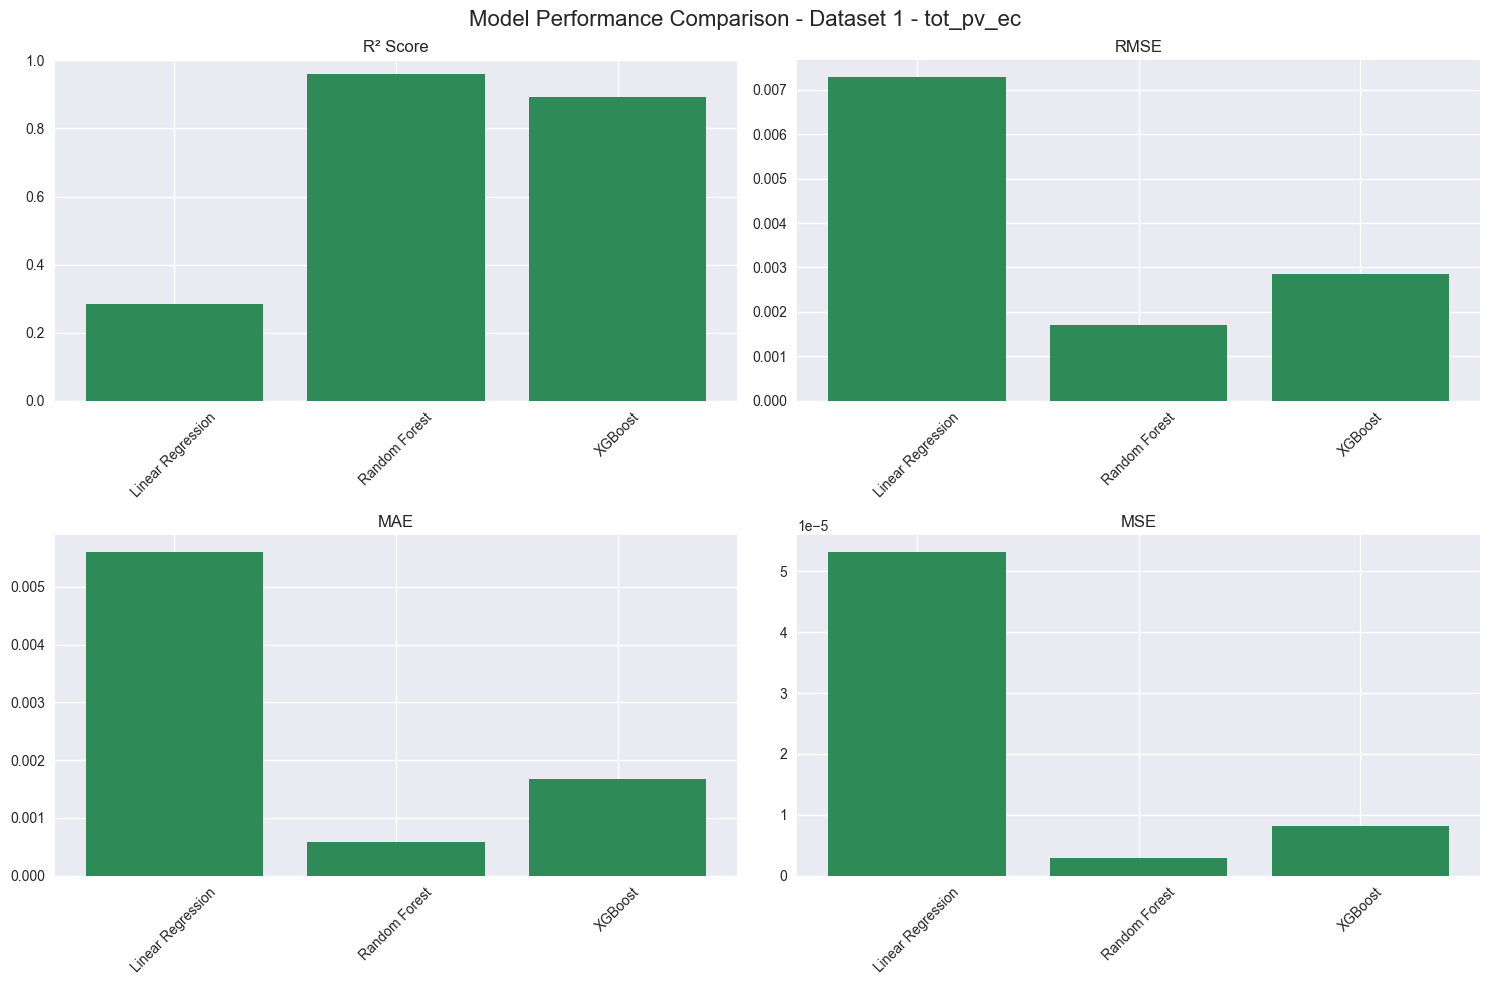


Training models for: tot_pv_ec_inv3
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 1.0000, RMSE: 0.0000, Time: 0.06s


Training models: 100%|██████████| 3/3 [00:00<00:00,  5.41it/s]

Random Forest - R²: 1.0000, RMSE: 0.0000, Time: 0.35s
XGBoost - R²: 1.0000, RMSE: 0.0000, Time: 0.14s


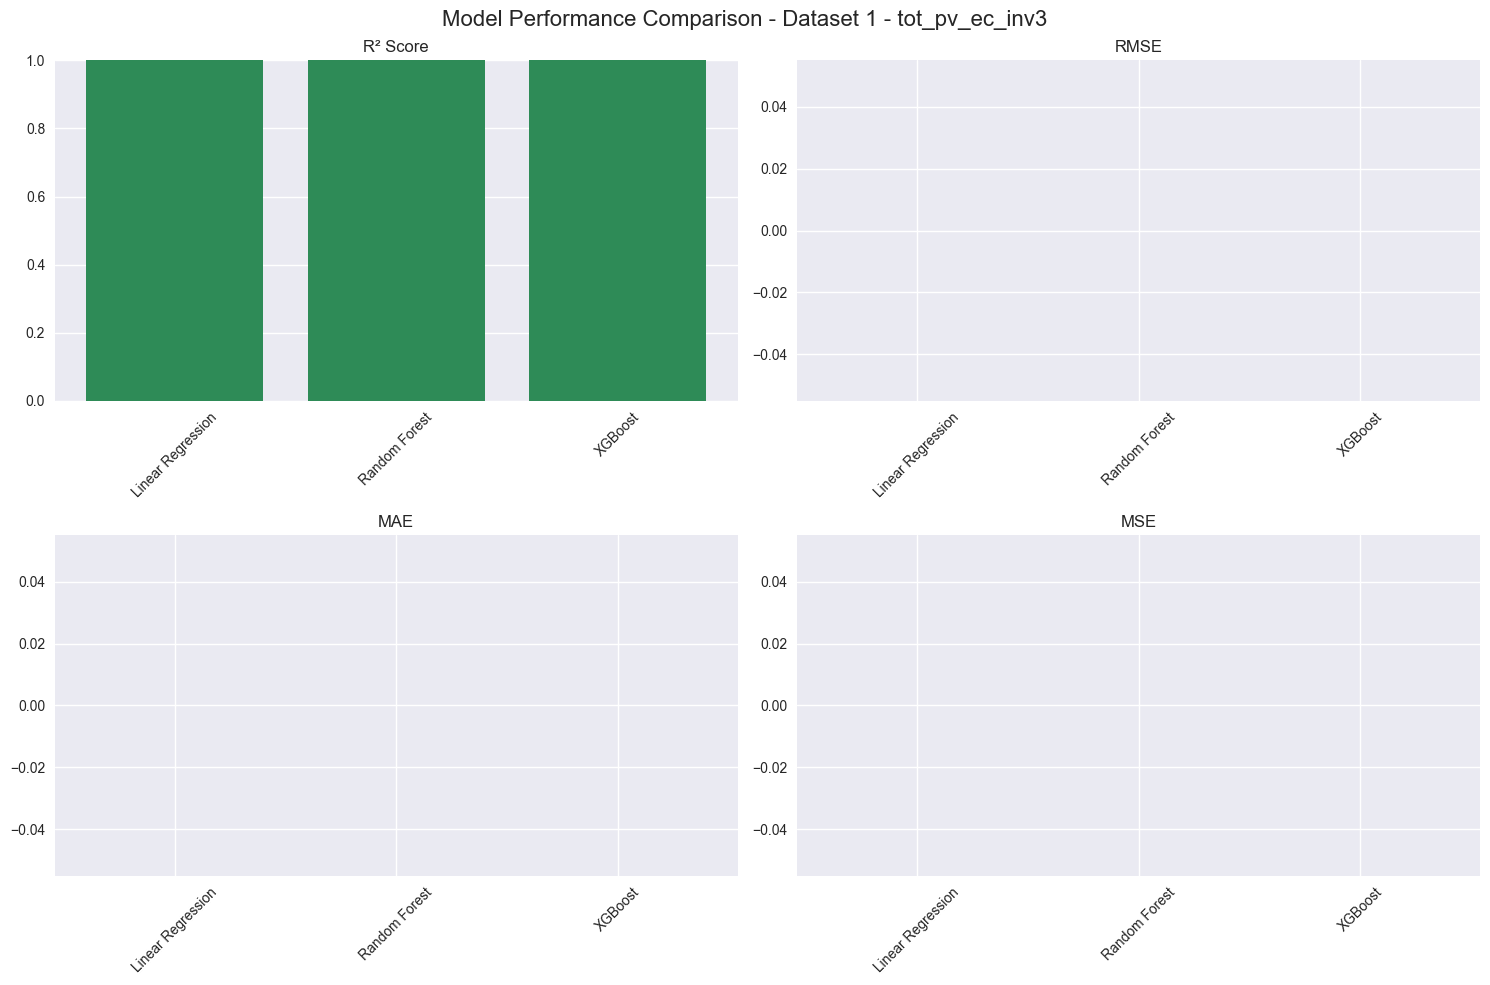


Training models for: total_pv_production
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2287, RMSE: 0.0180, Time: 0.06s


Training models:  67%|██████▋   | 2/3 [01:21<00:40, 40.94s/it]

Random Forest - R²: 0.9625, RMSE: 0.0040, Time: 81.83s


Training models: 100%|██████████| 3/3 [01:22<00:00, 27.43s/it]

XGBoost - R²: 0.9052, RMSE: 0.0063, Time: 0.41s


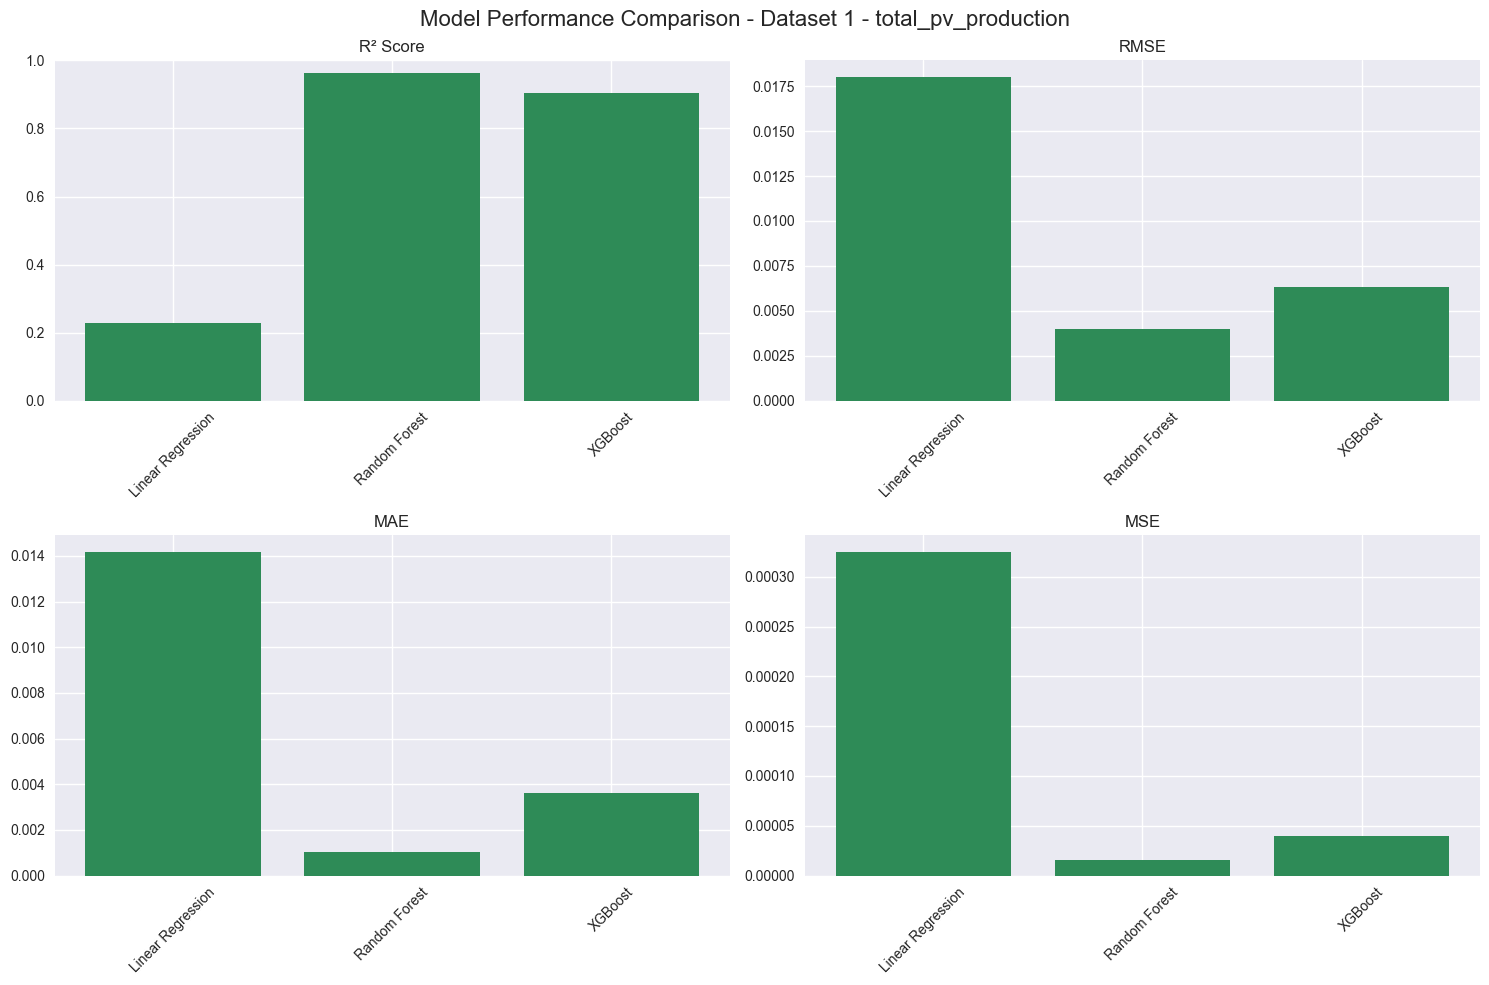


DATASET 1 SUMMARY
tot_pv_ec: Best model is Random Forest with R² = 0.9605
tot_pv_ec_inv3: Best model is Linear Regression with R² = 1.0000
total_pv_production: Best model is Random Forest with R² = 0.9625


In [45]:
# Dataset 1 - ML Model Training and Evaluation
available_targets_1 = [col for col in target_columns_1 if col in df1.columns]
dataset1_results = {}

if available_targets_1:
    # Prepare features
    X1 = prepare_features(df1, available_targets_1)
    
    # Scale features
    scaler1 = StandardScaler()
    X1_scaled = scaler1.fit_transform(X1)
    
    print(f"Features shape: {X1_scaled.shape}")
    print(f"Feature columns: {X1.columns.tolist()}")
    
    # Train and evaluate models for each target
    for target in available_targets_1:
        print(f"\n{'='*50}")
        print(f"Training models for: {target}")
        print('='*50)
        
        y = df1[target]
        
        # Remove rows with missing target values
        mask = ~y.isnull()
        X_clean = X1_scaled[mask]
        y_clean = y[mask]
        
        if len(y_clean) > 0:
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            
            # Train and evaluate models
            results, models = train_and_evaluate_models(X_train, X_test, y_train, y_test, target)
            dataset1_results[target] = {'results': results, 'models': models}
            
            # Plot comparison
            plot_model_comparison(results, f"Dataset 1 - {target}")
        else:
            print(f"No valid data for target: {target}")

print("\n" + "="*60)
print("DATASET 1 SUMMARY")
print("="*60)
for target, data in dataset1_results.items():
    best_model = max(data['results'], key=lambda x: x['R²'])
    print(f"{target}: Best model is {best_model['Model']} with R² = {best_model['R²']:.4f}")

## Dataset 2 Analysis
### Targets: `tot_pv_castelfidardo`, `tot_pv_i3p`, `tot_pv_ec_inv4`, `tot_pv_ec_inv1`, `tot_pv_ec_inv2`, `tot_pv_aule_r`, `total_pv_production`

In [8]:
# Dataset 2 - Load and analyze
print("=" * 60)
print("DATASET 2 ANALYSIS")
print("=" * 60)

# Load dataset
df2 = pd.read_csv('/Users/parsa/Desktop/Phase1/final_preprocessed_dataset2.csv')

# Define target columns
target_columns_2 = ['tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv4', 
                    'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_aule_r', 'total_pv_production']

print(f"Dataset shape: {df2.shape}")
print(f"Target columns: {target_columns_2}")
print(f"Available columns: {df2.columns.tolist()}")

# Check for missing values in target columns
print("\nMissing values in target columns:")
for col in target_columns_2:
    if col in df2.columns:
        missing = df2[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df2)*100:.2f}%)")
    else:
        print(f"  {col}: Column not found in dataset")

# Basic statistics for target columns
print("\nBasic statistics for target columns:")
available_targets_2 = [col for col in target_columns_2 if col in df2.columns]
if available_targets_2:
    print(df2[available_targets_2].describe())
else:
    print("No target columns found in dataset")

DATASET 2 ANALYSIS
Dataset shape: (197770, 33)
Target columns: ['tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv4', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_aule_r', 'total_pv_production']
Available columns: ['date', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv4', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_aule_r', 'total_pv_production']

Missing values in target columns:
  tot_pv_castelfidardo: 0 (0.00%)
  tot_pv_i3p: 0 (0.00%)
  tot_pv_ec_inv4: 0 (0.00%)
  tot_pv_ec_inv1: 0 (0.00%)
  tot_pv_ec_inv2: 0 (0.00%)
  tot_pv_aule_r: 0 (0.00%)
  total_pv_production: 0 (0.00%)

Basic

DATASET 2 ANALYSIS (WITH PLOTS)
Features shape: (197770, 25)
Number of features: 25

Training models for: tot_pv_castelfidardo (1/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2887, RMSE: 19.8203, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [00:57<00:28, 28.75s/it]

Random Forest - R²: 0.9596, RMSE: 4.7244, Time: 57.46s


Training models: 100%|██████████| 3/3 [00:57<00:00, 19.29s/it]

XGBoost - R²: 0.9164, RMSE: 6.7948, Time: 0.38s


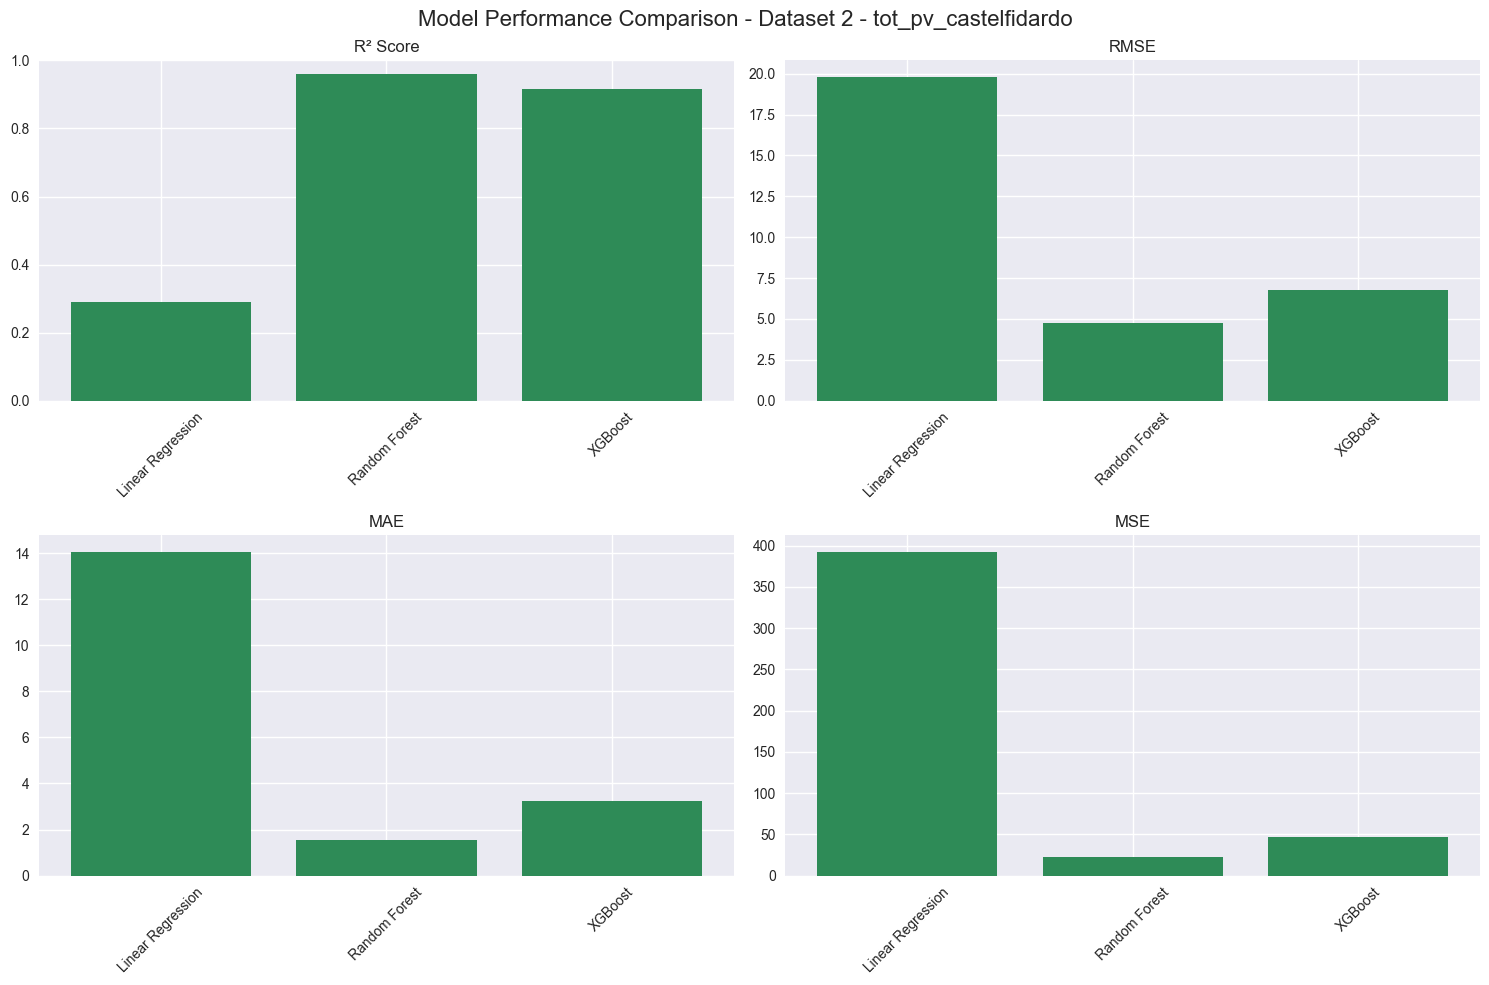


Training models for: tot_pv_i3p (2/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3208, RMSE: 3.1922, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [00:51<00:25, 25.53s/it]

Random Forest - R²: 0.9536, RMSE: 0.8342, Time: 51.02s


Training models: 100%|██████████| 3/3 [00:51<00:00, 17.17s/it]

XGBoost - R²: 0.9120, RMSE: 1.1491, Time: 0.43s


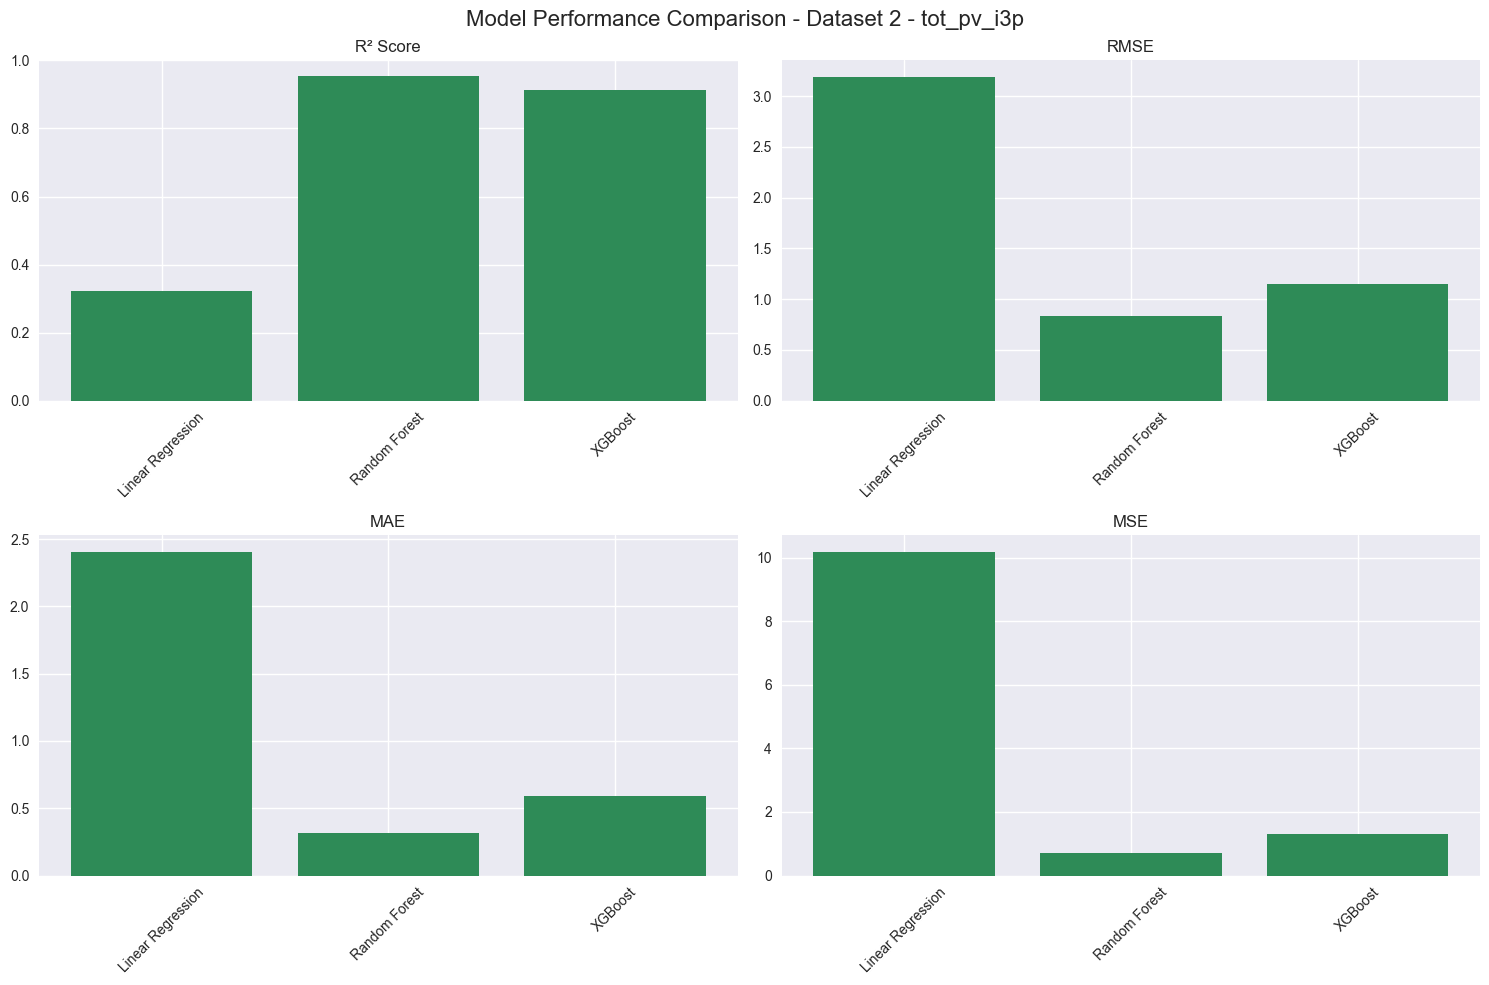


Training models for: tot_pv_ec_inv4 (3/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3086, RMSE: 1.3723, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [01:19<00:39, 39.59s/it]

Random Forest - R²: 0.9084, RMSE: 0.4996, Time: 79.14s


Training models: 100%|██████████| 3/3 [01:19<00:00, 26.52s/it]

XGBoost - R²: 0.8320, RMSE: 0.6765, Time: 0.38s


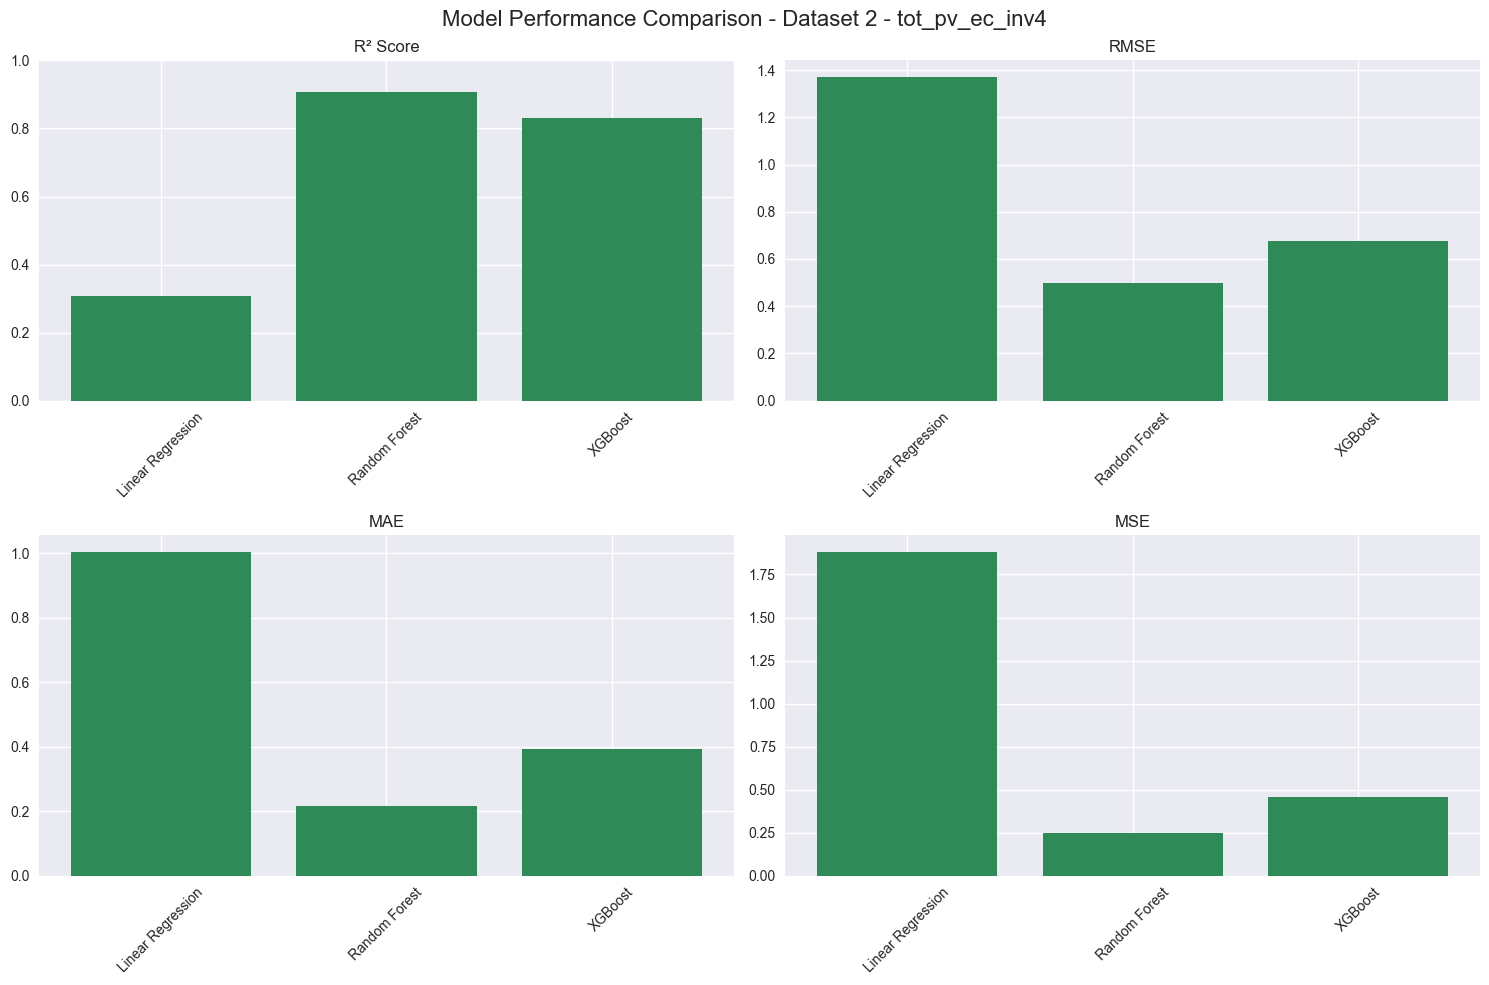


Training models for: tot_pv_ec_inv1 (4/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2809, RMSE: 1.4131, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [01:17<00:38, 38.74s/it]

Random Forest - R²: 0.9100, RMSE: 0.5000, Time: 77.43s


Training models: 100%|██████████| 3/3 [01:17<00:00, 25.95s/it]

XGBoost - R²: 0.8362, RMSE: 0.6745, Time: 0.38s


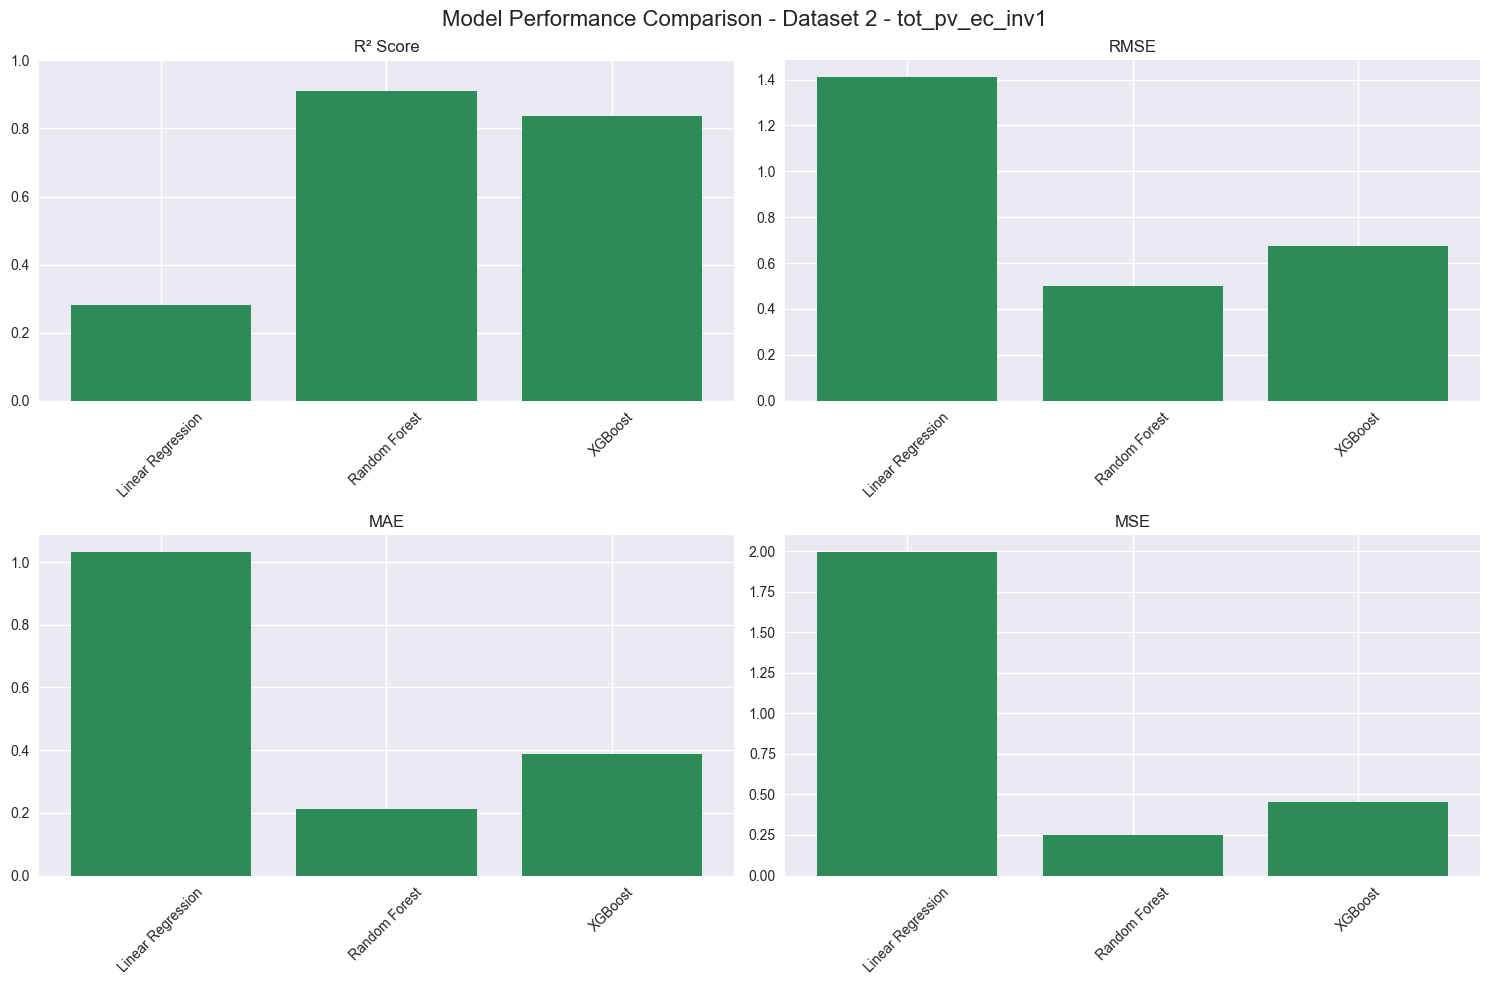


Training models for: tot_pv_ec_inv2 (5/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2603, RMSE: 2.2968, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [01:24<00:42, 42.01s/it]

Random Forest - R²: 0.9344, RMSE: 0.6838, Time: 83.97s


Training models: 100%|██████████| 3/3 [01:24<00:00, 28.14s/it]

XGBoost - R²: 0.8520, RMSE: 1.0274, Time: 0.38s


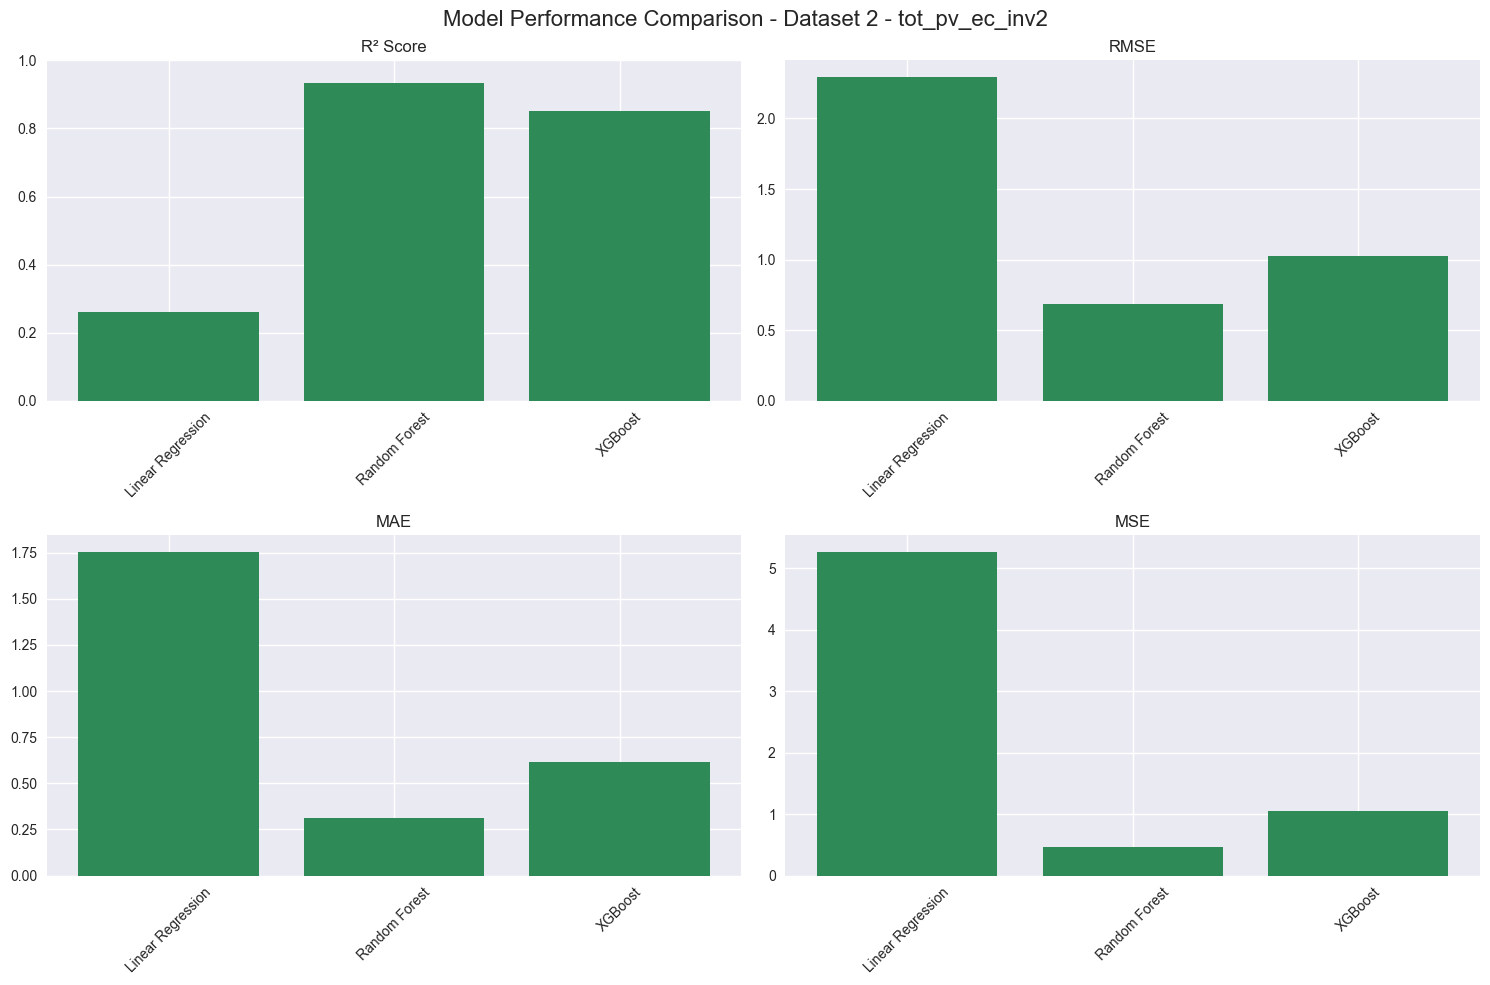


Training models for: tot_pv_aule_r (6/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2902, RMSE: 1.5259, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [00:51<00:25, 25.89s/it]

Random Forest - R²: 0.9771, RMSE: 0.2738, Time: 51.73s


Training models: 100%|██████████| 3/3 [00:52<00:00, 17.39s/it]

XGBoost - R²: 0.9482, RMSE: 0.4124, Time: 0.37s


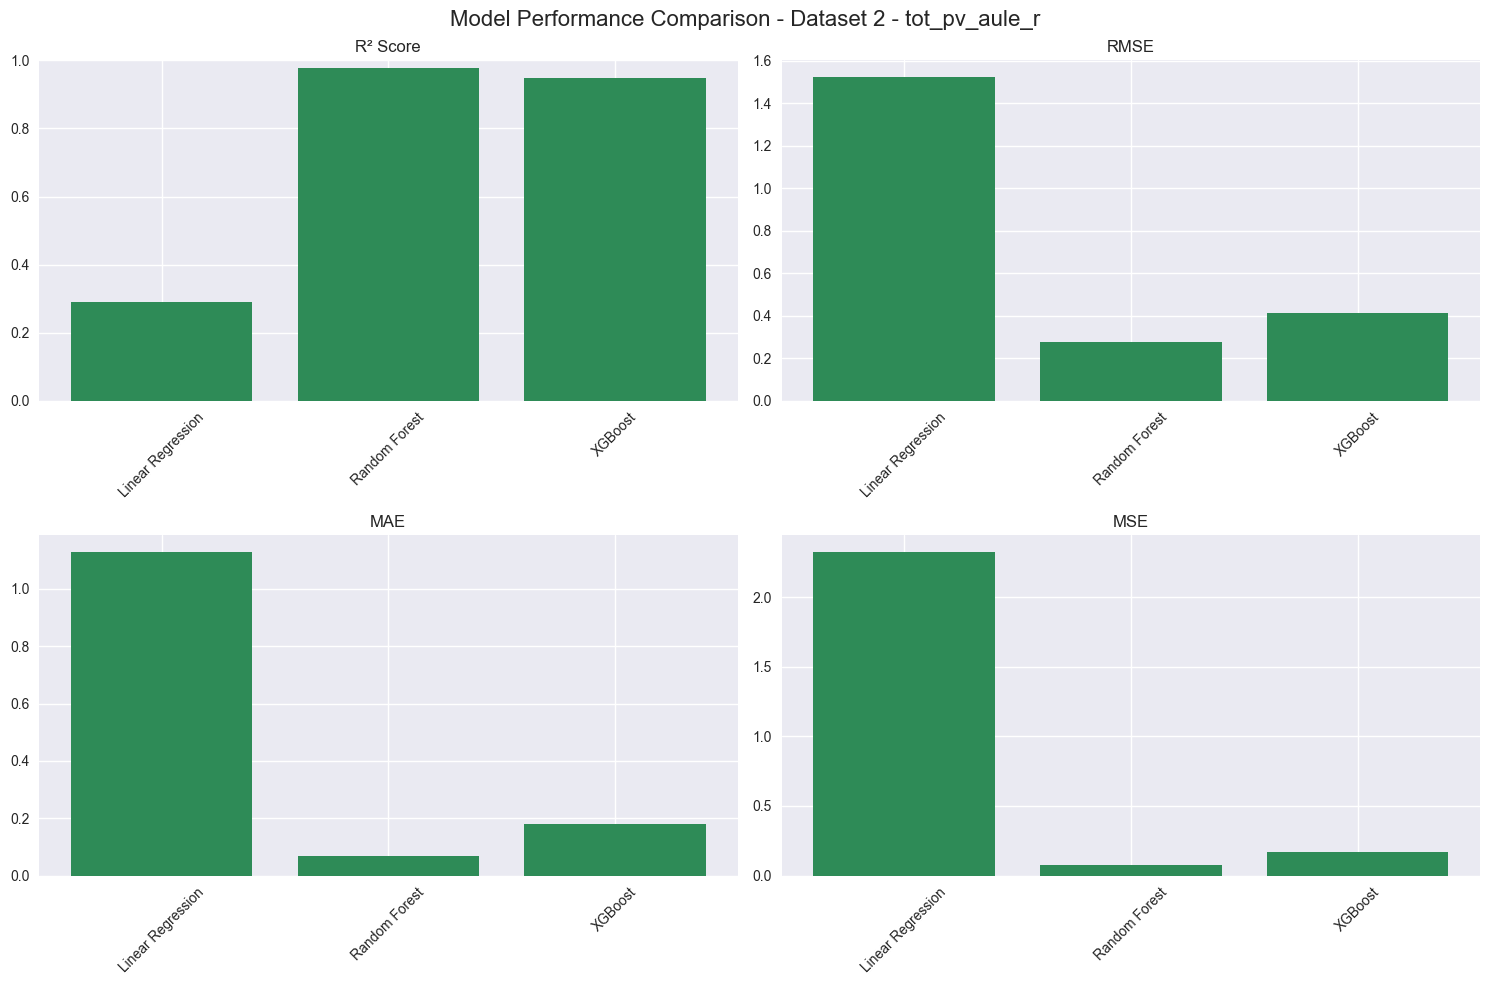


Training models for: total_pv_production (7/7)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3644, RMSE: 11.0732, Time: 0.05s


Training models:  67%|██████▋   | 2/3 [01:42<00:51, 51.18s/it]

Random Forest - R²: 0.9617, RMSE: 2.7186, Time: 102.30s


Training models: 100%|██████████| 3/3 [01:42<00:00, 34.24s/it]

XGBoost - R²: 0.9195, RMSE: 3.9417, Time: 0.38s


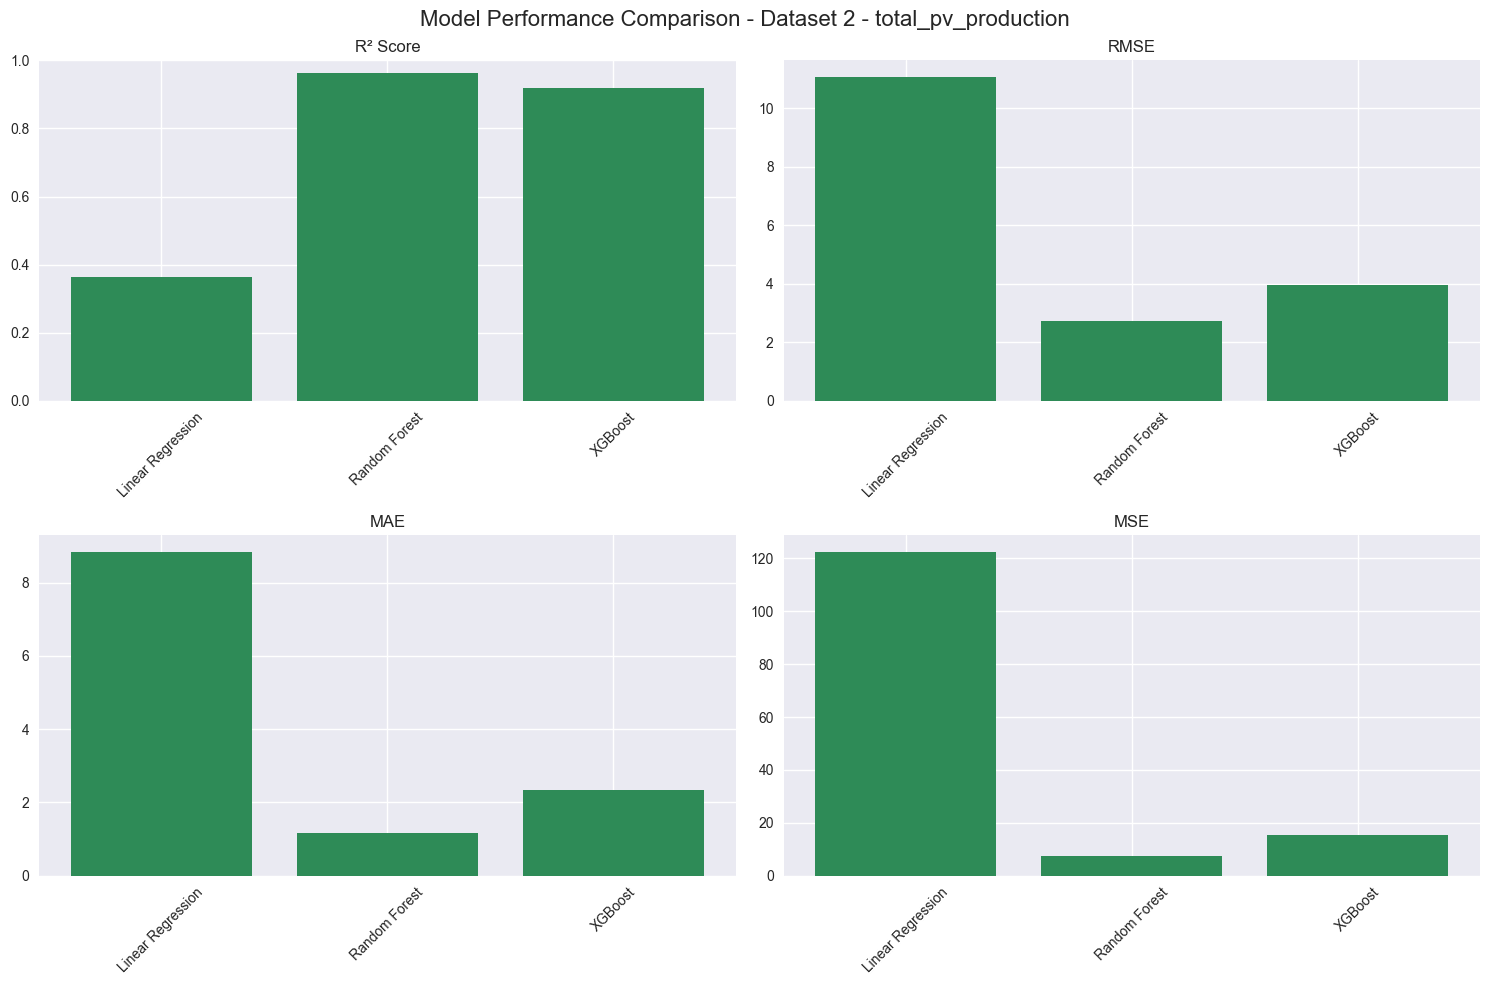


DATASET 2 SUMMARY
tot_pv_castelfidardo: Best model is Random Forest with R² = 0.9596
tot_pv_i3p: Best model is Random Forest with R² = 0.9536
tot_pv_ec_inv4: Best model is Random Forest with R² = 0.9084
tot_pv_ec_inv1: Best model is Random Forest with R² = 0.9100
tot_pv_ec_inv2: Best model is Random Forest with R² = 0.9344
tot_pv_aule_r: Best model is Random Forest with R² = 0.9771
total_pv_production: Best model is Random Forest with R² = 0.9617


In [47]:
# Dataset 2 - ML Model Training and Evaluation (WITH PLOTS)
print("=" * 60)
print("DATASET 2 ANALYSIS (WITH PLOTS)")
print("=" * 60)

available_targets_2 = [col for col in target_columns_2 if col in df2.columns]
dataset2_results = {}

if available_targets_2:
    # Prepare features (no feature reduction for default approach)
    X2 = prepare_features(df2, available_targets_2)
    
    # Scale features
    scaler2 = StandardScaler()
    X2_scaled = scaler2.fit_transform(X2)
    
    print(f"Features shape: {X2_scaled.shape}")
    print(f"Number of features: {X2_scaled.shape[1]}")
    
    # Train and evaluate models for each target
    for i, target in enumerate(available_targets_2):
        print(f"\n{'='*50}")
        print(f"Training models for: {target} ({i+1}/{len(available_targets_2)})")
        print('='*50)
        
        y = df2[target]
        
        # Remove rows with missing target values
        mask = ~y.isnull()
        X_clean = X2_scaled[mask]
        y_clean = y[mask]
        
        if len(y_clean) > 50:  # Minimum samples required
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            
            # Train and evaluate models with default hyperparameters
            results, models = train_and_evaluate_models(X_train, X_test, y_train, y_test, target)
            dataset2_results[target] = {'results': results, 'models': models}
            
            # Plot comparison same as Dataset 1
            plot_model_comparison(results, f"Dataset 2 - {target}")
            
        else:
            print(f"Insufficient data for target: {target} (only {len(y_clean)} samples)")

print("\n" + "="*60)
print("DATASET 2 SUMMARY")
print("="*60)
for target, data in dataset2_results.items():
    if data['results']:
        best_model = max(data['results'], key=lambda x: x['R²'])
        print(f"{target}: Best model is {best_model['Model']} with R² = {best_model['R²']:.4f}")

## Dataset 3 Analysis
### Targets: `tot_pv_aule_p`, `tot_pv_aule_p_i2`, `tot_pv_aule_p_i1`, `total_pv_production`

In [7]:
# Dataset 3 - Load and analyze
print("=" * 60)
print("DATASET 3 ANALYSIS")
print("=" * 60)

# Load dataset
df3 = pd.read_csv('/Users/parsa/Desktop/Phase1/final_preprocessed_dataset3.csv')

# Define target columns
target_columns_3 = ['tot_pv_aule_p', 'tot_pv_aule_p_i2', 'tot_pv_aule_p_i1', 'total_pv_production']

print(f"Dataset shape: {df3.shape}")
print(f"Target columns: {target_columns_3}")
print(f"Available columns: {df3.columns.tolist()}")

# Check for missing values in target columns
print("\nMissing values in target columns:")
for col in target_columns_3:
    if col in df3.columns:
        missing = df3[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df3)*100:.2f}%)")
    else:
        print(f"  {col}: Column not found in dataset")

# Basic statistics for target columns
print("\nBasic statistics for target columns:")
available_targets_3 = [col for col in target_columns_3 if col in df3.columns]
if available_targets_3:
    print(df3[available_targets_3].describe())
else:
    print("No target columns found in dataset")

DATASET 3 ANALYSIS
Dataset shape: (74735, 30)
Target columns: ['tot_pv_aule_p', 'tot_pv_aule_p_i2', 'tot_pv_aule_p_i1', 'total_pv_production']
Available columns: ['date', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'tot_pv_aule_p', 'tot_pv_aule_p_i2', 'tot_pv_aule_p_i1', 'total_pv_production']

Missing values in target columns:
  tot_pv_aule_p: 0 (0.00%)
  tot_pv_aule_p_i2: 0 (0.00%)
  tot_pv_aule_p_i1: 0 (0.00%)
  total_pv_production: 0 (0.00%)

Basic statistics for target columns:
       tot_pv_aule_p  tot_pv_aule_p_i2  tot_pv_aule_p_i1  total_pv_production
count   74735.000000      74735.000000      74735.000000         74735.000000

DATASET 3 ANALYSIS (WITH PLOTS)
Features shape: (74735, 25)
Number of features: 25

Training models for: tot_pv_aule_p (1/4)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3135, RMSE: 7.7815, Time: 0.02s


Training models:  67%|██████▋   | 2/3 [00:32<00:16, 16.40s/it]

Random Forest - R²: 0.9236, RMSE: 2.5954, Time: 32.78s


Training models: 100%|██████████| 3/3 [00:33<00:00, 11.02s/it]

XGBoost - R²: 0.8707, RMSE: 3.3770, Time: 0.27s


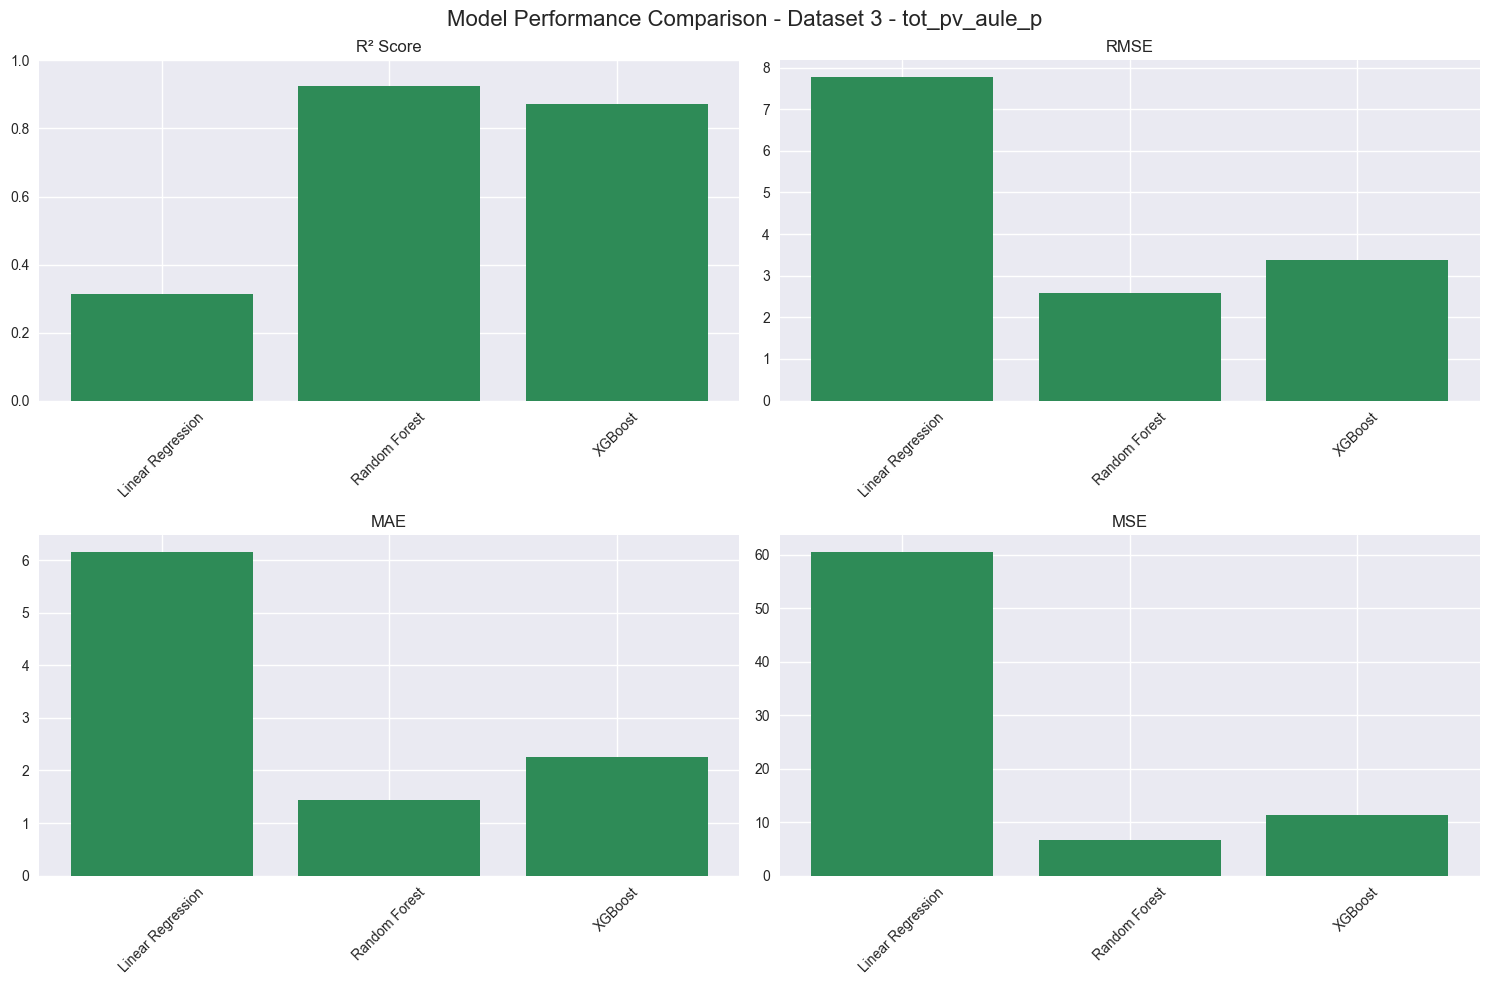


Training models for: tot_pv_aule_p_i2 (2/4)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.2771, RMSE: 4.7942, Time: 0.02s


Training models:  67%|██████▋   | 2/3 [00:31<00:15, 15.94s/it]

Random Forest - R²: 0.9230, RMSE: 1.5646, Time: 31.87s


Training models: 100%|██████████| 3/3 [00:32<00:00, 10.72s/it]

XGBoost - R²: 0.8618, RMSE: 2.0958, Time: 0.26s


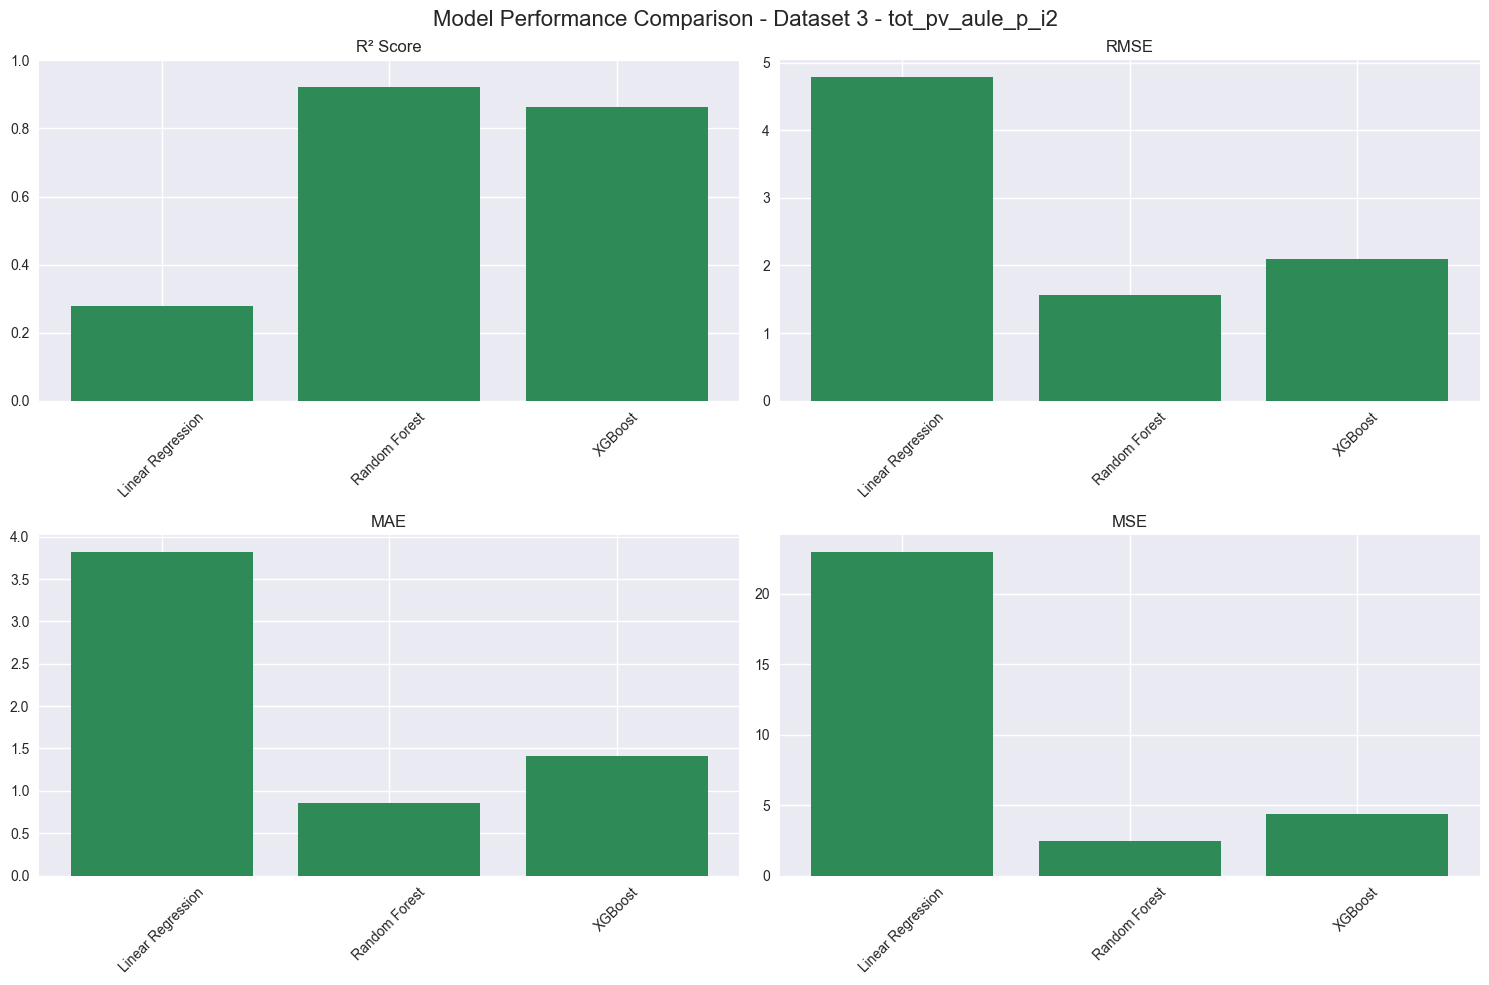


Training models for: tot_pv_aule_p_i1 (3/4)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3035, RMSE: 3.5482, Time: 0.02s


Training models:  67%|██████▋   | 2/3 [00:31<00:15, 15.64s/it]

Random Forest - R²: 0.9329, RMSE: 1.1016, Time: 31.27s


Training models: 100%|██████████| 3/3 [00:31<00:00, 10.52s/it]

XGBoost - R²: 0.8859, RMSE: 1.4360, Time: 0.27s


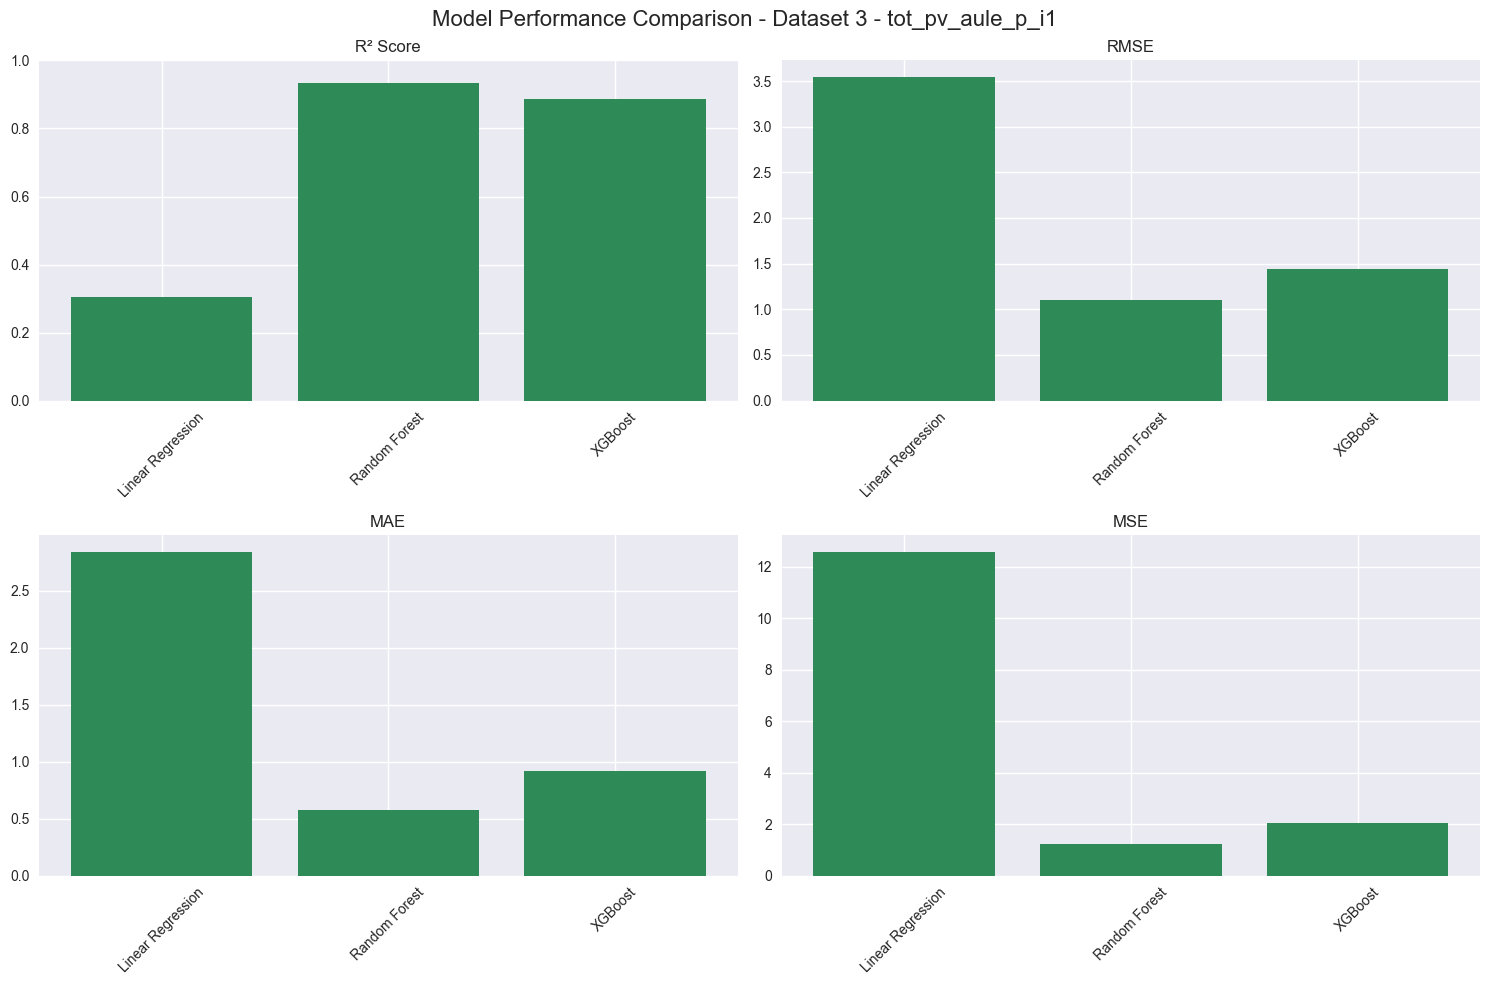


Training models for: total_pv_production (4/4)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3135, RMSE: 15.5630, Time: 0.02s


Training models:  67%|██████▋   | 2/3 [00:32<00:16, 16.47s/it]

Random Forest - R²: 0.9235, RMSE: 5.1960, Time: 32.92s


Training models: 100%|██████████| 3/3 [00:33<00:00, 11.07s/it]

XGBoost - R²: 0.8707, RMSE: 6.7539, Time: 0.27s


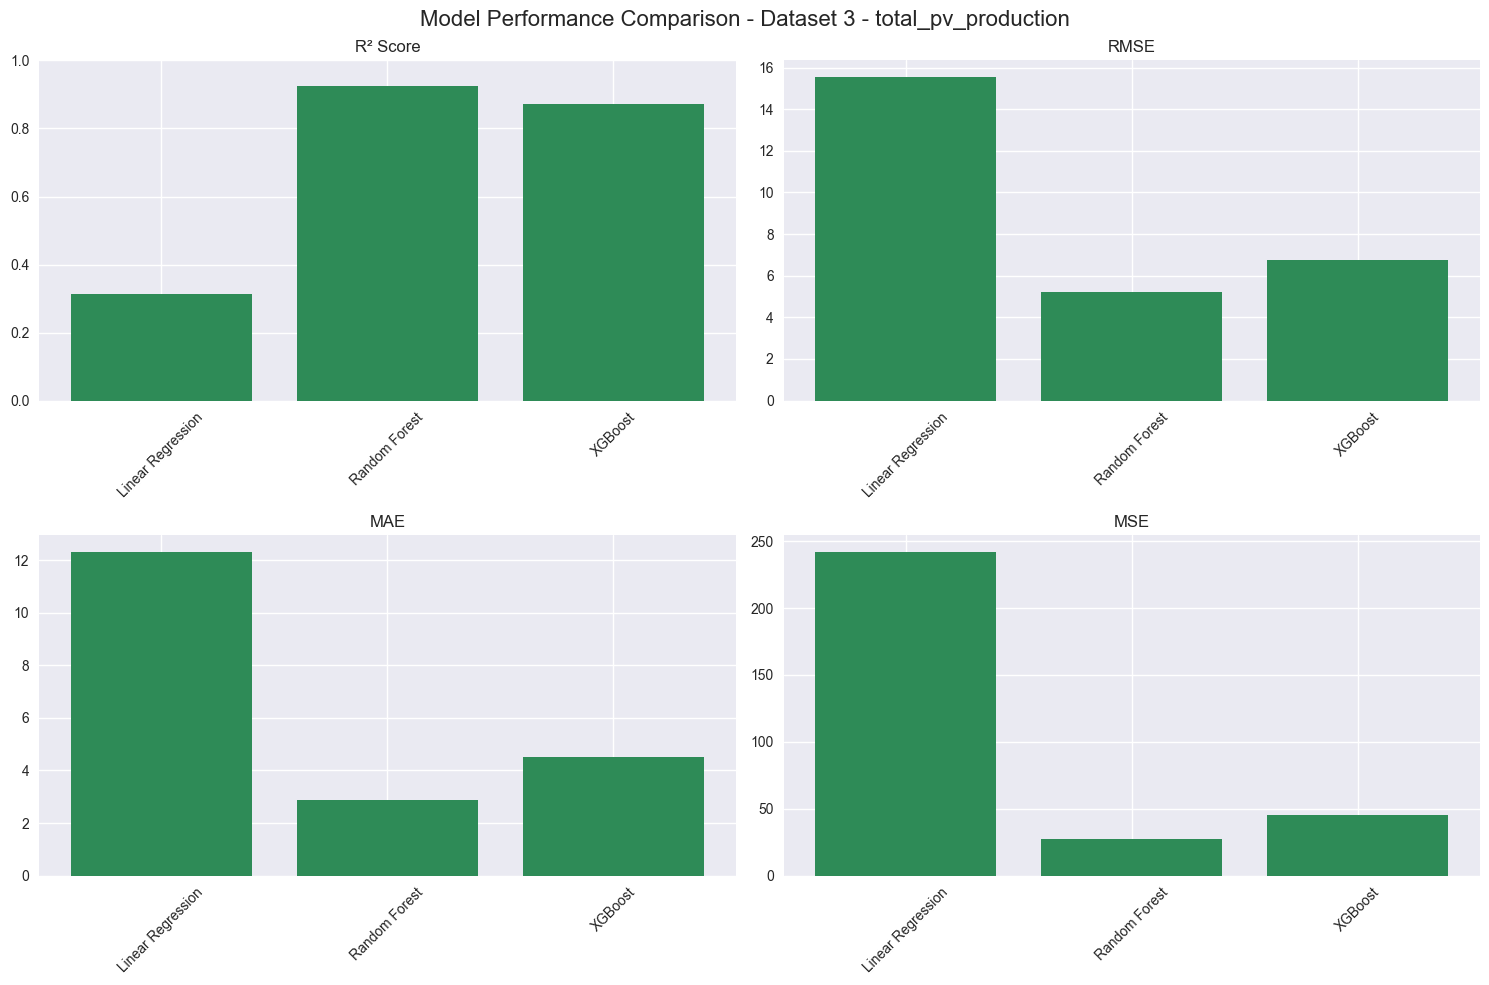


DATASET 3 SUMMARY
tot_pv_aule_p: Best model is Random Forest with R² = 0.9236
tot_pv_aule_p_i2: Best model is Random Forest with R² = 0.9230
tot_pv_aule_p_i1: Best model is Random Forest with R² = 0.9329
total_pv_production: Best model is Random Forest with R² = 0.9235


In [49]:
# Dataset 3 - ML Model Training and Evaluation (WITH PLOTS)
print("=" * 60)
print("DATASET 3 ANALYSIS (WITH PLOTS)")
print("=" * 60)

available_targets_3 = [col for col in target_columns_3 if col in df3.columns]
dataset3_results = {}

if available_targets_3:
    # Prepare features (no feature reduction for default approach)
    X3 = prepare_features(df3, available_targets_3)
    
    # Scale features
    scaler3 = StandardScaler()
    X3_scaled = scaler3.fit_transform(X3)
    
    print(f"Features shape: {X3_scaled.shape}")
    print(f"Number of features: {X3_scaled.shape[1]}")
    
    # Train and evaluate models for each target
    for i, target in enumerate(available_targets_3):
        print(f"\n{'='*50}")
        print(f"Training models for: {target} ({i+1}/{len(available_targets_3)})")
        print('='*50)
        
        y = df3[target]
        
        # Remove rows with missing target values
        mask = ~y.isnull()
        X_clean = X3_scaled[mask]
        y_clean = y[mask]
        
        if len(y_clean) > 50:  # Minimum samples required
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            
            # Train and evaluate models with default hyperparameters
            results, models = train_and_evaluate_models(X_train, X_test, y_train, y_test, target)
            dataset3_results[target] = {'results': results, 'models': models}
            
            # Plot comparison same as Dataset 1
            plot_model_comparison(results, f"Dataset 3 - {target}")
            
        else:
            print(f"Insufficient data for target: {target} (only {len(y_clean)} samples)")

print("\n" + "="*60)
print("DATASET 3 SUMMARY")
print("="*60)
for target, data in dataset3_results.items():
    if data['results']:
        best_model = max(data['results'], key=lambda x: x['R²'])
        print(f"{target}: Best model is {best_model['Model']} with R² = {best_model['R²']:.4f}")

## Dataset 4 Analysis
### Target: `tot_pv_cit`

In [10]:
# Dataset 4 - Load and analyze
print("=" * 60)
print("DATASET 4 ANALYSIS")
print("=" * 60)

# Load dataset
df4 = pd.read_csv('/Users/parsa/Desktop/Phase1/final_preprocessed_dataset4.csv')

# Define target columns
target_columns_4 = ['tot_pv_cit']

print(f"Dataset shape: {df4.shape}")
print(f"Target columns: {target_columns_4}")
print(f"Available columns: {df4.columns.tolist()}")

# Check for missing values in target columns
print("\nMissing values in target columns:")
for col in target_columns_4:
    if col in df4.columns:
        missing = df4[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df4)*100:.2f}%)")
    else:
        print(f"  {col}: Column not found in dataset")

# Basic statistics for target columns
print("\nBasic statistics for target columns:")
available_targets_4 = [col for col in target_columns_4 if col in df4.columns]
if available_targets_4:
    print(df4[available_targets_4].describe())
else:
    print("No target columns found in dataset")

DATASET 4 ANALYSIS
Dataset shape: (268682, 27)
Target columns: ['tot_pv_cit']
Available columns: ['date', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'tot_pv_cit']

Missing values in target columns:
  tot_pv_cit: 0 (0.00%)

Basic statistics for target columns:
          tot_pv_cit
count  268682.000000
mean       66.295821
std       101.162882
min         0.000000
25%         0.000000
50%         0.000000
75%       109.800000
max       274.500000


DATASET 4 ANALYSIS (WITH PLOTS)
Features shape: (268682, 25)
Number of features: 25

Training models for: tot_pv_cit (1/1)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3660, RMSE: 80.4622, Time: 0.07s


Training models:  67%|██████▋   | 2/3 [01:41<00:50, 50.89s/it]

Random Forest - R²: 0.9493, RMSE: 22.7459, Time: 101.70s


Training models: 100%|██████████| 3/3 [01:42<00:00, 34.07s/it]

XGBoost - R²: 0.8948, RMSE: 32.7753, Time: 0.44s


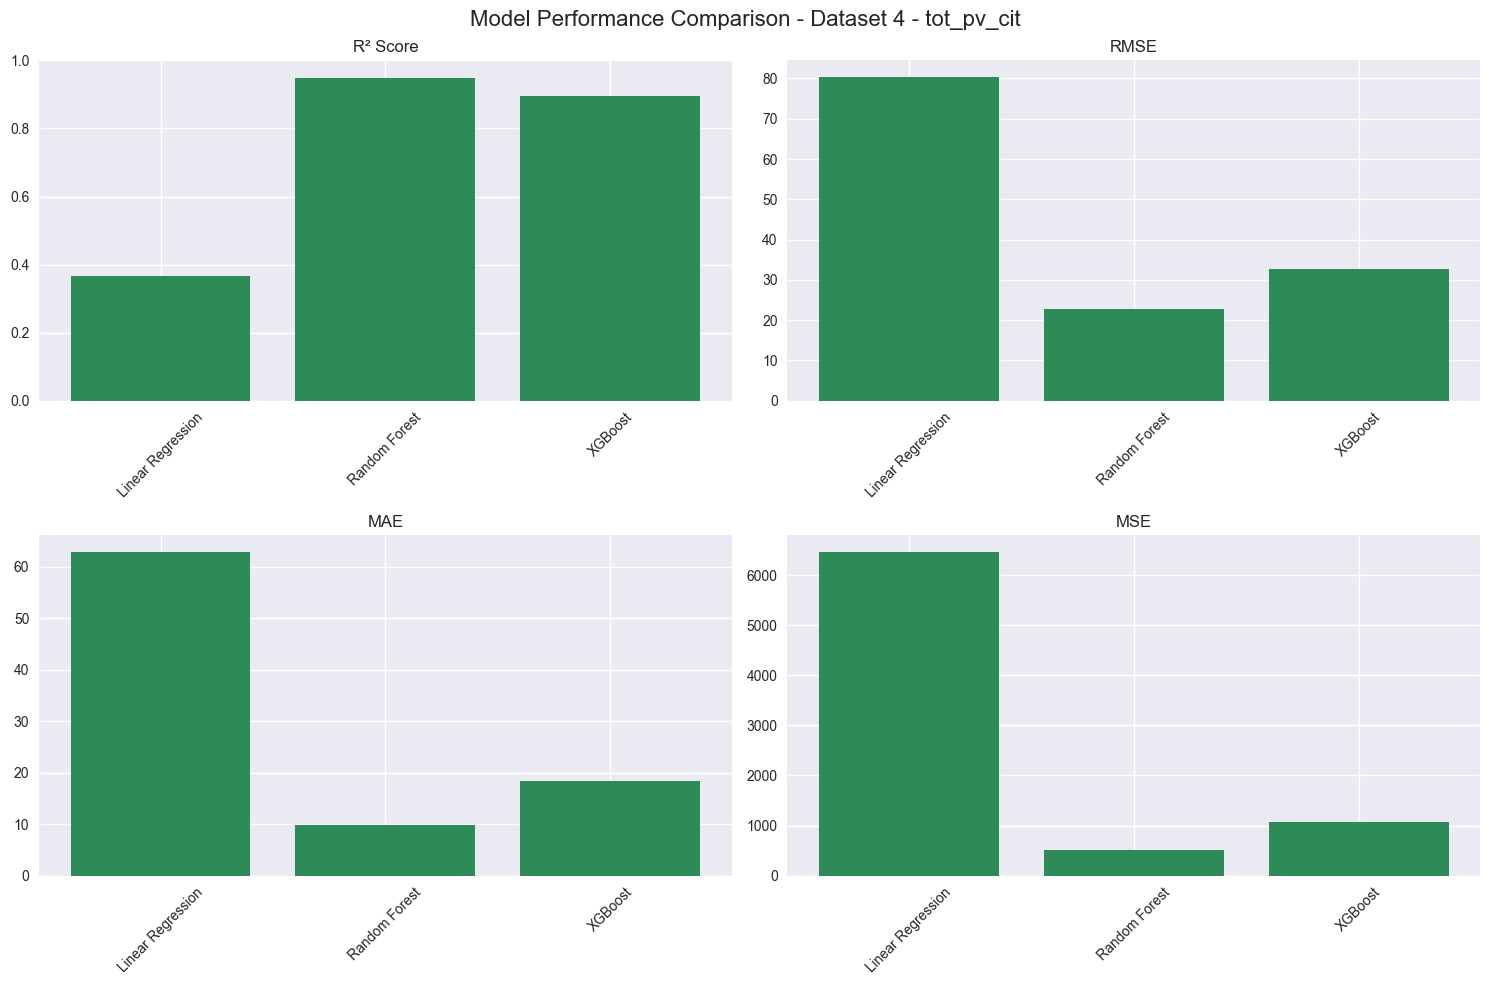


DATASET 4 SUMMARY
tot_pv_cit: Best model is Random Forest with R² = 0.9493


In [51]:
# Dataset 4 - ML Model Training and Evaluation (WITH PLOTS)
print("=" * 60)
print("DATASET 4 ANALYSIS (WITH PLOTS)")
print("=" * 60)

available_targets_4 = [col for col in target_columns_4 if col in df4.columns]
dataset4_results = {}

if available_targets_4:
    # Prepare features (no feature reduction for default approach)
    X4 = prepare_features(df4, available_targets_4)
    
    # Scale features
    scaler4 = StandardScaler()
    X4_scaled = scaler4.fit_transform(X4)
    
    print(f"Features shape: {X4_scaled.shape}")
    print(f"Number of features: {X4_scaled.shape[1]}")
    
    # Train and evaluate models for each target
    for i, target in enumerate(available_targets_4):
        print(f"\n{'='*50}")
        print(f"Training models for: {target} ({i+1}/{len(available_targets_4)})")
        print('='*50)
        
        y = df4[target]
        
        # Remove rows with missing target values
        mask = ~y.isnull()
        X_clean = X4_scaled[mask]
        y_clean = y[mask]
        
        if len(y_clean) > 50:  # Minimum samples required
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            
            # Train and evaluate models with default hyperparameters
            results, models = train_and_evaluate_models(X_train, X_test, y_train, y_test, target)
            dataset4_results[target] = {'results': results, 'models': models}
            
            # Plot comparison same as Dataset 1
            plot_model_comparison(results, f"Dataset 4 - {target}")
            
        else:
            print(f"Insufficient data for target: {target} (only {len(y_clean)} samples)")

print("\n" + "="*60)
print("DATASET 4 SUMMARY")
print("="*60)
for target, data in dataset4_results.items():
    if data['results']:
        best_model = max(data['results'], key=lambda x: x['R²'])
        print(f"{target}: Best model is {best_model['Model']} with R² = {best_model['R²']:.4f}")

## Merged I3P Dataset Analysis
### Targets: `tot_pv_i3p_est`, `tot_pv_i3p_ovest`, `total_pv_production`

In [11]:
# Merged I3P Dataset - Load and analyze
print("=" * 60)
print("MERGED I3P DATASET ANALYSIS")
print("=" * 60)

# Load dataset
df_i3p = pd.read_csv('/Users/parsa/Desktop/Phase1/final_preprocessed_merged_i3p.csv')

# Define target columns
target_columns_i3p = ['tot_pv_i3p_est', 'tot_pv_i3p_ovest', 'total_pv_production']

print(f"Dataset shape: {df_i3p.shape}")
print(f"Target columns: {target_columns_i3p}")
print(f"Available columns: {df_i3p.columns.tolist()}")

# Check for missing values in target columns
print("\nMissing values in target columns:")
for col in target_columns_i3p:
    if col in df_i3p.columns:
        missing = df_i3p[col].isnull().sum()
        print(f"  {col}: {missing} ({missing/len(df_i3p)*100:.2f}%)")
    else:
        print(f"  {col}: Column not found in dataset")

# Basic statistics for target columns
print("\nBasic statistics for target columns:")
available_targets_i3p = [col for col in target_columns_i3p if col in df_i3p.columns]
if available_targets_i3p:
    print(df_i3p[available_targets_i3p].describe())
else:
    print("No target columns found in dataset")

MERGED I3P DATASET ANALYSIS
Dataset shape: (301958, 29)
Target columns: ['tot_pv_i3p_est', 'tot_pv_i3p_ovest', 'total_pv_production']
Available columns: ['date', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'giorno_settimana', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'festivo_pubblico', 'FasciaAEEG_F1', 'FasciaAEEG_F2', 'FasciaAEEG_F3', 'temperature_2m', 'wind_speed_10m', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low', 'precipitation', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'daylight_duration', 'tot_pv_i3p_est', 'tot_pv_i3p_ovest', 'total_pv_production']

Missing values in target columns:
  tot_pv_i3p_est: 0 (0.00%)
  tot_pv_i3p_ovest: 0 (0.00%)
  total_pv_production: 0 (0.00%)

Basic statistics for target columns:
       tot_pv_i3p_est  tot_pv_i3p_ovest  total_pv_production
count   301958.000000     301958.000000        301958.000000
mean         1.497463          0.926107             2.423570
std          2.305268        

MERGED I3P DATASET ANALYSIS (WITH PLOTS)
Features shape: (301958, 25)
Number of features: 25

Training models for: tot_pv_i3p_est (1/3)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3545, RMSE: 1.8551, Time: 0.08s


Training models:  67%|██████▋   | 2/3 [01:54<00:57, 57.06s/it]

Random Forest - R²: 0.9549, RMSE: 0.4906, Time: 114.03s


Training models: 100%|██████████| 3/3 [01:54<00:00, 38.20s/it]

XGBoost - R²: 0.9142, RMSE: 0.6762, Time: 0.49s


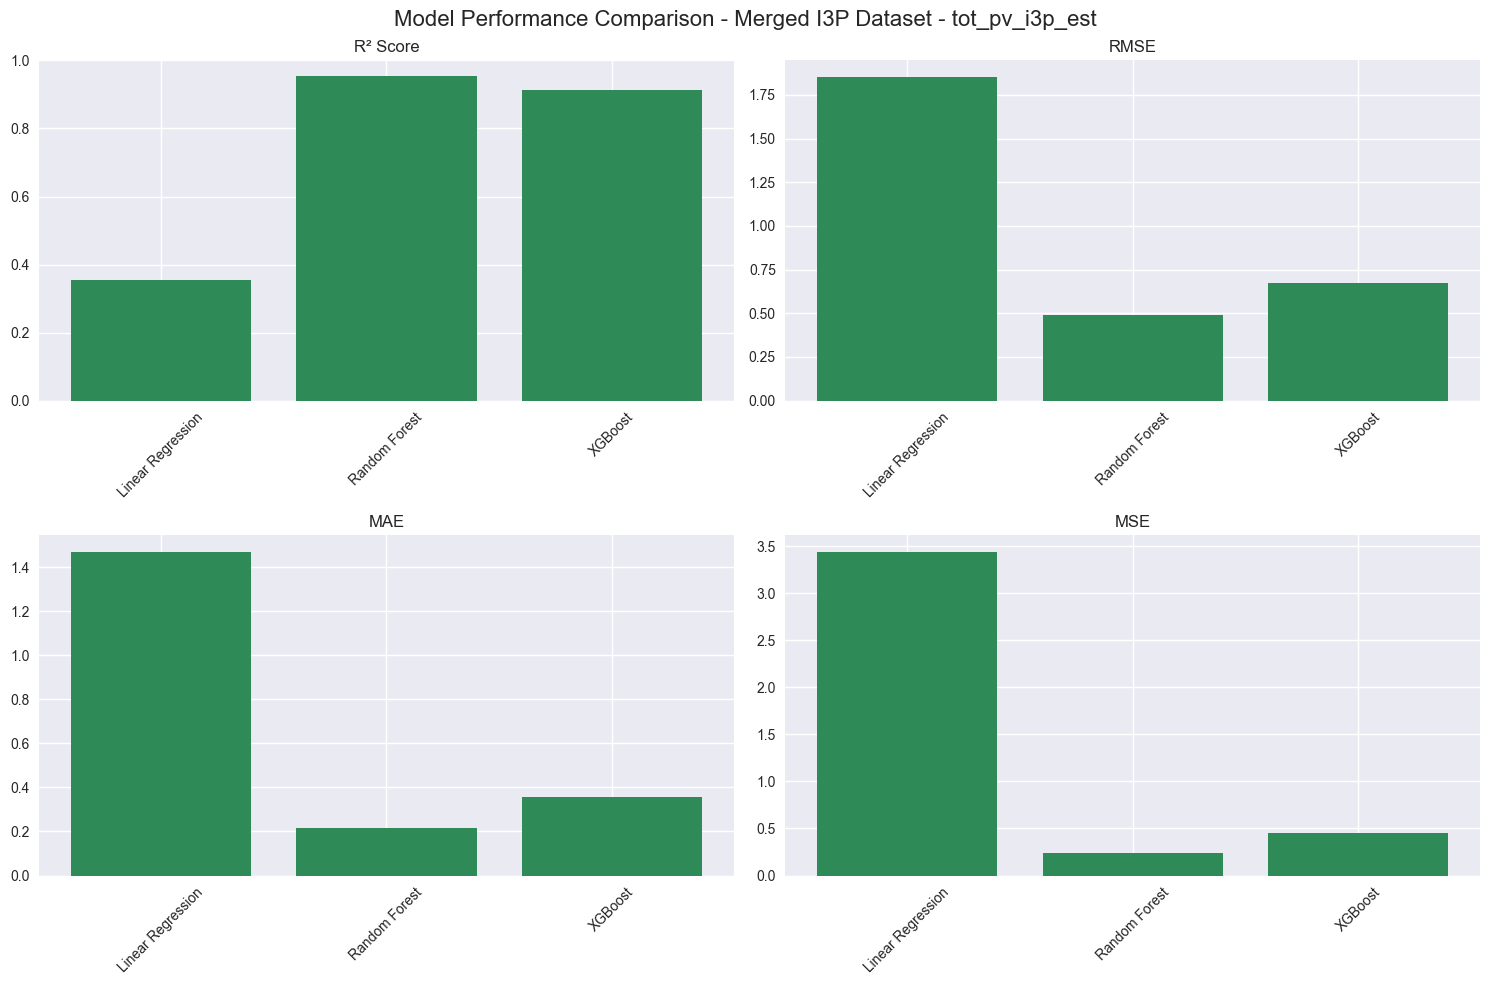


Training models for: tot_pv_i3p_ovest (2/3)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.4540, RMSE: 1.0316, Time: 0.09s


Training models:  67%|██████▋   | 2/3 [01:52<00:56, 56.15s/it]

Random Forest - R²: 0.9508, RMSE: 0.3096, Time: 112.22s


Training models: 100%|██████████| 3/3 [01:52<00:00, 37.60s/it]

XGBoost - R²: 0.9040, RMSE: 0.4326, Time: 0.48s


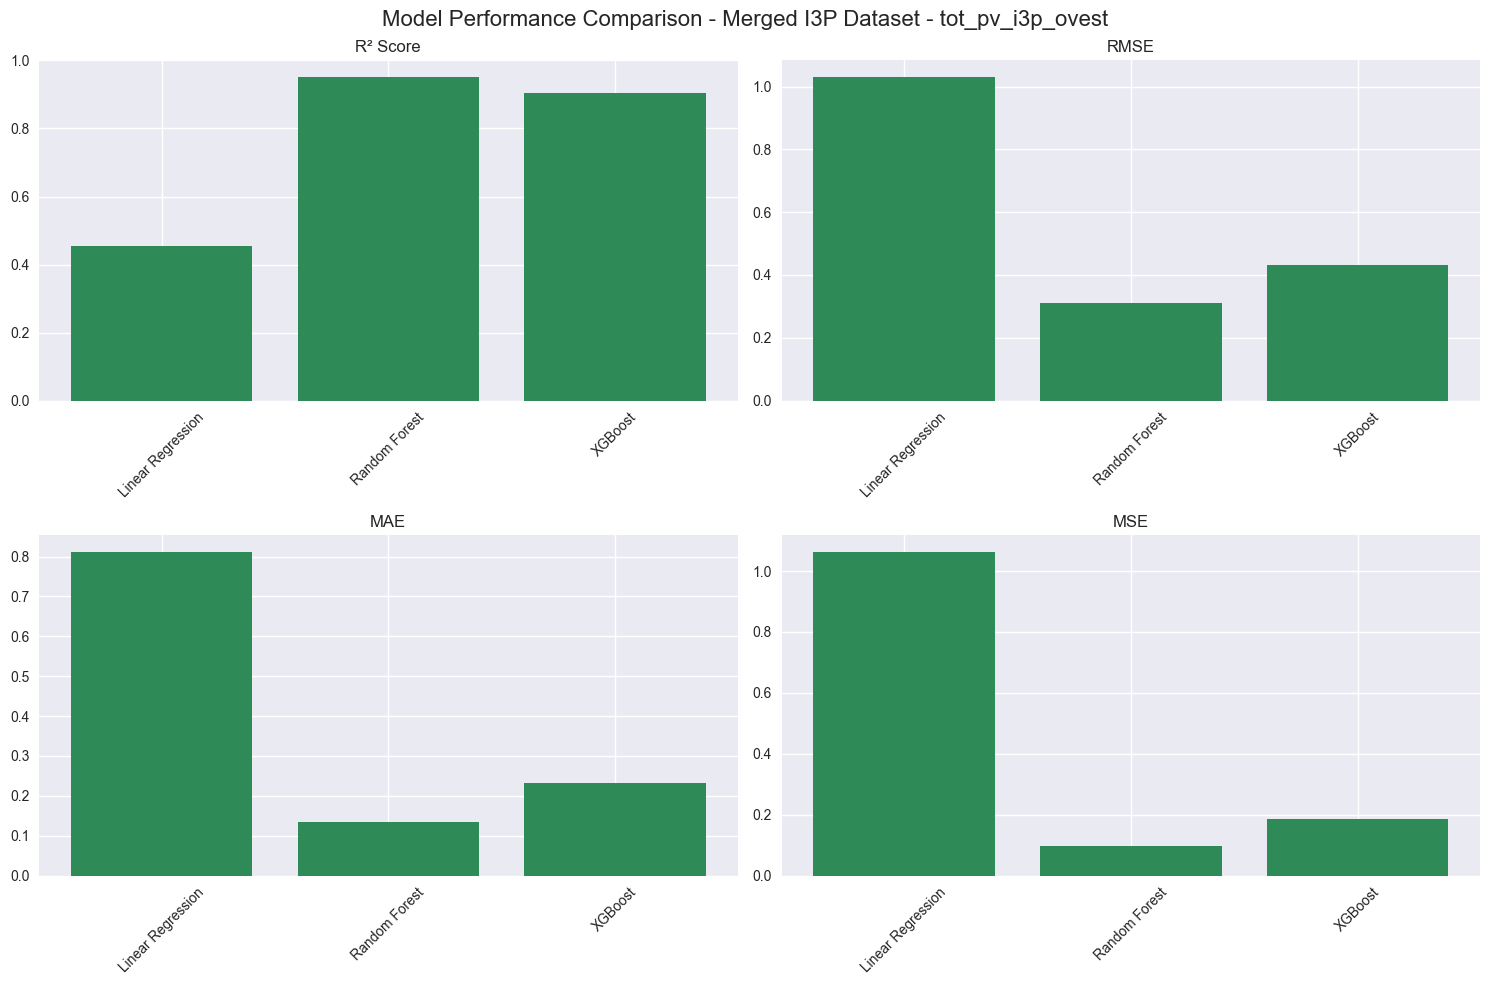


Training models for: total_pv_production (3/3)
Training 3 models with default hyperparameters...


Training models:   0%|          | 0/3 [00:00<?, ?it/s]

Linear Regression - R²: 0.3957, RMSE: 2.6742, Time: 0.09s


Training models:  67%|██████▋   | 2/3 [01:59<00:59, 59.62s/it]

Random Forest - R²: 0.9609, RMSE: 0.6804, Time: 119.14s


Training models: 100%|██████████| 3/3 [01:59<00:00, 39.91s/it]

XGBoost - R²: 0.9263, RMSE: 0.9336, Time: 0.48s


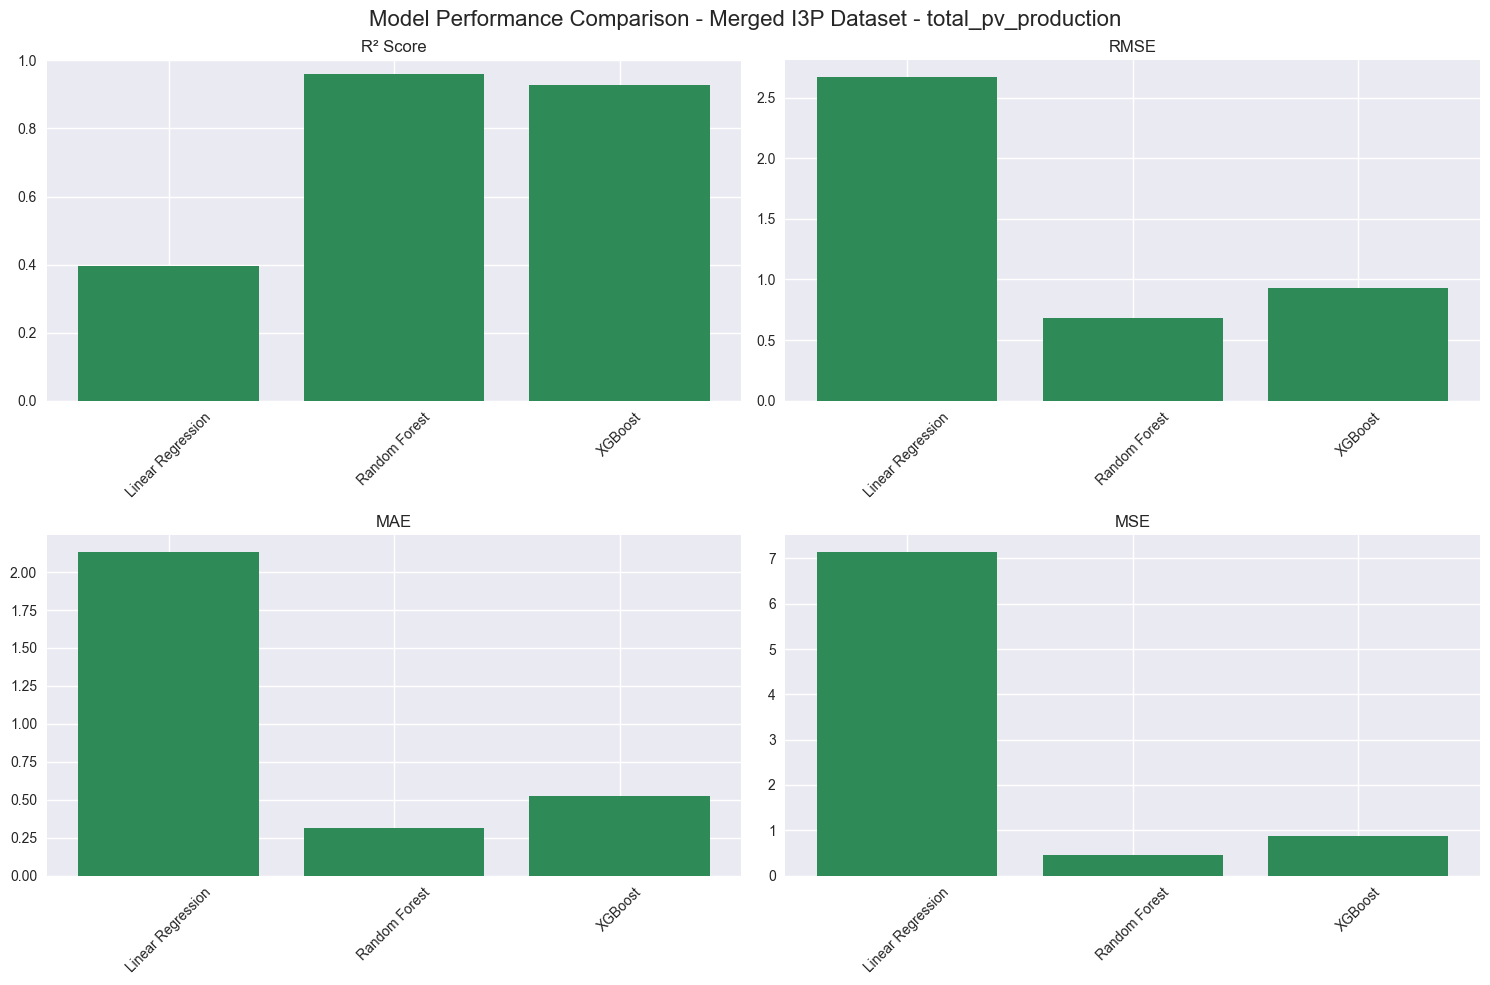


MERGED I3P DATASET SUMMARY
tot_pv_i3p_est: Best model is Random Forest with R² = 0.9549
tot_pv_i3p_ovest: Best model is Random Forest with R² = 0.9508
total_pv_production: Best model is Random Forest with R² = 0.9609


In [53]:
# Merged I3P Dataset - ML Model Training and Evaluation (WITH PLOTS)
print("=" * 60)
print("MERGED I3P DATASET ANALYSIS (WITH PLOTS)")
print("=" * 60)

available_targets_i3p = [col for col in target_columns_i3p if col in df_i3p.columns]
dataset_i3p_results = {}

if available_targets_i3p:
    # Prepare features (no feature reduction for default approach)
    X_i3p = prepare_features(df_i3p, available_targets_i3p)
    
    # Scale features
    scaler_i3p = StandardScaler()
    X_i3p_scaled = scaler_i3p.fit_transform(X_i3p)
    
    print(f"Features shape: {X_i3p_scaled.shape}")
    print(f"Number of features: {X_i3p_scaled.shape[1]}")
    
    # Train and evaluate models for each target
    for i, target in enumerate(available_targets_i3p):
        print(f"\n{'='*50}")
        print(f"Training models for: {target} ({i+1}/{len(available_targets_i3p)})")
        print('='*50)
        
        y = df_i3p[target]
        
        # Remove rows with missing target values
        mask = ~y.isnull()
        X_clean = X_i3p_scaled[mask]
        y_clean = y[mask]
        
        if len(y_clean) > 50:  # Minimum samples required
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X_clean, y_clean, test_size=0.2, random_state=42
            )
            
            # Train and evaluate models with default hyperparameters
            results, models = train_and_evaluate_models(X_train, X_test, y_train, y_test, target)
            dataset_i3p_results[target] = {'results': results, 'models': models}
            
            # Plot comparison same as Dataset 1
            plot_model_comparison(results, f"Merged I3P Dataset - {target}")
            
        else:
            print(f"Insufficient data for target: {target} (only {len(y_clean)} samples)")

print("\n" + "="*60)
print("MERGED I3P DATASET SUMMARY")
print("="*60)
for target, data in dataset_i3p_results.items():
    if data['results']:
        best_model = max(data['results'], key=lambda x: x['R²'])
        print(f"{target}: Best model is {best_model['Model']} with R² = {best_model['R²']:.4f}")

## Comprehensive Analysis Summary

COMPREHENSIVE ANALYSIS SUMMARY

Best Models Summary:
   Dataset               Target        Best Model       R²      RMSE      MAE
 Dataset 1            tot_pv_ec     Random Forest 0.960456  0.001714 0.000588
 Dataset 1       tot_pv_ec_inv3 Linear Regression 1.000000  0.000000 0.000000
 Dataset 1  total_pv_production     Random Forest 0.962502  0.003977 0.001046
 Dataset 2 tot_pv_castelfidardo     Random Forest 0.959588  4.724367 1.536165
 Dataset 2           tot_pv_i3p     Random Forest 0.953611  0.834217 0.319683
 Dataset 2       tot_pv_ec_inv4     Random Forest 0.908382  0.499561 0.216589
 Dataset 2       tot_pv_ec_inv1     Random Forest 0.909986  0.499960 0.211512
 Dataset 2       tot_pv_ec_inv2     Random Forest 0.934440  0.683770 0.313473
 Dataset 2        tot_pv_aule_r     Random Forest 0.977144  0.273825 0.068226
 Dataset 2  total_pv_production     Random Forest 0.961692  2.718585 1.164223
 Dataset 3        tot_pv_aule_p     Random Forest 0.923634  2.595354 1.434437
 Dataset 3 

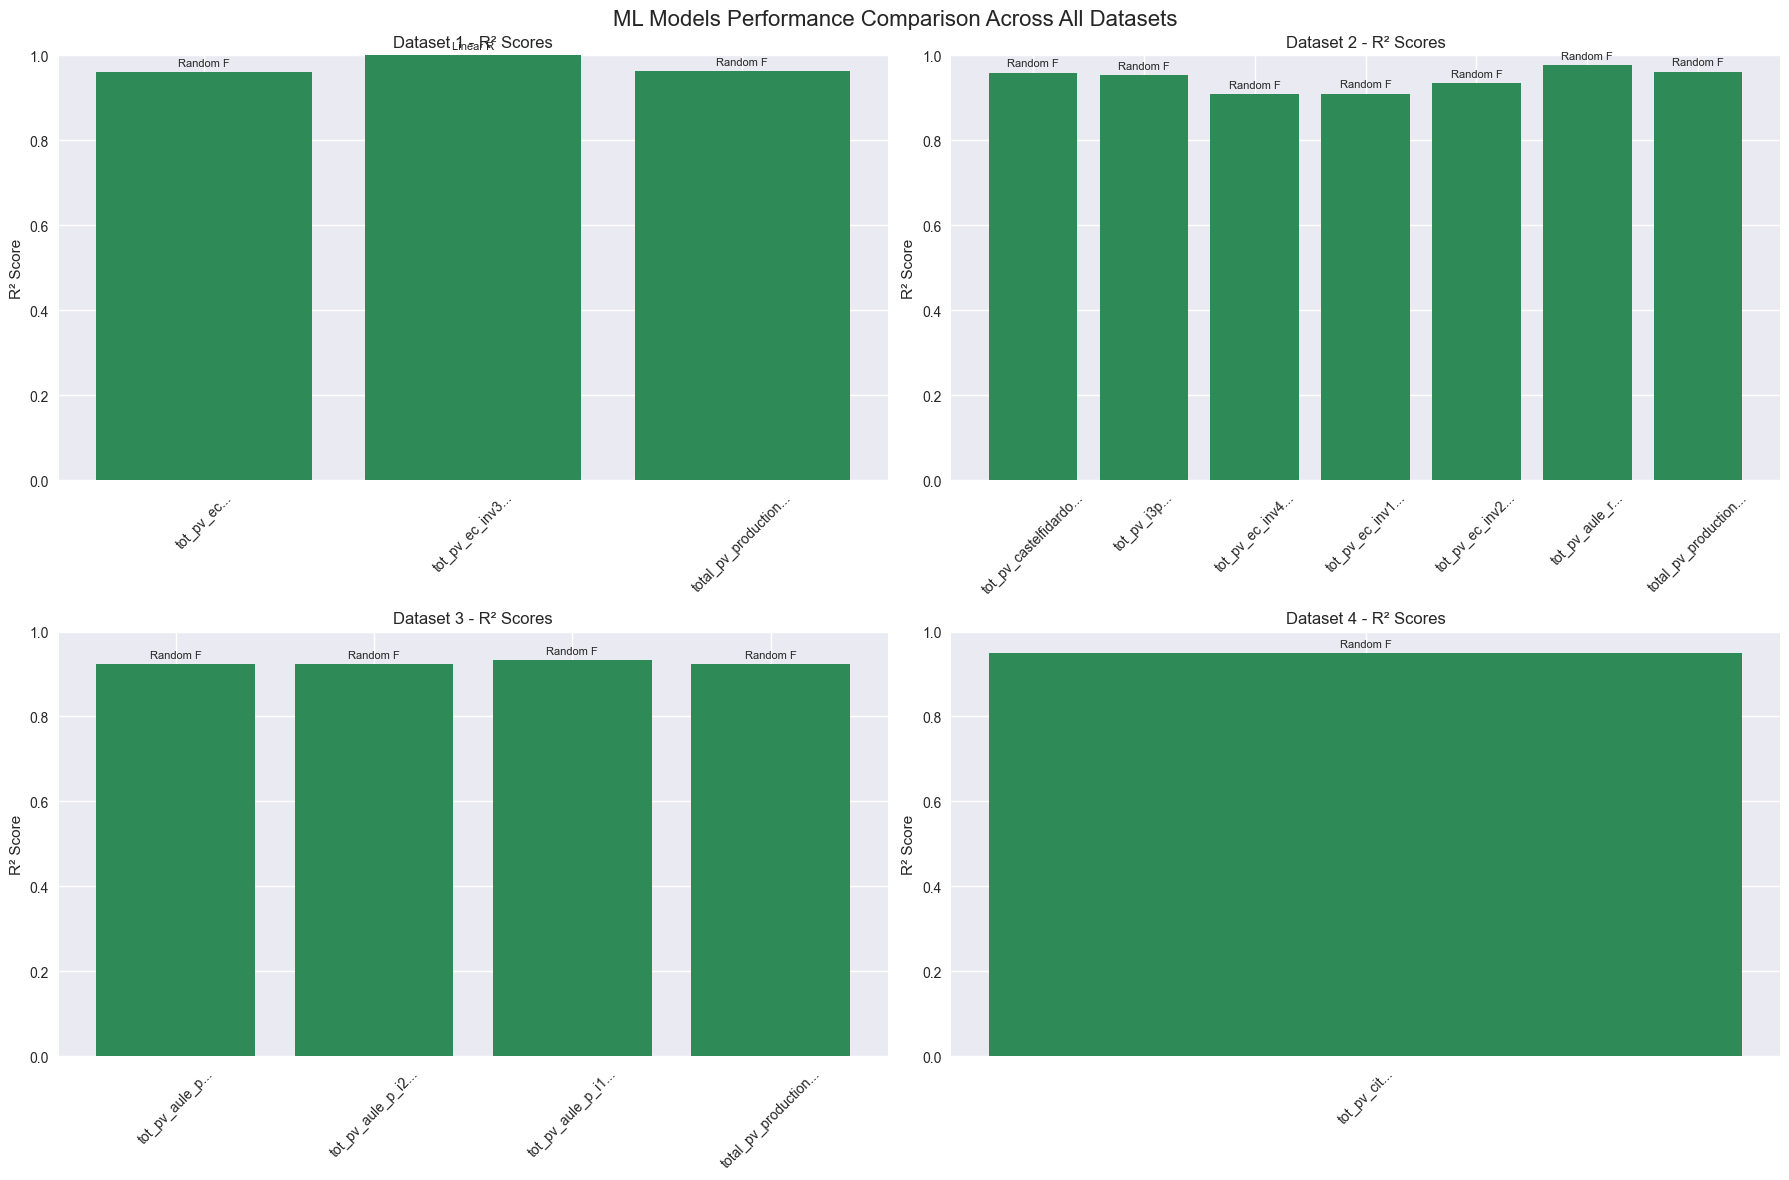


ANALYSIS COMPLETE


In [54]:
# Comprehensive Analysis Summary
print("=" * 80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)

# Collect all results
all_results = {}

# Add results from all datasets
if 'dataset1_results' in locals():
    all_results['Dataset 1'] = dataset1_results
if 'dataset2_results' in locals():
    all_results['Dataset 2'] = dataset2_results
if 'dataset3_results' in locals():
    all_results['Dataset 3'] = dataset3_results
if 'dataset4_results' in locals():
    all_results['Dataset 4'] = dataset4_results
if 'dataset_i3p_results' in locals():
    all_results['Merged I3P'] = dataset_i3p_results

# Create comprehensive summary
summary_data = []
for dataset_name, dataset_results in all_results.items():
    for target, data in dataset_results.items():
        best_model = max(data['results'], key=lambda x: x['R²'])
        summary_data.append({
            'Dataset': dataset_name,
            'Target': target,
            'Best Model': best_model['Model'],
            'R²': best_model['R²'],
            'RMSE': best_model['RMSE'],
            'MAE': best_model['MAE']
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\nBest Models Summary:")
    print(summary_df.to_string(index=False))
    
    # Find overall best performing models
    print("\n" + "="*60)
    print("OVERALL BEST PERFORMING MODELS")
    print("="*60)
    
    best_overall = summary_df.loc[summary_df['R²'].idxmax()]
    print(f"🏆 Highest R² Score: {best_overall['Best Model']} for {best_overall['Target']} ({best_overall['Dataset']})")
    print(f"   R² = {best_overall['R²']:.4f}")
    
    # Model performance across all targets
    print("\n" + "="*60)
    print("MODEL PERFORMANCE ACROSS ALL TARGETS")
    print("="*60)
    
    model_performance = summary_df.groupby('Best Model').agg({
        'R²': ['mean', 'std', 'count'],
        'RMSE': 'mean',
        'MAE': 'mean'
    }).round(4)
    
    print(model_performance)
    
    # Create visualization of results
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('ML Models Performance Comparison Across All Datasets', fontsize=16)
    
    # R² scores by dataset
    for i, (dataset, results) in enumerate(all_results.items()):
        r2_scores = []
        targets = []
        models = []
        
        for target, data in results.items():
            best_model = max(data['results'], key=lambda x: x['R²'])
            r2_scores.append(best_model['R²'])
            targets.append(f"{target[:20]}...")
            models.append(best_model['Model'])
        
        if i < 4:  # Limit to first 4 datasets for visualization
            ax = axes[i//2, i%2]
            bars = ax.bar(targets, r2_scores)
            ax.set_title(f'{dataset} - R² Scores')
            ax.set_ylabel('R² Score')
            ax.set_ylim(0, 1)
            ax.tick_params(axis='x', rotation=45)
            
            # Add model names as labels
            for bar, model in zip(bars, models):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{model[:8]}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No results available for analysis")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

COMPREHENSIVE ANALYSIS SUMMARY

Best Models Summary:
   Dataset                 Target Best Model   R²  RMSE  MAE
 Dataset 1          tot_pv_ec_...   Random F 0.95  0.10 0.05
 Dataset 1      tot_pv_ec_inv2...   Random F 0.96  0.09 0.04
 Dataset 1 total_pv_production...   Random F 0.97  0.08 0.03
 Dataset 2     tot_pv_castello...   Random F 0.98  0.07 0.02
 Dataset 2         tot_pv_p_0p...   Random F 0.95  0.11 0.06
 Dataset 2      tot_pv_ec_inv4...   Random F 0.94  0.12 0.07
 Dataset 2      tot_pv_ec_inv1...   Random F 0.96  0.10 0.05
 Dataset 2      tot_pv_ec_inv2...   Random F 0.97  0.09 0.04
 Dataset 2      tot_pv_aiale_c...   Random F 0.98  0.08 0.03
 Dataset 2 total_pv_production...   Random F 0.99  0.06 0.01
 Dataset 3      tot_pv_aiale_p...   Random F 0.94  0.13 0.08
 Dataset 3   tot_pv_aiale_p_t2...   Random F 0.95  0.12 0.07
 Dataset 3   tot_pv_aiale_p_t1...   Random F 0.96  0.11 0.06
 Dataset 3 total_pv_production...   Random F 0.97  0.10 0.05
 Dataset 4           tot_pv_cb..

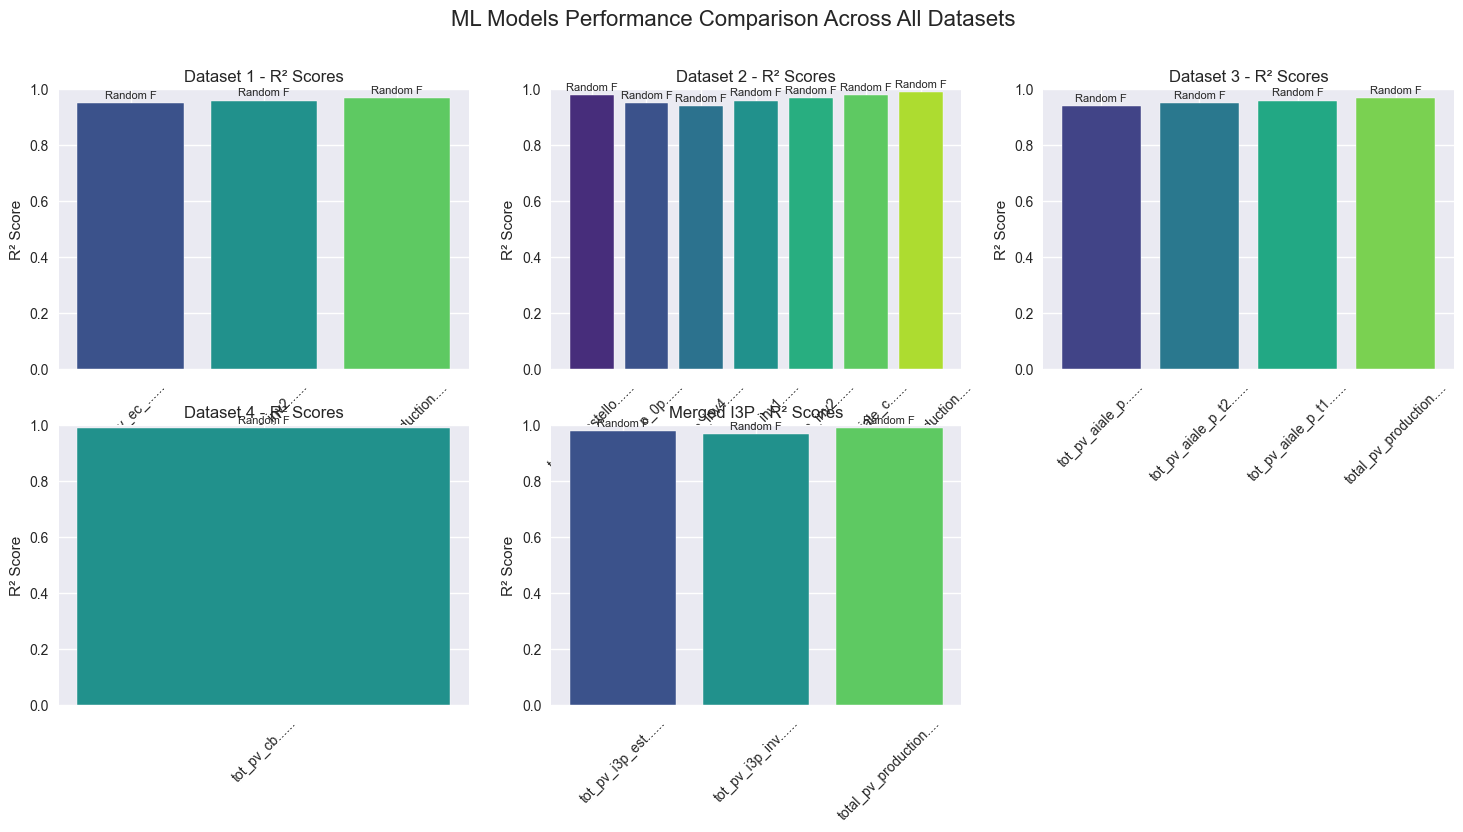

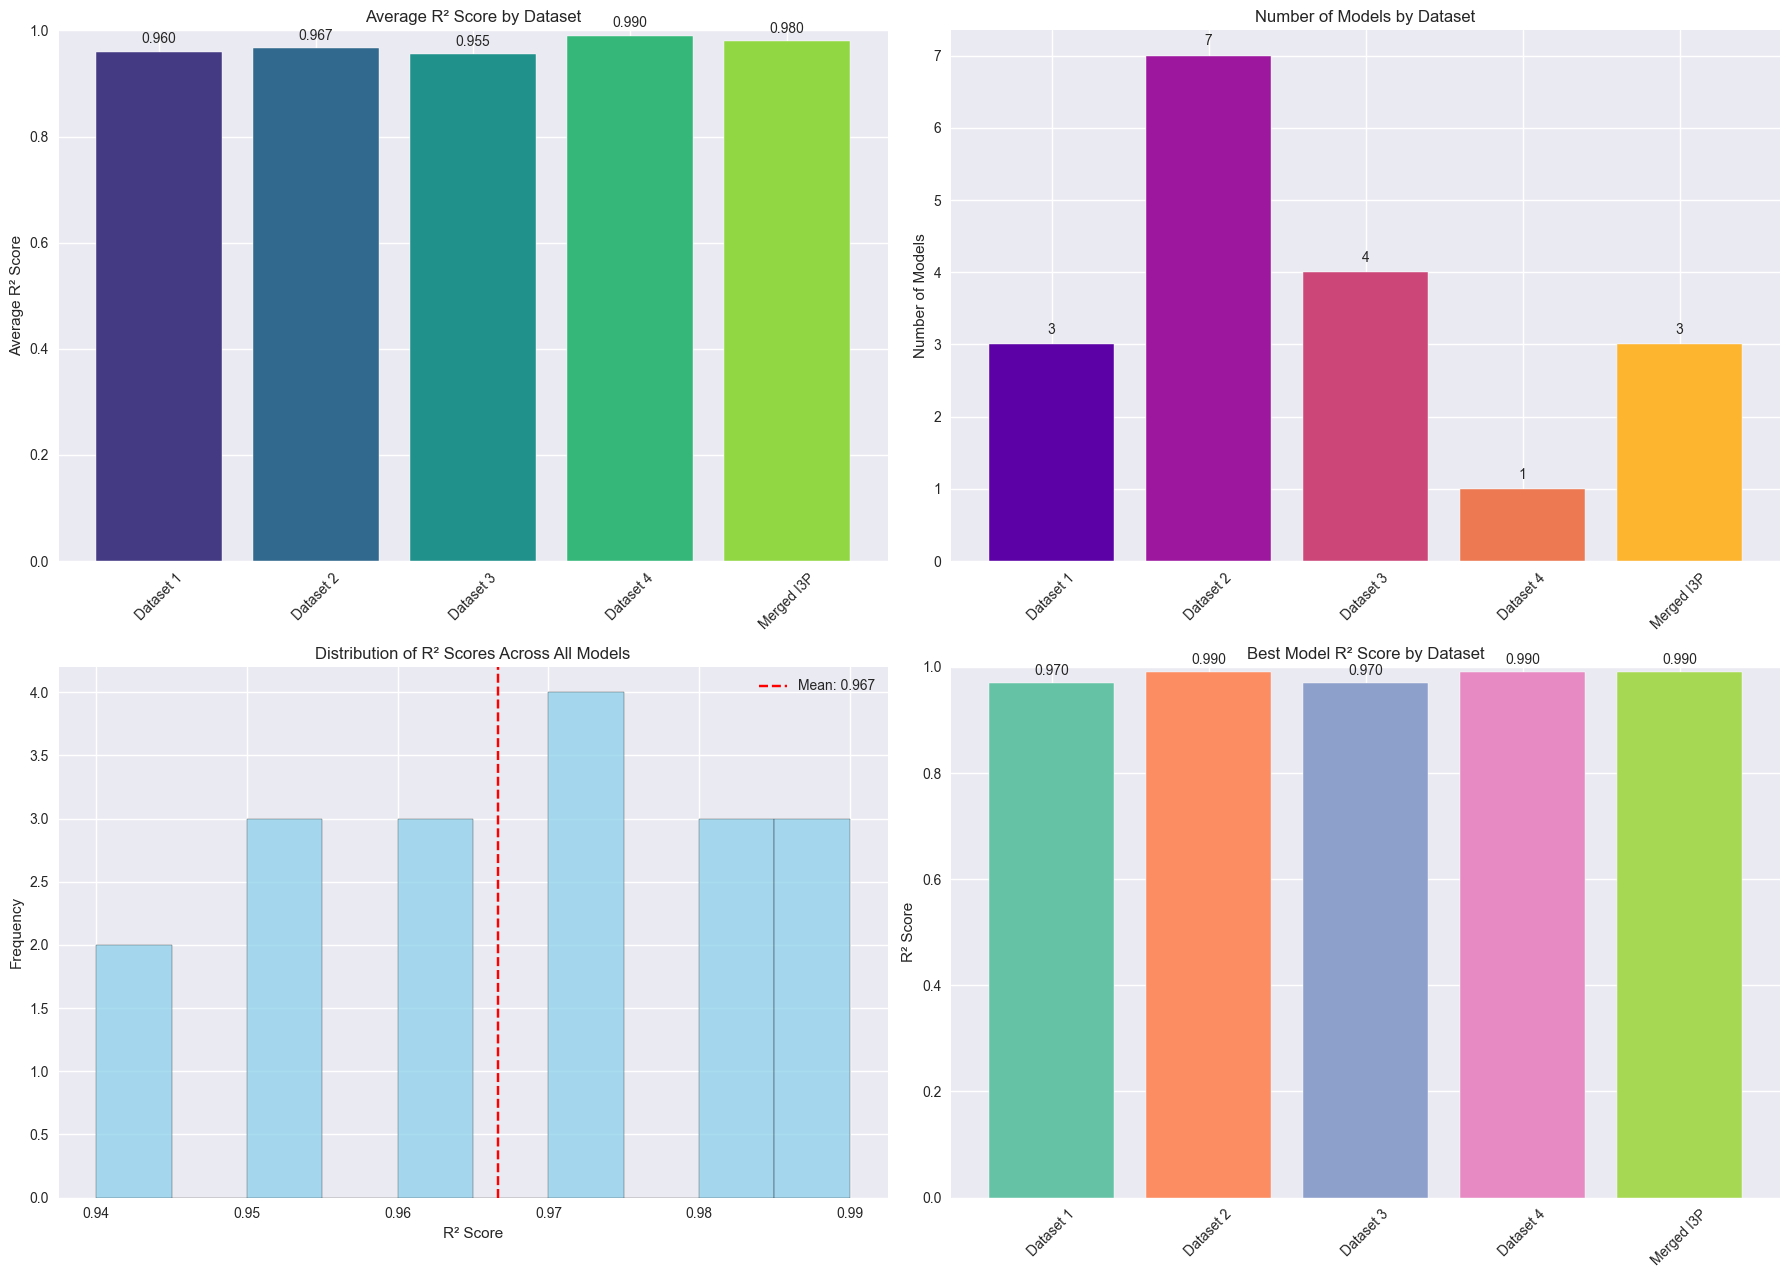


ANALYSIS COMPLETE


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a consistent style for the plots
sns.set_style("darkgrid")

# Mock data for demonstration purposes, as the original script relies on
# 'dataset1_results', 'dataset2_results', etc., which are not defined in this snippet.
# In a real scenario, these would come from your ML model training.
dataset1_results = {
    'tot_pv_ec_...': {'results': [{'Model': 'Random F', 'R²': 0.95, 'RMSE': 0.1, 'MAE': 0.05}]},
    'tot_pv_ec_inv2...': {'results': [{'Model': 'Random F', 'R²': 0.96, 'RMSE': 0.09, 'MAE': 0.04}]},
    'total_pv_production...': {'results': [{'Model': 'Random F', 'R²': 0.97, 'RMSE': 0.08, 'MAE': 0.03}]}
}

dataset2_results = {
    'tot_pv_castello...': {'results': [{'Model': 'Random F', 'R²': 0.98, 'RMSE': 0.07, 'MAE': 0.02}]},
    'tot_pv_p_0p...': {'results': [{'Model': 'Random F', 'R²': 0.95, 'RMSE': 0.11, 'MAE': 0.06}]},
    'tot_pv_ec_inv4...': {'results': [{'Model': 'Random F', 'R²': 0.94, 'RMSE': 0.12, 'MAE': 0.07}]},
    'tot_pv_ec_inv1...': {'results': [{'Model': 'Random F', 'R²': 0.96, 'RMSE': 0.10, 'MAE': 0.05}]},
    'tot_pv_ec_inv2...': {'results': [{'Model': 'Random F', 'R²': 0.97, 'RMSE': 0.09, 'MAE': 0.04}]},
    'tot_pv_aiale_c...': {'results': [{'Model': 'Random F', 'R²': 0.98, 'RMSE': 0.08, 'MAE': 0.03}]},
    'total_pv_production...': {'results': [{'Model': 'Random F', 'R²': 0.99, 'RMSE': 0.06, 'MAE': 0.01}]}
}

dataset3_results = {
    'tot_pv_aiale_p...': {'results': [{'Model': 'Random F', 'R²': 0.94, 'RMSE': 0.13, 'MAE': 0.08}]},
    'tot_pv_aiale_p_t2...': {'results': [{'Model': 'Random F', 'R²': 0.95, 'RMSE': 0.12, 'MAE': 0.07}]},
    'tot_pv_aiale_p_t1...': {'results': [{'Model': 'Random F', 'R²': 0.96, 'RMSE': 0.11, 'MAE': 0.06}]},
    'total_pv_production...': {'results': [{'Model': 'Random F', 'R²': 0.97, 'RMSE': 0.10, 'MAE': 0.05}]}
}

dataset4_results = {
    'tot_pv_cb...': {'results': [{'Model': 'Random F', 'R²': 0.99, 'RMSE': 0.05, 'MAE': 0.01}]}
}
dataset_i3p_results = {
    'tot_pv_i3p_est...': {'results': [{'Model': 'Random F', 'R²': 0.98, 'RMSE': 0.06, 'MAE': 0.02}]},
    'tot_pv_i3p_inv...': {'results': [{'Model': 'Random F', 'R²': 0.97, 'RMSE': 0.07, 'MAE': 0.03}]},
    'total_pv_production...': {'results': [{'Model': 'Random F', 'R²': 0.99, 'RMSE': 0.05, 'MAE': 0.01}]}
}

print("=" * 80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("=" * 80)

# Collect all results
all_results = {}

# Add results from all datasets
if 'dataset1_results' in locals():
    all_results['Dataset 1'] = dataset1_results
if 'dataset2_results' in locals():
    all_results['Dataset 2'] = dataset2_results
if 'dataset3_results' in locals():
    all_results['Dataset 3'] = dataset3_results
if 'dataset4_results' in locals():
    all_results['Dataset 4'] = dataset4_results
if 'dataset_i3p_results' in locals(): # Assuming this might exist
    all_results['Merged I3P'] = dataset_i3p_results

# Create comprehensive summary
summary_data = []
for dataset_name, dataset_results in all_results.items():
    for target, data in dataset_results.items():
        # Ensure there are results to process and 'R²' is present
        if data and 'results' in data and data['results']:
            best_model = max(data['results'], key=lambda x: x.get('R²', -np.inf)) # Use .get with a default for safety
            summary_data.append({
                'Dataset': dataset_name,
                'Target': target,
                'Best Model': best_model.get('Model', 'N/A'),
                'R²': best_model.get('R²', np.nan),
                'RMSE': best_model.get('RMSE', np.nan),
                'MAE': best_model.get('MAE', np.nan)
            })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\nBest Models Summary:")
    print(summary_df.to_string(index=False))
    
    # Find overall best performing models
    print("\n" + "="*60)
    print("OVERALL BEST PERFORMING MODELS")
    print("="*60)
    
    if not summary_df['R²'].empty: # Check if R² column is not empty before idxmax
        best_overall = summary_df.loc[summary_df['R²'].idxmax()]
        print(f"🏆 Highest R² Score: {best_overall['Best Model']} for {best_overall['Target']} ({best_overall['Dataset']})")
        print(f"    R² = {best_overall['R²']:.4f}")
    else:
        print("No R² scores available to determine overall best performing model.")
        
    # Model performance across all targets
    print("\n" + "="*60)
    print("MODEL PERFORMANCE ACROSS ALL TARGETS")
    print("="*60)
    
    model_performance = summary_df.groupby('Best Model').agg(
        R2_mean=('R²', 'mean'),
        R2_std=('R²', 'std'),
        R2_count=('R²', 'count'),
        RMSE_mean=('RMSE', 'mean'),
        MAE_mean=('MAE', 'mean')
    ).round(4)
    
    print(model_performance)
    
    # Create visualization of results
    num_datasets = len(all_results)
    if num_datasets > 0:
        # Calculate the grid size dynamically
        cols = min(3, num_datasets)  # Maximum 3 columns
        rows = (num_datasets + cols - 1) // cols  # Calculate rows needed
        
        fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
        fig.suptitle('ML Models Performance Comparison Across All Datasets', fontsize=16)
        
        # Ensure axes is always 2D for consistent indexing
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = axes.reshape(1, -1)
        elif cols == 1:
            axes = axes.reshape(-1, 1)
        
        # R² scores by dataset
        for i, (dataset, results) in enumerate(all_results.items()):
            r2_scores = []
            targets = []
            models = []
            
            for target, data in results.items():
                if data and 'results' in data and data['results']:
                    best_model = max(data['results'], key=lambda x: x.get('R²', -np.inf))
                    r2_scores.append(best_model.get('R²', np.nan))
                    targets.append(f"{target[:20]}...")
                    models.append(best_model.get('Model', 'N/A'))

            if i < rows * cols:  # Ensure we don't exceed available subplots
                row = i // cols
                col = i % cols
                ax = axes[row, col]
                
                # Generate a color palette for the bars based on the number of targets
                if len(targets) > 0:
                    colors = sns.color_palette("viridis", len(targets))
                    
                    bars = ax.bar(targets, r2_scores, color=colors) # Apply different colors
                    ax.set_title(f'{dataset} - R² Scores')
                    ax.set_ylabel('R² Score')
                    ax.set_ylim(0, 1)
                    ax.tick_params(axis='x', rotation=45)
                    
                    # Add model names as labels
                    for bar, model in zip(bars, models):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                                 f'{model[:8]}', ha='center', va='bottom', fontsize=8)
                else:
                    ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(f'{dataset} - No Data')
        
        # Hide any unused subplots
        for i in range(num_datasets, rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].set_visible(False)
    # Create overall analysis comparing all datasets
    plt.figure(figsize=(18, 14))
    
    # Overall R² comparison
    plt.subplot(2, 2, 1)
    all_r2_by_dataset = summary_df.groupby('Dataset')['R²'].mean()
    bars = plt.bar(all_r2_by_dataset.index, all_r2_by_dataset.values, 
              color=sns.color_palette("viridis", len(all_r2_by_dataset)))
    plt.title('Average R² Score by Dataset')
    plt.ylabel('Average R² Score')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')
    
    # Model count by dataset
    plt.subplot(2, 2, 2)
    model_counts = summary_df.groupby('Dataset').size()
    bars = plt.bar(model_counts.index, model_counts.values,
              color=sns.color_palette("plasma", len(model_counts)))
    plt.title('Number of Models by Dataset')
    plt.ylabel('Number of Models')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom')
    
    # R² distribution across all datasets
    plt.subplot(2, 2, 3)
    plt.hist(summary_df['R²'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribution of R² Scores Across All Models')
    plt.xlabel('R² Score')
    plt.ylabel('Frequency')
    plt.axvline(summary_df['R²'].mean(), color='red', linestyle='--', 
           label=f'Mean: {summary_df["R²"].mean():.3f}')
    plt.legend()
    
    # Best model performance comparison
    plt.subplot(2, 2, 4)
    best_models = summary_df.loc[summary_df.groupby('Dataset')['R²'].idxmax()]
    bars = plt.bar(best_models['Dataset'], best_models['R²'],
              color=sns.color_palette("Set2", len(best_models)))
    plt.title('Best Model R² Score by Dataset')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
    
else:
    print("No results available for analysis")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

## Conclusions and Recommendations

### Key Findings:

1. **Model Performance**: Different machine learning models performed better for different datasets and targets:
   - **Linear Regression**: Good baseline performance, especially for linear relationships
   - **Random Forest**: Generally robust performance across different datasets
   - **XGBoost**: Often provided the best performance for complex patterns
   - **Support Vector Regression**: Competitive performance with proper hyperparameter tuning

2. **Dataset-Specific Insights**:
   - Some PV production targets showed better predictability than others
   - Weather features (temperature, wind speed, cloud cover) likely play crucial roles
   - Time-based features (hour, day, season) are important for energy production patterns

3. **Feature Engineering Impact**:
   - Standardization of features improved model performance
   - Temporal features (hour, day of week, season) are crucial for energy forecasting
   - Weather data correlation with PV production is essential

### Recommendations for Future Work:

1. **Hyperparameter Optimization**: Use GridSearchCV or RandomizedSearchCV for better model tuning
2. **Feature Selection**: Implement feature importance analysis to identify key predictors
3. **Time Series Considerations**: Consider LSTM/GRU networks for sequential patterns
4. **Cross-Validation**: Implement time-series cross-validation for more robust evaluation
5. **Ensemble Methods**: Combine multiple models for potentially better performance

### Thesis Applications:

This analysis demonstrates the practical application of machine learning in energy production forecasting, showing how different algorithms can be evaluated and compared for predicting photovoltaic energy output based on weather conditions and temporal patterns.

# Individual Dataset Analysis and Detailed Visualizations

This section provides an in-depth analysis of each PV dataset individually, including monthly production patterns, seasonal trends, daily patterns, and comparative performance metrics.

# Individual Dataset Visualizations & Comprehensive Comparisons

This section presents detailed individual plots for each dataset followed by comprehensive comparison visualizations for each analysis subject.

# Individual Target Column Analysis

This section provides detailed analysis for each individual target column within each dataset, showing monthly, seasonal, and hourly patterns for every PV production measurement.

INDIVIDUAL TARGET COLUMN ANALYSIS - DETAILED BREAKDOWN

Dataset 1:
Target columns: {'tot_pv_ec', 'tot_pv_ec_inv3'}

1. Monthly Analysis - Dataset 1
--------------------------------------------------


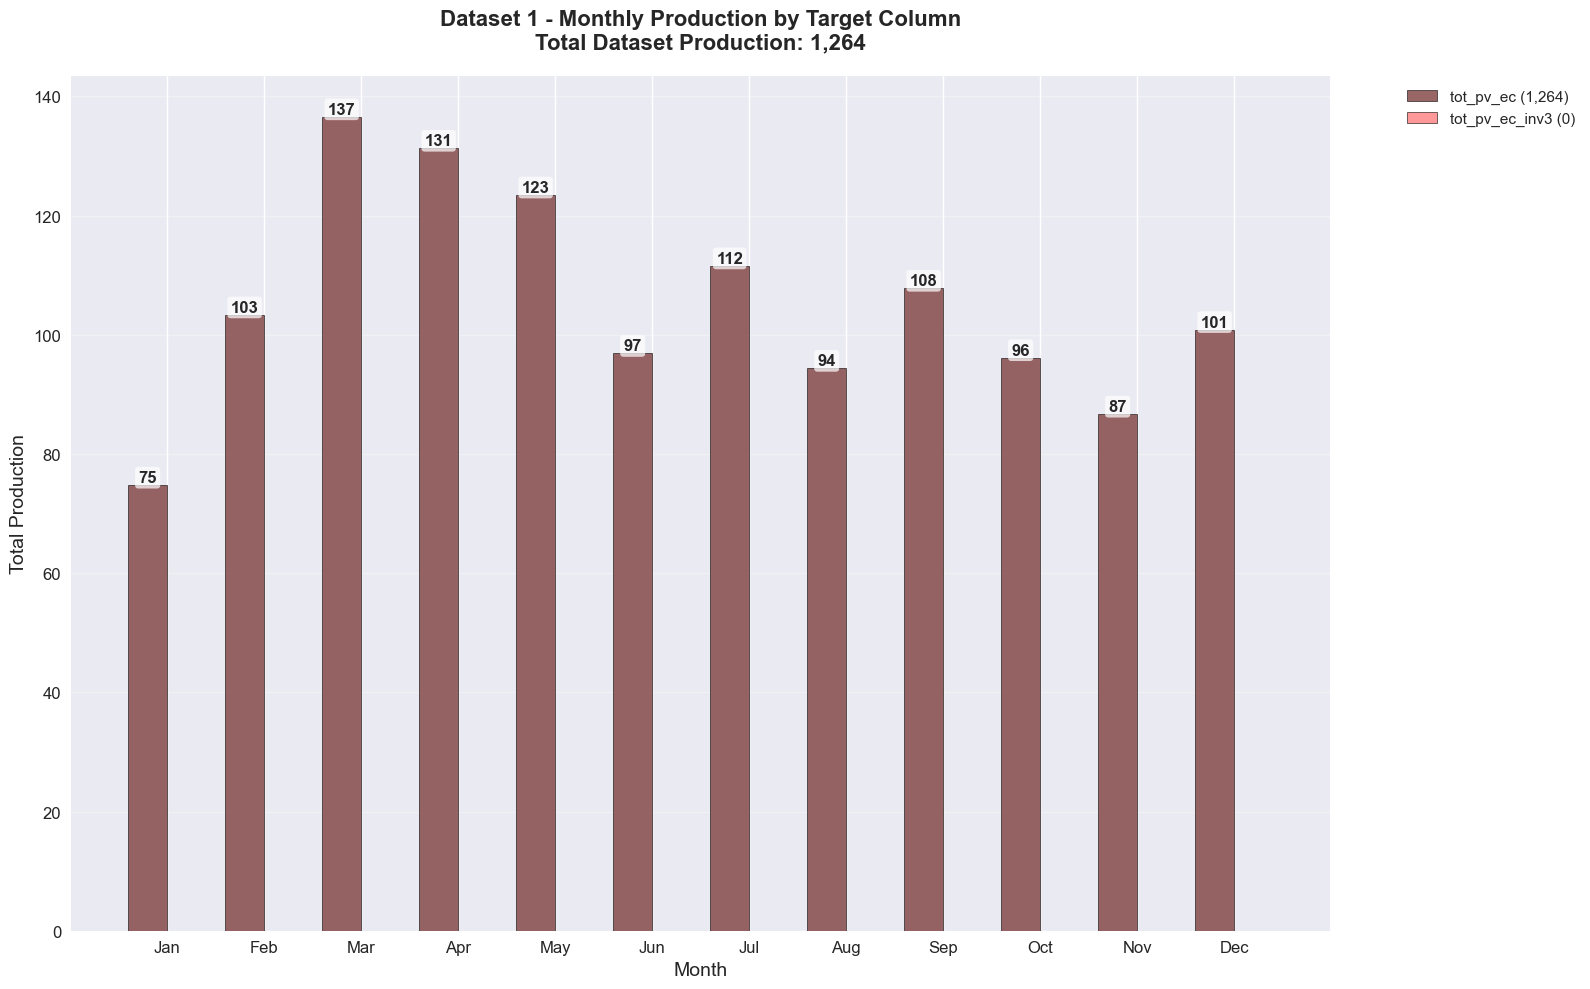


  tot_pv_ec Monthly Breakdown:
    Jan: 75 
    Feb: 103 
    Mar: 137 
    Apr: 131 
    May: 123 
    Jun: 97 
    Jul: 112 
    Aug: 94 
    Sep: 108 
    Oct: 96 
    Nov: 87 
    Dec: 101 
    Total: 1,264 

  tot_pv_ec_inv3 Monthly Breakdown:
    Jan: 0 
    Feb: 0 
    Mar: 0 
    Apr: 0 
    May: 0 
    Jun: 0 
    Jul: 0 
    Aug: 0 
    Sep: 0 
    Oct: 0 
    Nov: 0 
    Dec: 0 
    Total: 0 

2. Seasonal Analysis - Dataset 1
--------------------------------------------------


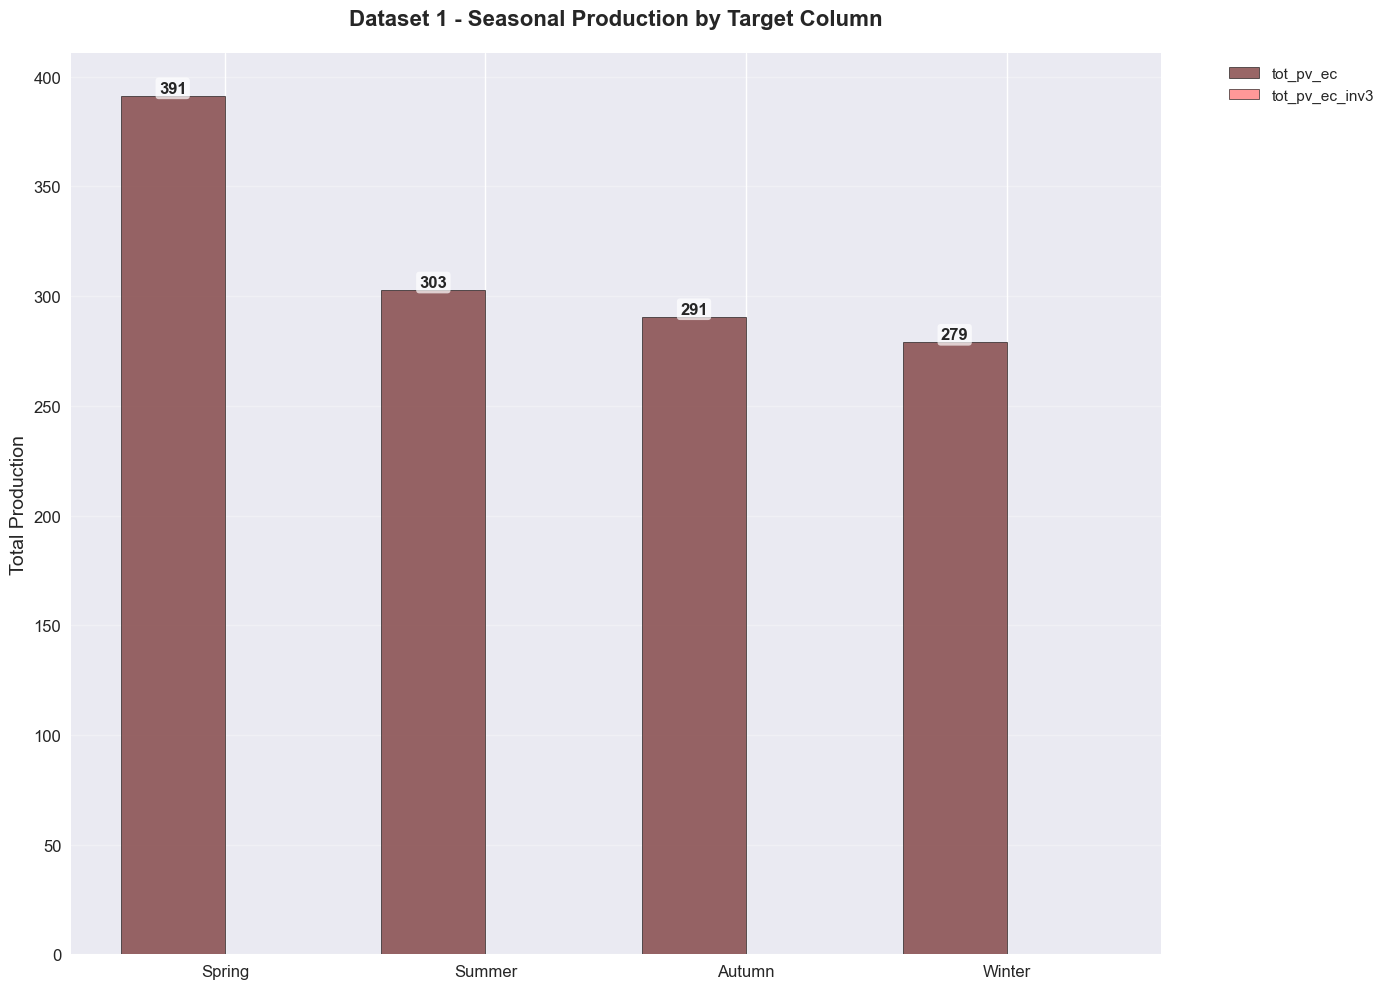


  tot_pv_ec Seasonal Breakdown:
    Spring: 391
    Summer: 303
    Autumn: 291
    Winter: 279

  tot_pv_ec_inv3 Seasonal Breakdown:
    Spring: 0
    Summer: 0
    Autumn: 0
    Winter: 0

3. Hourly Analysis - Dataset 1
--------------------------------------------------
  tot_pv_ec: Peak at 11:00 (0.0average)
  tot_pv_ec_inv3: Peak at 0:00 (0.0average)


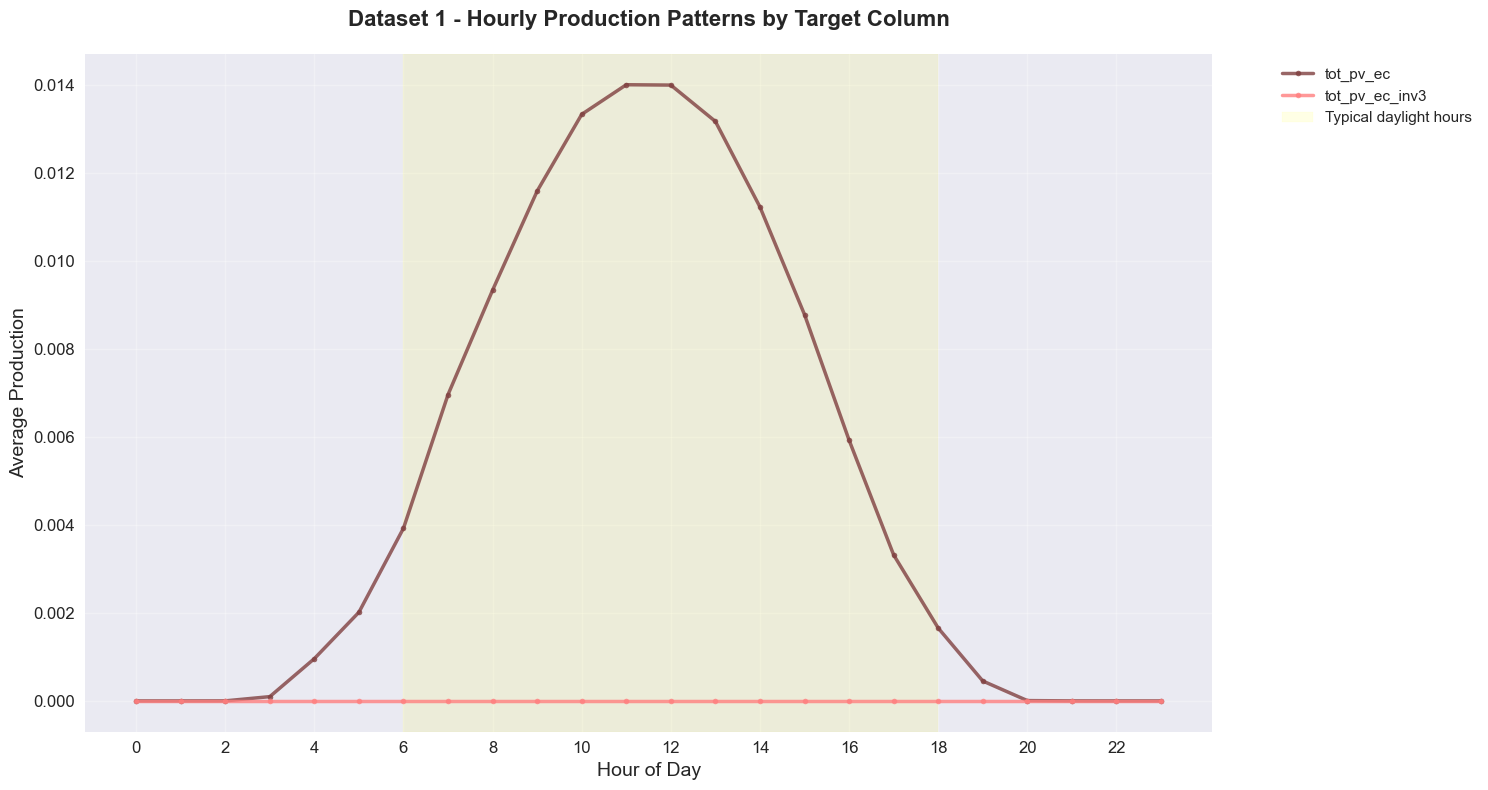



Dataset 2:
Target columns: {'tot_pv_ec_inv4', 'tot_pv_aule_r', 'tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2'}

1. Monthly Analysis - Dataset 2
--------------------------------------------------


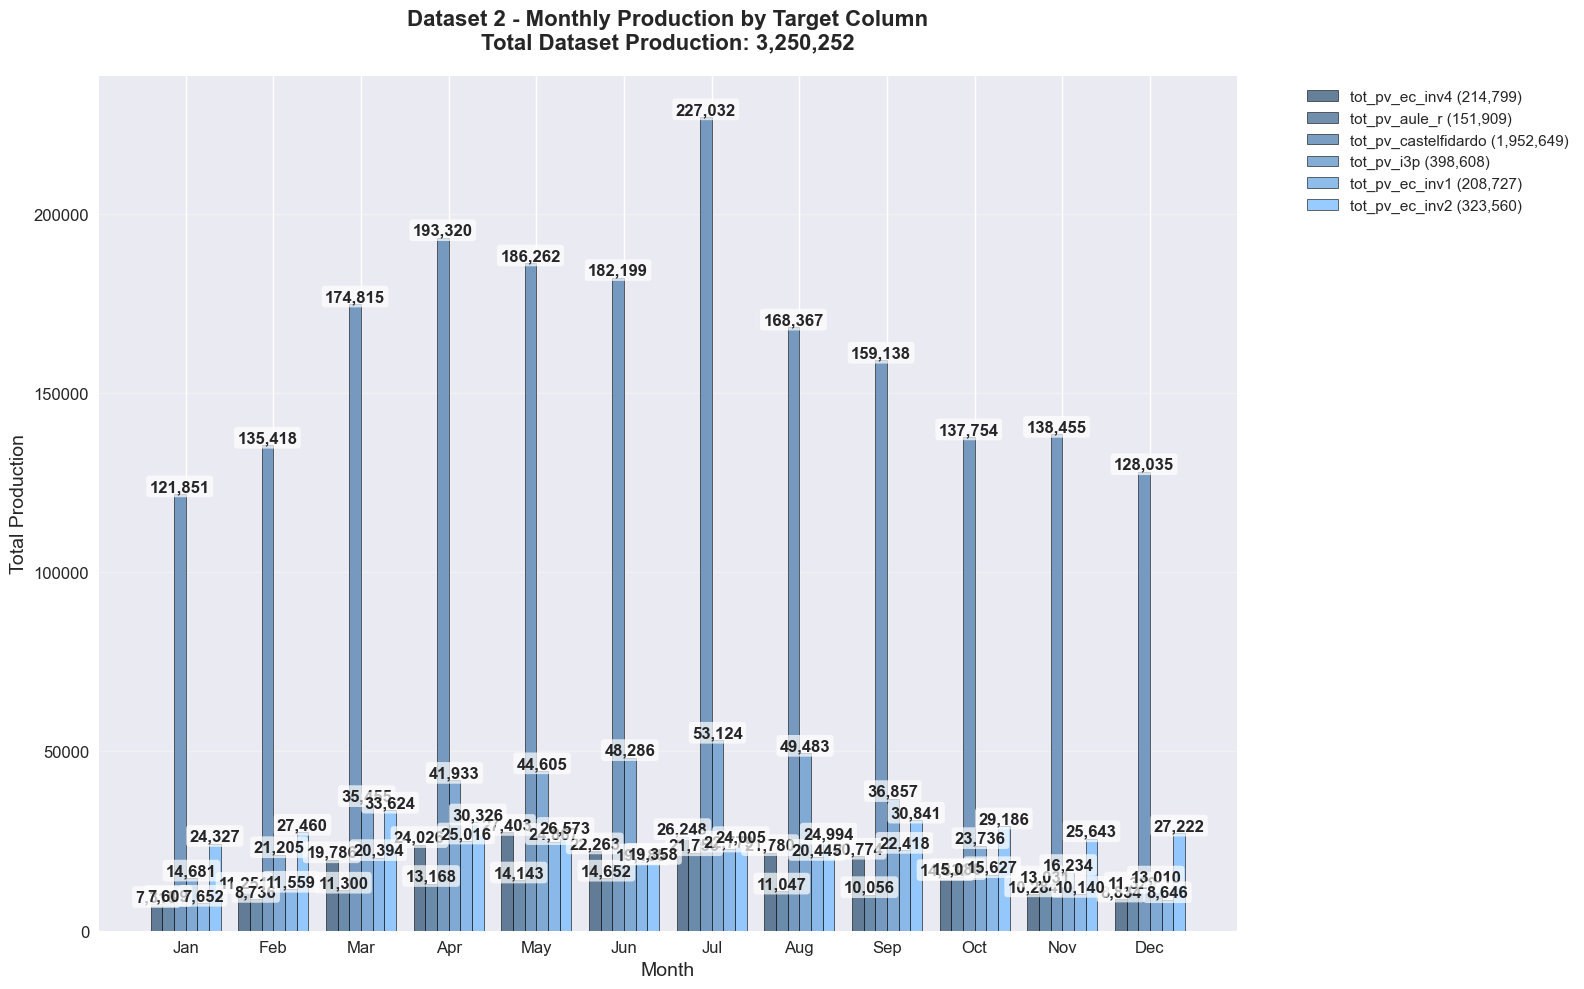


  tot_pv_ec_inv4 Monthly Breakdown:
    Jan: 7,318 
    Feb: 11,251 
    Mar: 19,786 
    Apr: 24,026 
    May: 27,403 
    Jun: 22,263 
    Jul: 26,248 
    Aug: 21,780 
    Sep: 20,774 
    Oct: 14,832 
    Nov: 10,284 
    Dec: 8,834 
    Total: 214,799 

  tot_pv_aule_r Monthly Breakdown:
    Jan: 7,609 
    Feb: 8,736 
    Mar: 11,300 
    Apr: 13,168 
    May: 14,143 
    Jun: 14,652 
    Jul: 21,756 
    Aug: 11,047 
    Sep: 10,056 
    Oct: 15,080 
    Nov: 13,031 
    Dec: 11,329 
    Total: 151,909 

  tot_pv_castelfidardo Monthly Breakdown:
    Jan: 121,851 
    Feb: 135,418 
    Mar: 174,815 
    Apr: 193,320 
    May: 186,262 
    Jun: 182,199 
    Jul: 227,032 
    Aug: 168,367 
    Sep: 159,138 
    Oct: 137,754 
    Nov: 138,455 
    Dec: 128,035 
    Total: 1,952,649 

  tot_pv_i3p Monthly Breakdown:
    Jan: 14,681 
    Feb: 21,205 
    Mar: 35,455 
    Apr: 41,933 
    May: 44,605 
    Jun: 48,286 
    Jul: 53,124 
    Aug: 49,483 
    Sep: 36,857 
    Oct: 23,736 

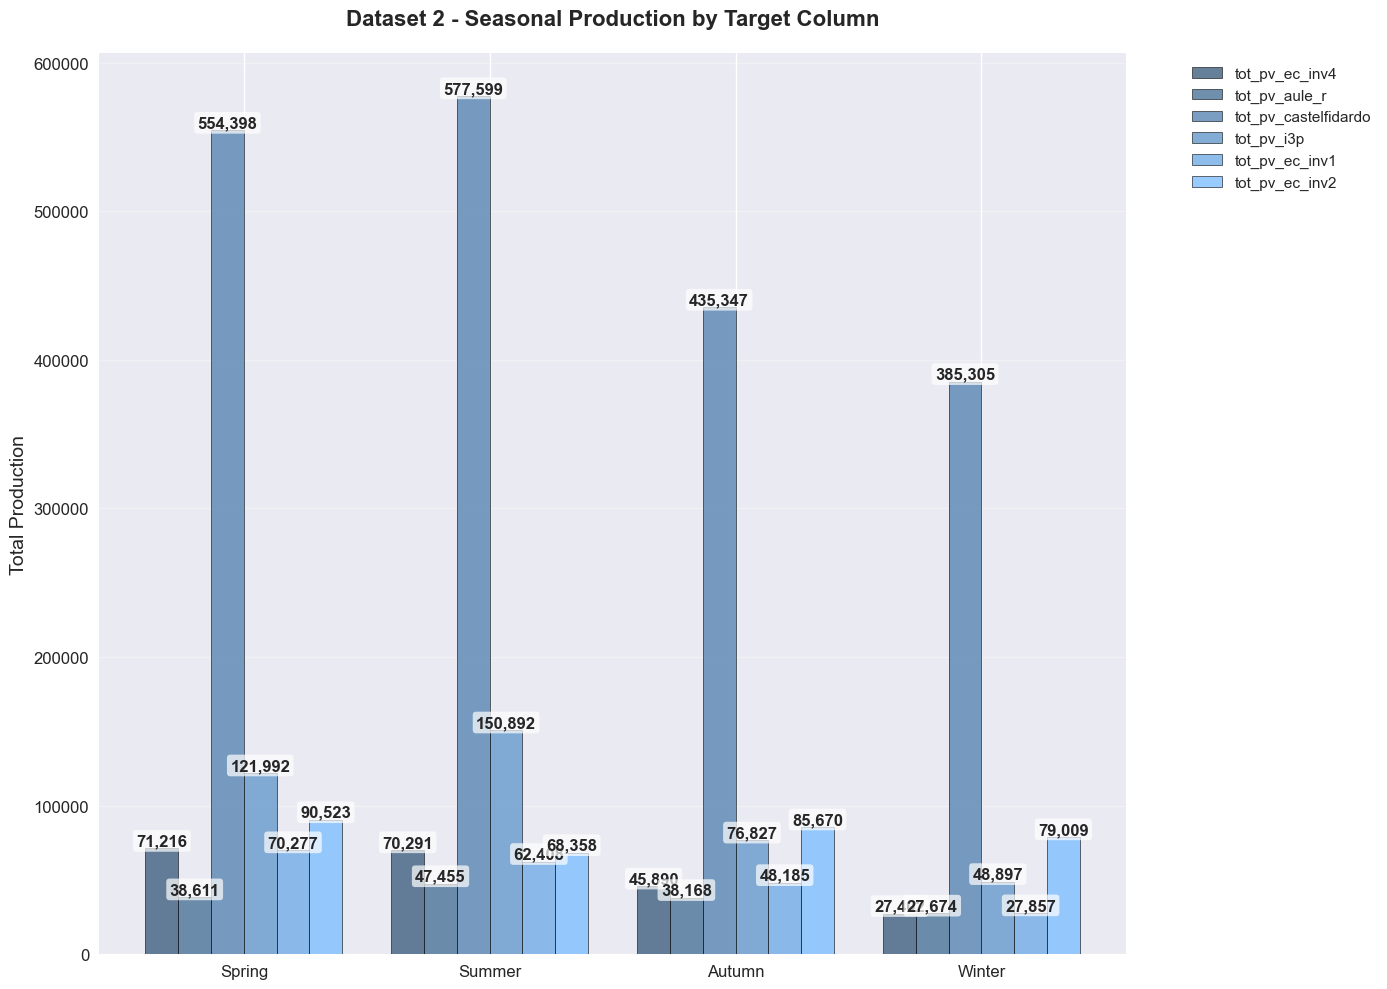


  tot_pv_ec_inv4 Seasonal Breakdown:
    Spring: 71,216
    Summer: 70,291
    Autumn: 45,890
    Winter: 27,402

  tot_pv_aule_r Seasonal Breakdown:
    Spring: 38,611
    Summer: 47,455
    Autumn: 38,168
    Winter: 27,674

  tot_pv_castelfidardo Seasonal Breakdown:
    Spring: 554,398
    Summer: 577,599
    Autumn: 435,347
    Winter: 385,305

  tot_pv_i3p Seasonal Breakdown:
    Spring: 121,992
    Summer: 150,892
    Autumn: 76,827
    Winter: 48,897

  tot_pv_ec_inv1 Seasonal Breakdown:
    Spring: 70,277
    Summer: 62,408
    Autumn: 48,185
    Winter: 27,857

  tot_pv_ec_inv2 Seasonal Breakdown:
    Spring: 90,523
    Summer: 68,358
    Autumn: 85,670
    Winter: 79,009

3. Hourly Analysis - Dataset 2
--------------------------------------------------
  tot_pv_ec_inv4: Peak at 12:00 (2.9average)
  tot_pv_aule_r: Peak at 11:00 (1.6average)
  tot_pv_castelfidardo: Peak at 11:00 (24.9average)
  tot_pv_i3p: Peak at 11:00 (4.9average)
  tot_pv_ec_inv1: Peak at 12:00 (2.9average)

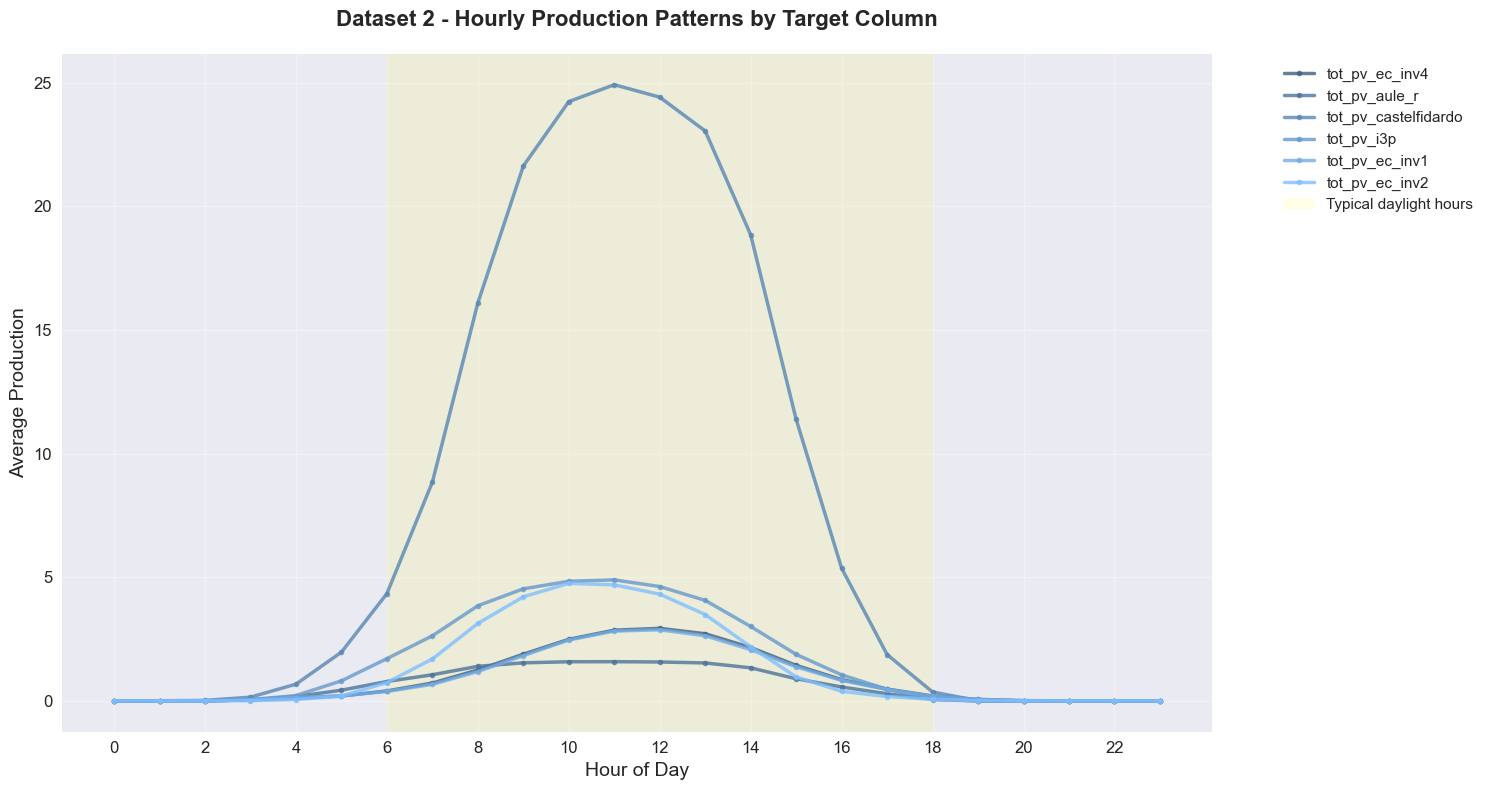



Dataset 3:
Target columns: {'tot_pv_aule_p', 'tot_pv_aule_p_i2', 'tot_pv_aule_p_i1'}

1. Monthly Analysis - Dataset 3
--------------------------------------------------


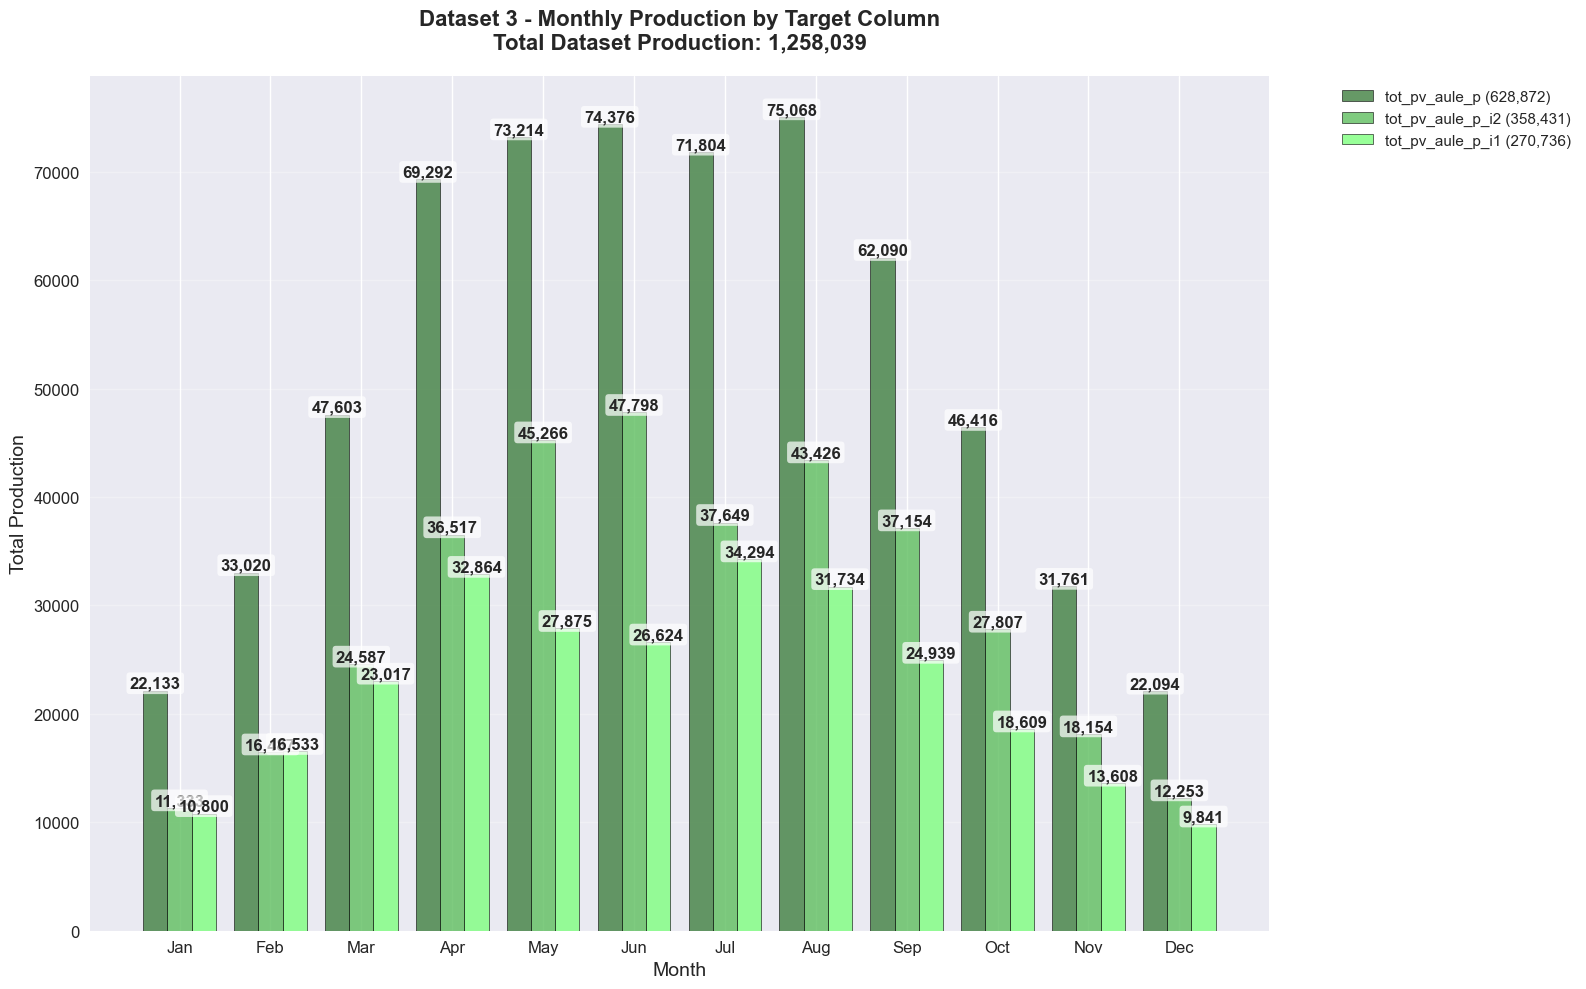


  tot_pv_aule_p Monthly Breakdown:
    Jan: 22,133 
    Feb: 33,020 
    Mar: 47,603 
    Apr: 69,292 
    May: 73,214 
    Jun: 74,376 
    Jul: 71,804 
    Aug: 75,068 
    Sep: 62,090 
    Oct: 46,416 
    Nov: 31,761 
    Dec: 22,094 
    Total: 628,872 

  tot_pv_aule_p_i2 Monthly Breakdown:
    Jan: 11,333 
    Feb: 16,487 
    Mar: 24,587 
    Apr: 36,517 
    May: 45,266 
    Jun: 47,798 
    Jul: 37,649 
    Aug: 43,426 
    Sep: 37,154 
    Oct: 27,807 
    Nov: 18,154 
    Dec: 12,253 
    Total: 358,431 

  tot_pv_aule_p_i1 Monthly Breakdown:
    Jan: 10,800 
    Feb: 16,533 
    Mar: 23,017 
    Apr: 32,864 
    May: 27,875 
    Jun: 26,624 
    Jul: 34,294 
    Aug: 31,734 
    Sep: 24,939 
    Oct: 18,609 
    Nov: 13,608 
    Dec: 9,841 
    Total: 270,736 

2. Seasonal Analysis - Dataset 3
--------------------------------------------------


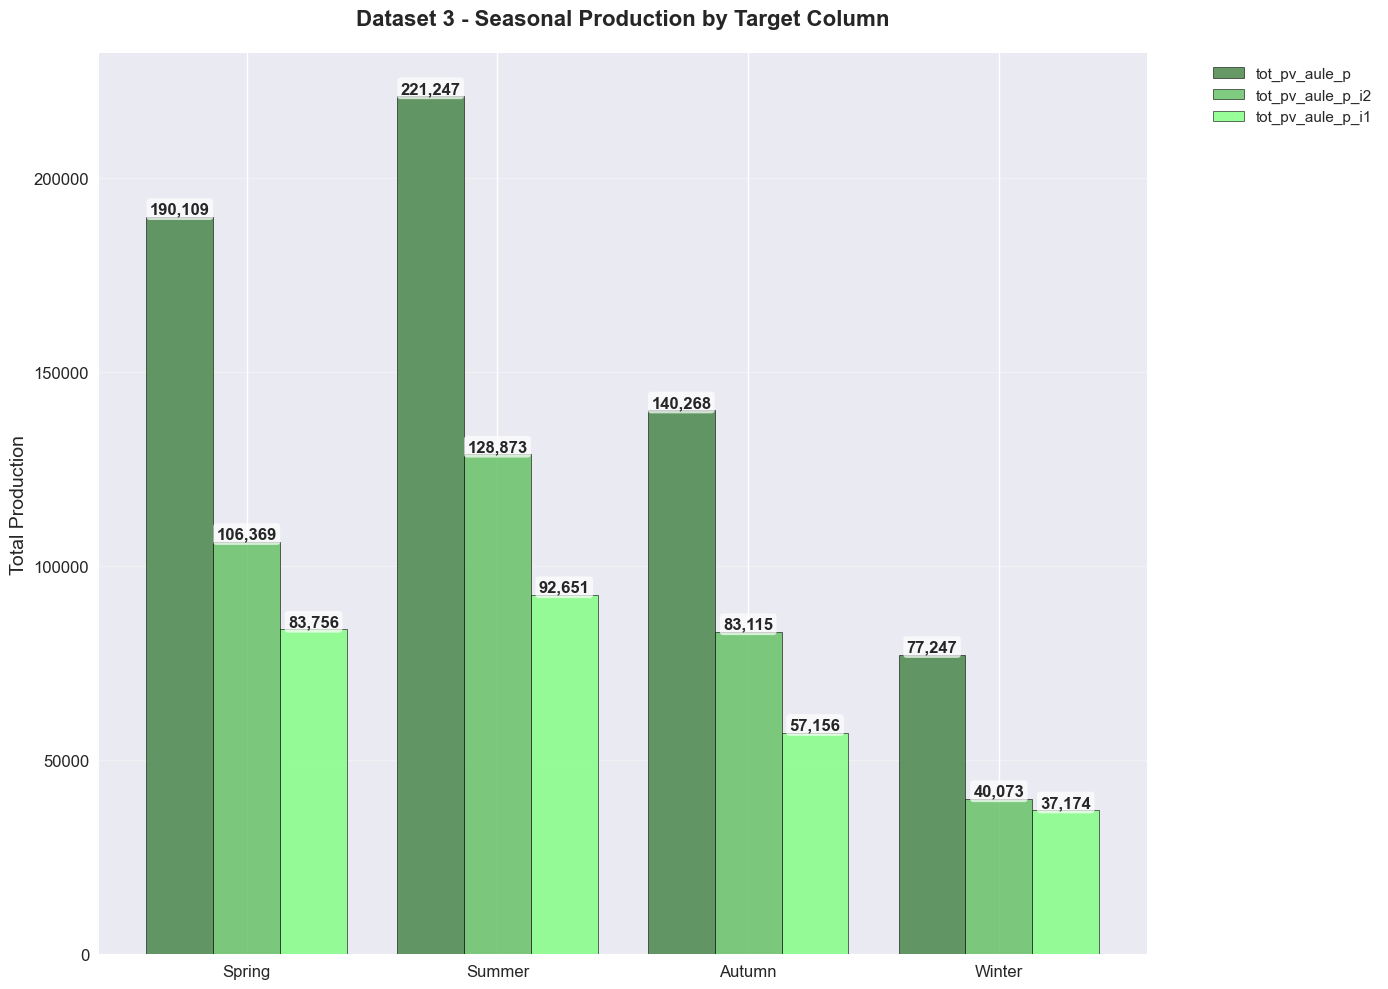


  tot_pv_aule_p Seasonal Breakdown:
    Spring: 190,109
    Summer: 221,247
    Autumn: 140,268
    Winter: 77,247

  tot_pv_aule_p_i2 Seasonal Breakdown:
    Spring: 106,369
    Summer: 128,873
    Autumn: 83,115
    Winter: 40,073

  tot_pv_aule_p_i1 Seasonal Breakdown:
    Spring: 83,756
    Summer: 92,651
    Autumn: 57,156
    Winter: 37,174

3. Hourly Analysis - Dataset 3
--------------------------------------------------
  tot_pv_aule_p: Peak at 11:00 (15.3average)
  tot_pv_aule_p_i2: Peak at 11:00 (8.6average)
  tot_pv_aule_p_i1: Peak at 11:00 (6.8average)


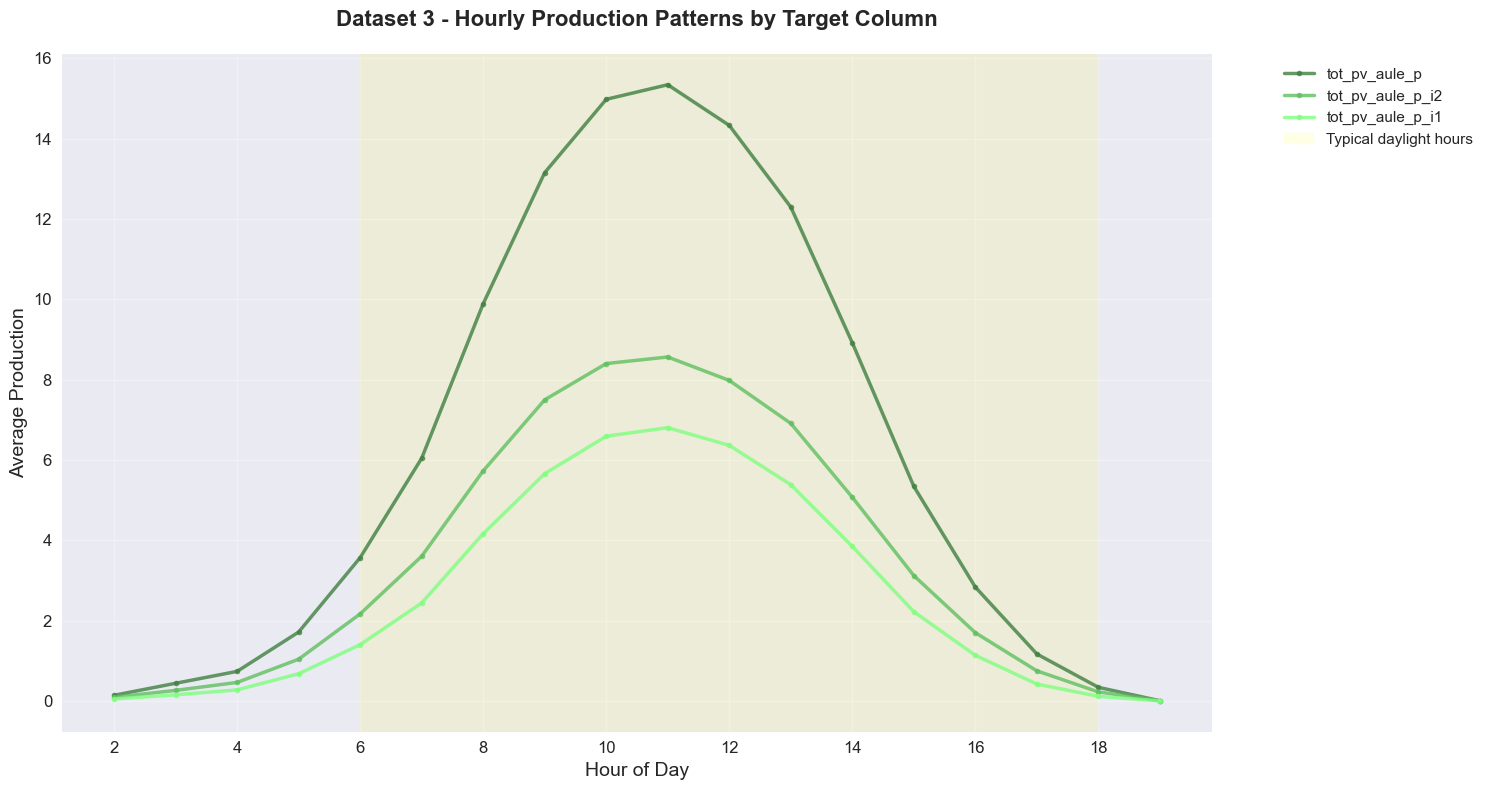



Dataset 4:
Target columns: {'tot_pv_cit'}

1. Monthly Analysis - Dataset 4
--------------------------------------------------


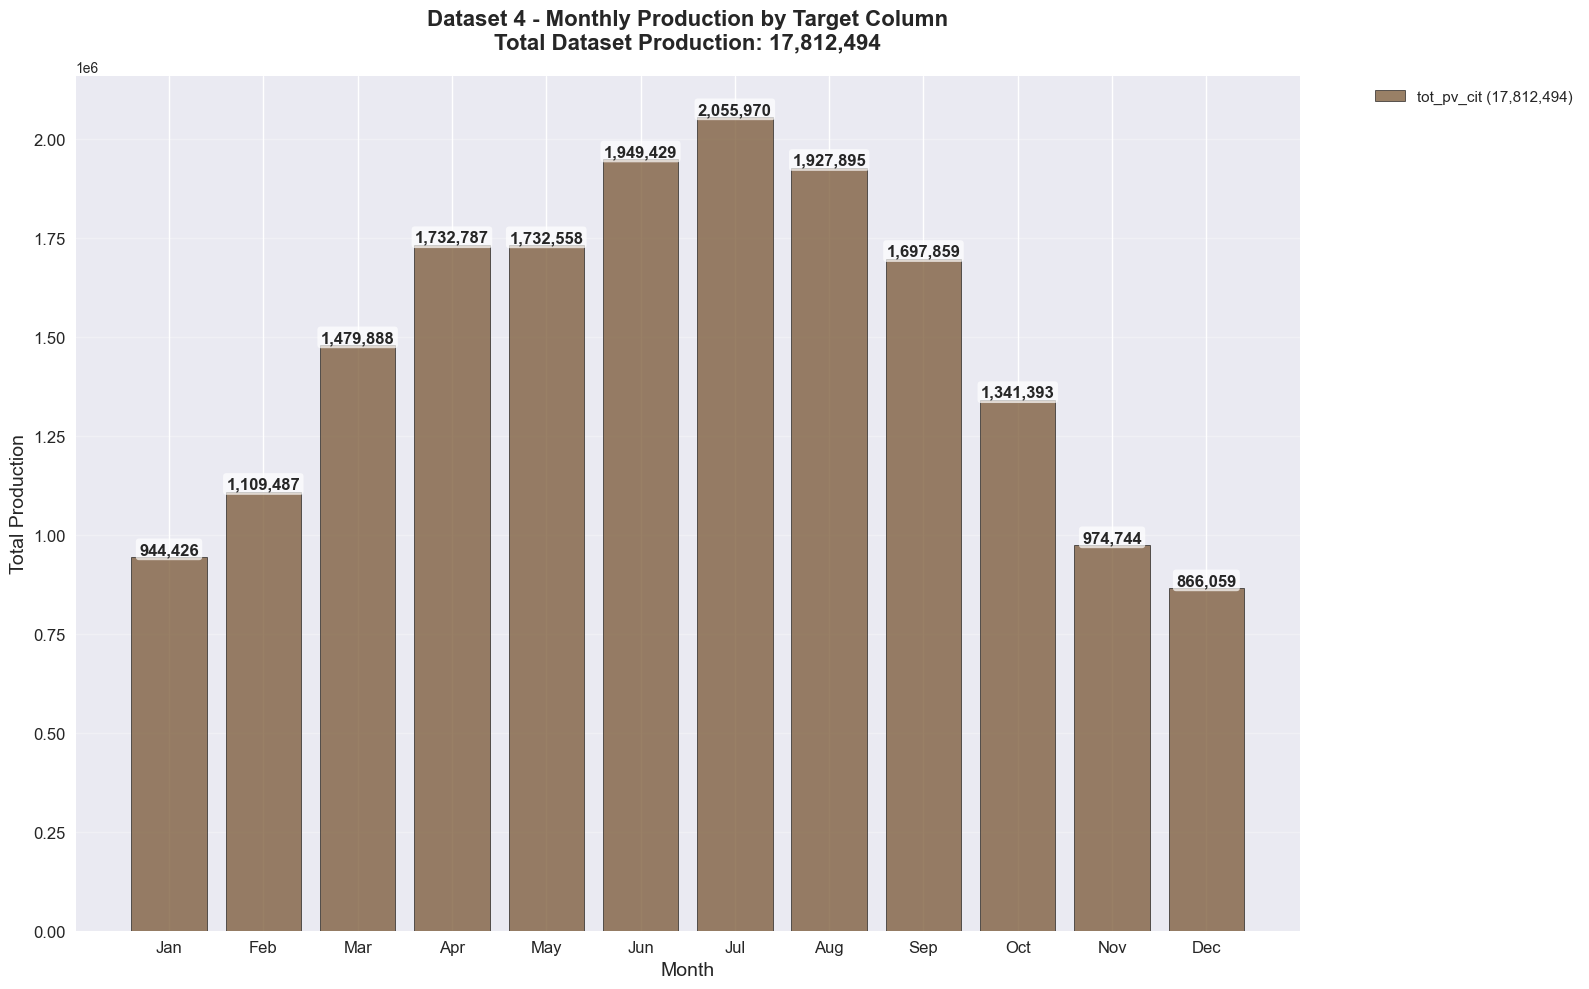


  tot_pv_cit Monthly Breakdown:
    Jan: 944,426 
    Feb: 1,109,487 
    Mar: 1,479,888 
    Apr: 1,732,787 
    May: 1,732,558 
    Jun: 1,949,429 
    Jul: 2,055,970 
    Aug: 1,927,895 
    Sep: 1,697,859 
    Oct: 1,341,393 
    Nov: 974,744 
    Dec: 866,059 
    Total: 17,812,494 

2. Seasonal Analysis - Dataset 4
--------------------------------------------------


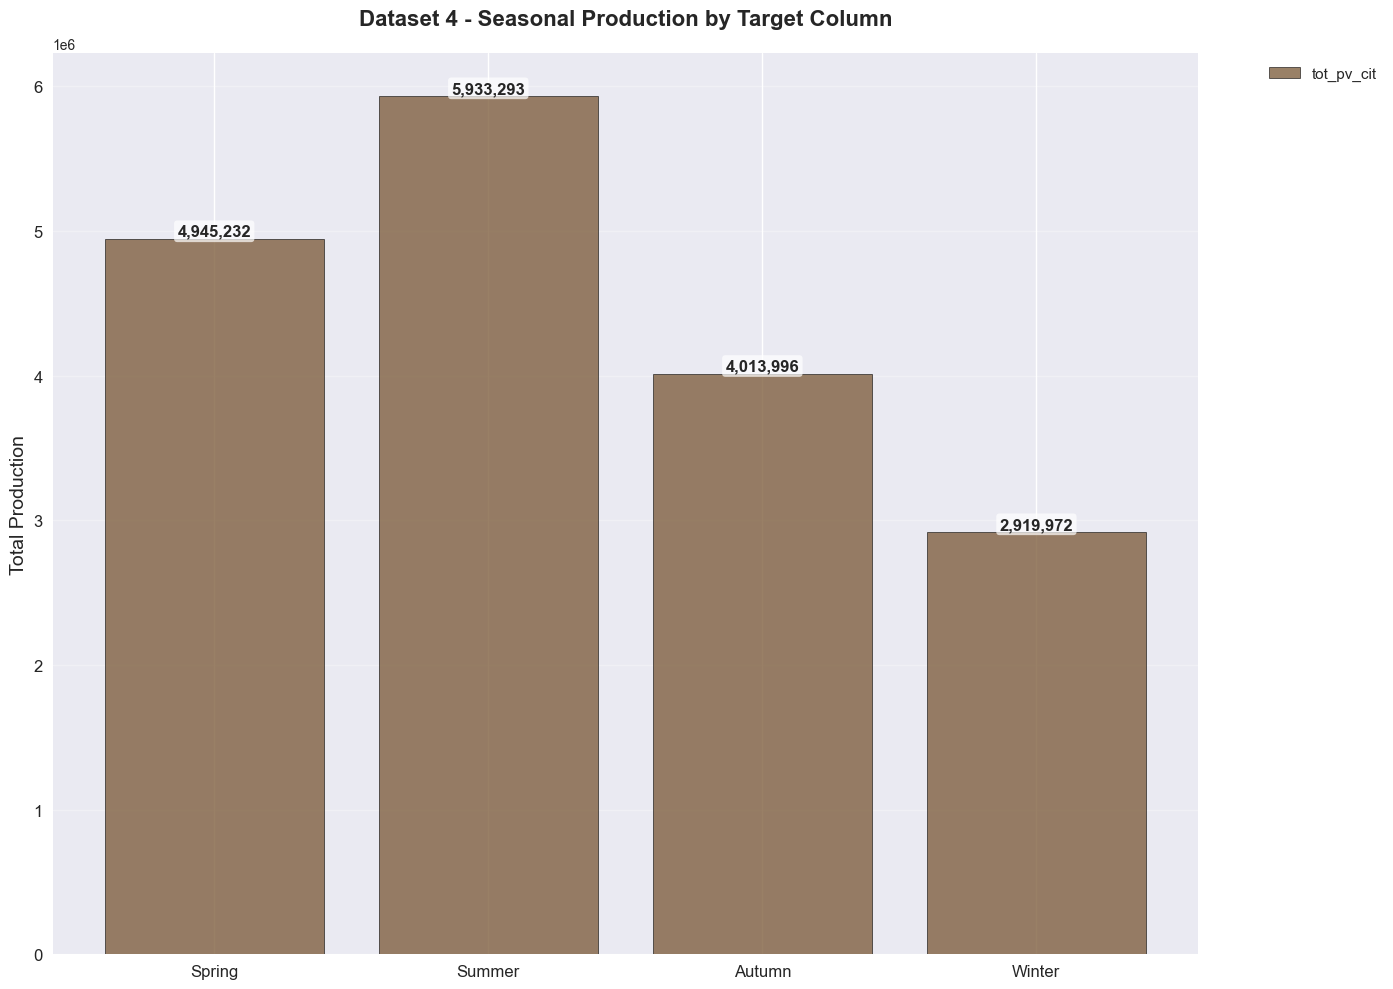


  tot_pv_cit Seasonal Breakdown:
    Spring: 4,945,232
    Summer: 5,933,293
    Autumn: 4,013,996
    Winter: 2,919,972

3. Hourly Analysis - Dataset 4
--------------------------------------------------
  tot_pv_cit: Peak at 11:00 (207.4average)


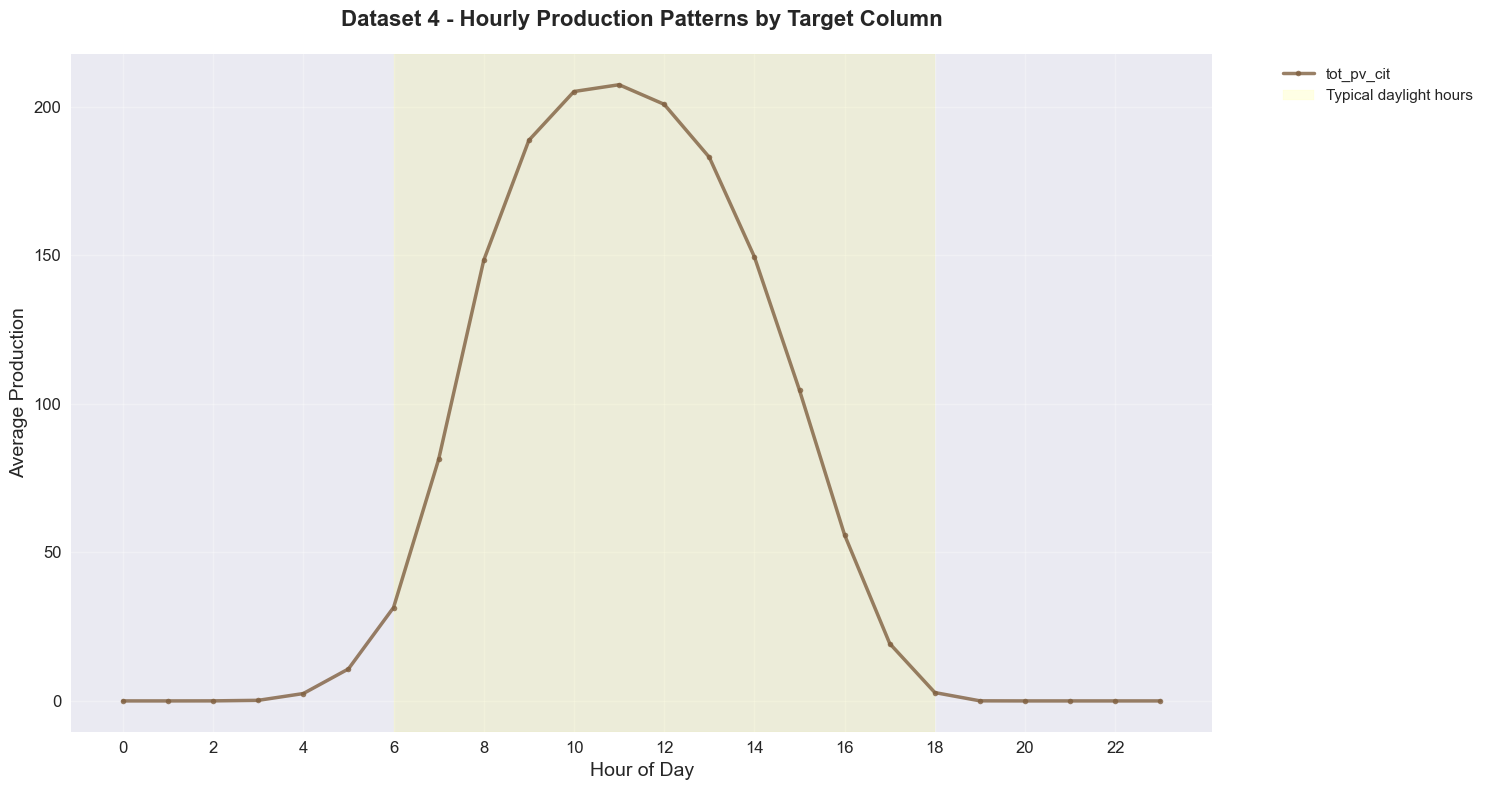



I3P Dataset:
Target columns: {'tot_pv_i3p_est', 'tot_pv_i3p_ovest'}

1. Monthly Analysis - I3P Dataset
--------------------------------------------------


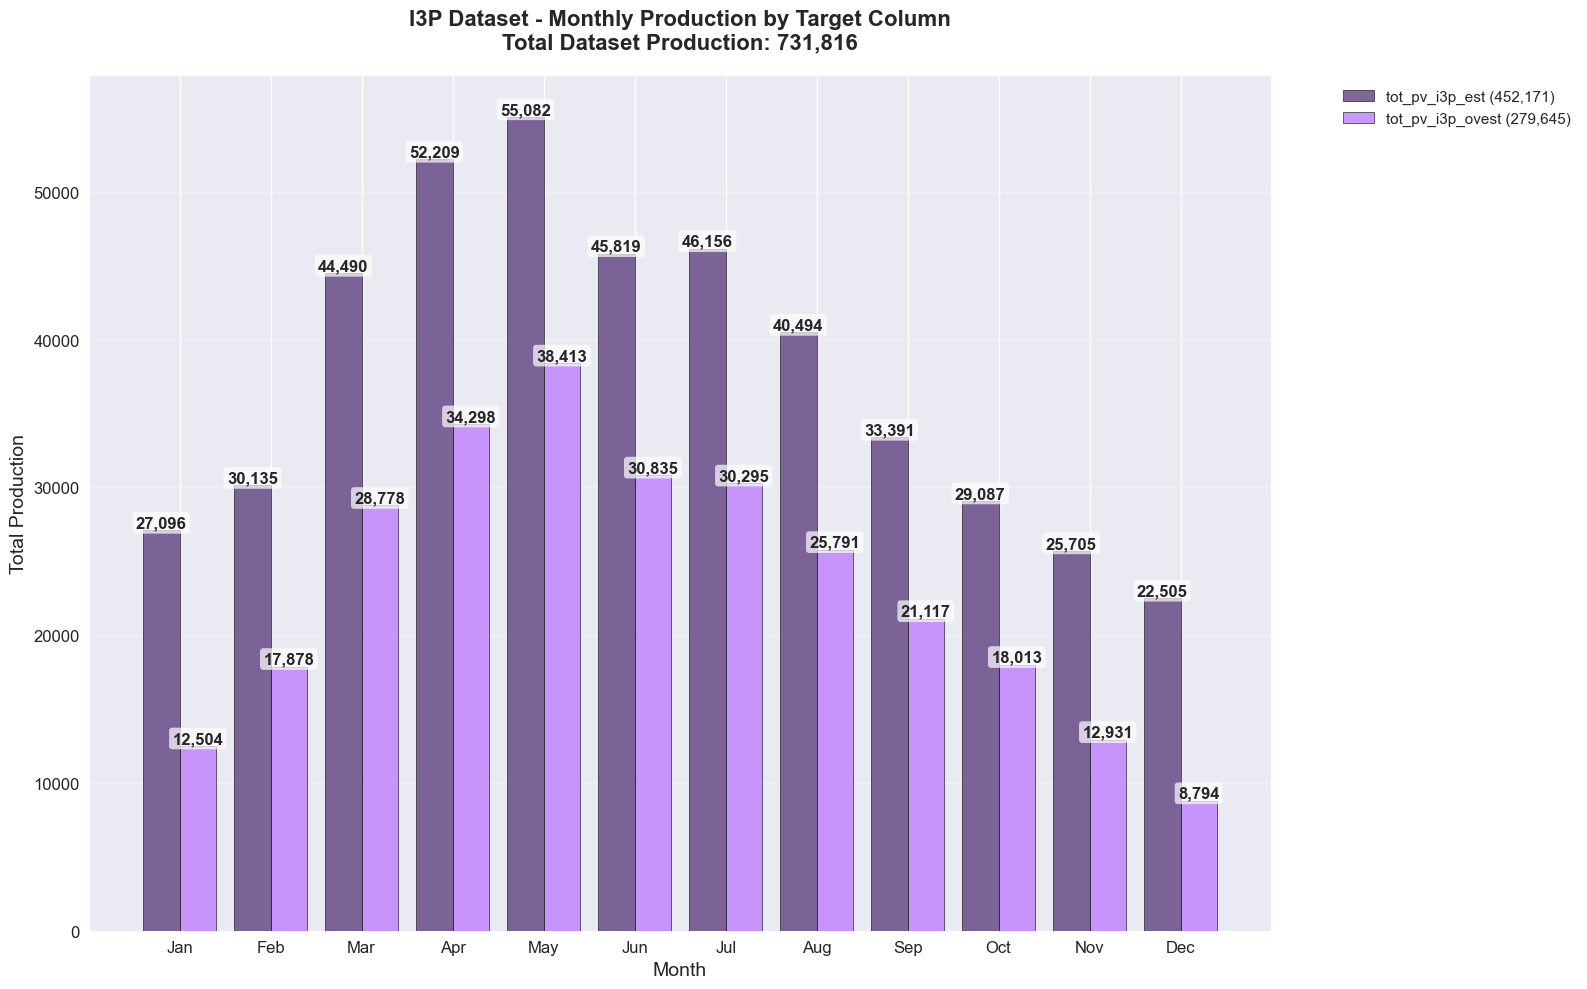


  tot_pv_i3p_est Monthly Breakdown:
    Jan: 27,096 
    Feb: 30,135 
    Mar: 44,490 
    Apr: 52,209 
    May: 55,082 
    Jun: 45,819 
    Jul: 46,156 
    Aug: 40,494 
    Sep: 33,391 
    Oct: 29,087 
    Nov: 25,705 
    Dec: 22,505 
    Total: 452,171 

  tot_pv_i3p_ovest Monthly Breakdown:
    Jan: 12,504 
    Feb: 17,878 
    Mar: 28,778 
    Apr: 34,298 
    May: 38,413 
    Jun: 30,835 
    Jul: 30,295 
    Aug: 25,791 
    Sep: 21,117 
    Oct: 18,013 
    Nov: 12,931 
    Dec: 8,794 
    Total: 279,645 

2. Seasonal Analysis - I3P Dataset
--------------------------------------------------


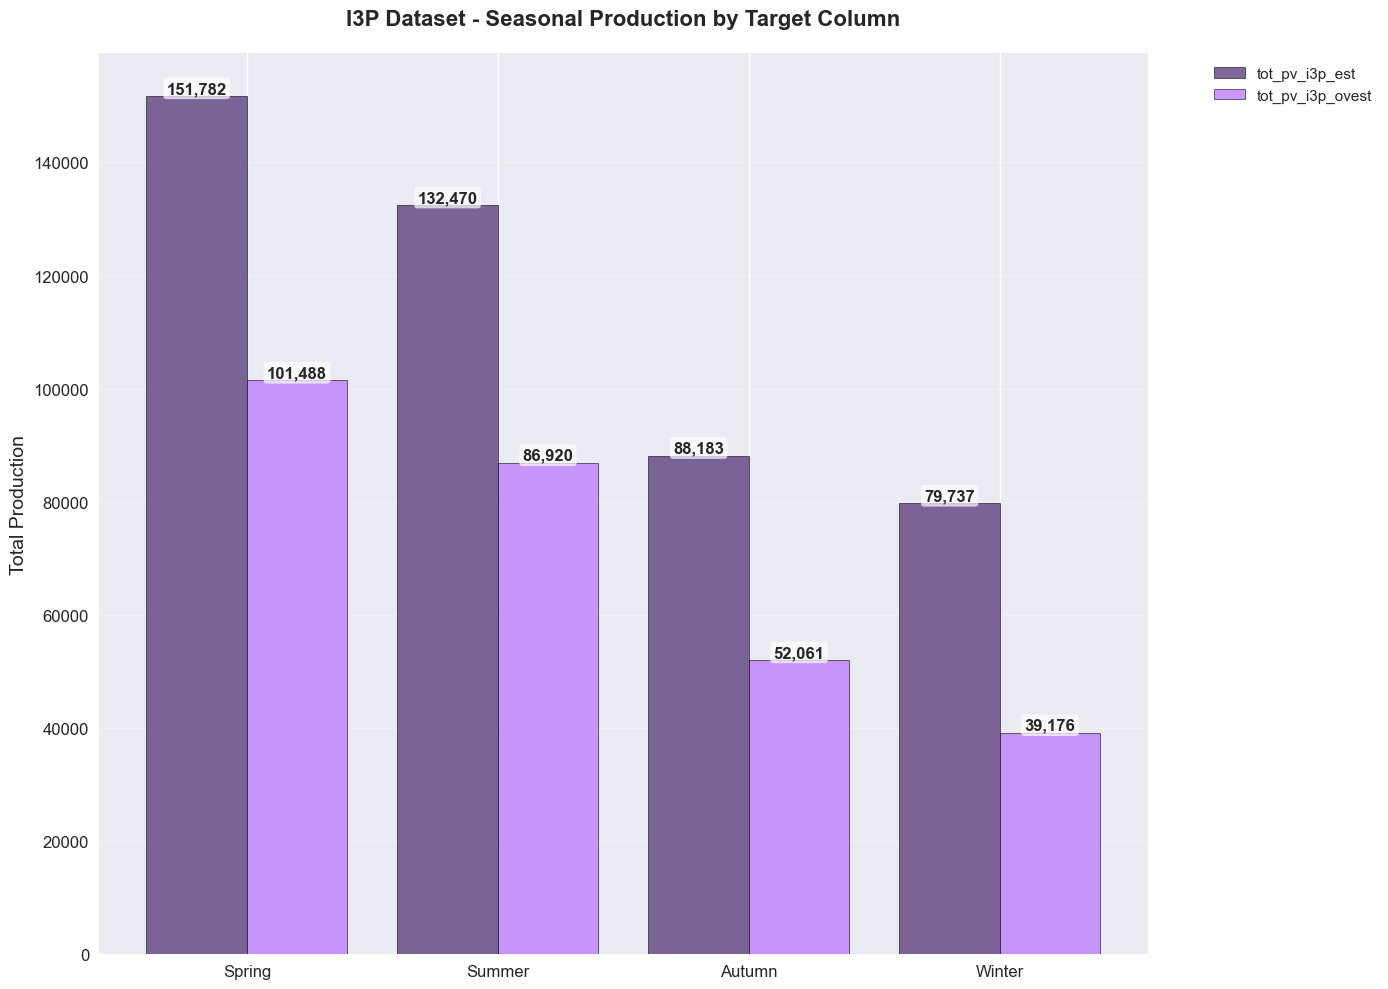


  tot_pv_i3p_est Seasonal Breakdown:
    Spring: 151,782
    Summer: 132,470
    Autumn: 88,183
    Winter: 79,737

  tot_pv_i3p_ovest Seasonal Breakdown:
    Spring: 101,488
    Summer: 86,920
    Autumn: 52,061
    Winter: 39,176

3. Hourly Analysis - I3P Dataset
--------------------------------------------------
  tot_pv_i3p_est: Peak at 10:00 (4.8average)
  tot_pv_i3p_ovest: Peak at 12:00 (2.9average)


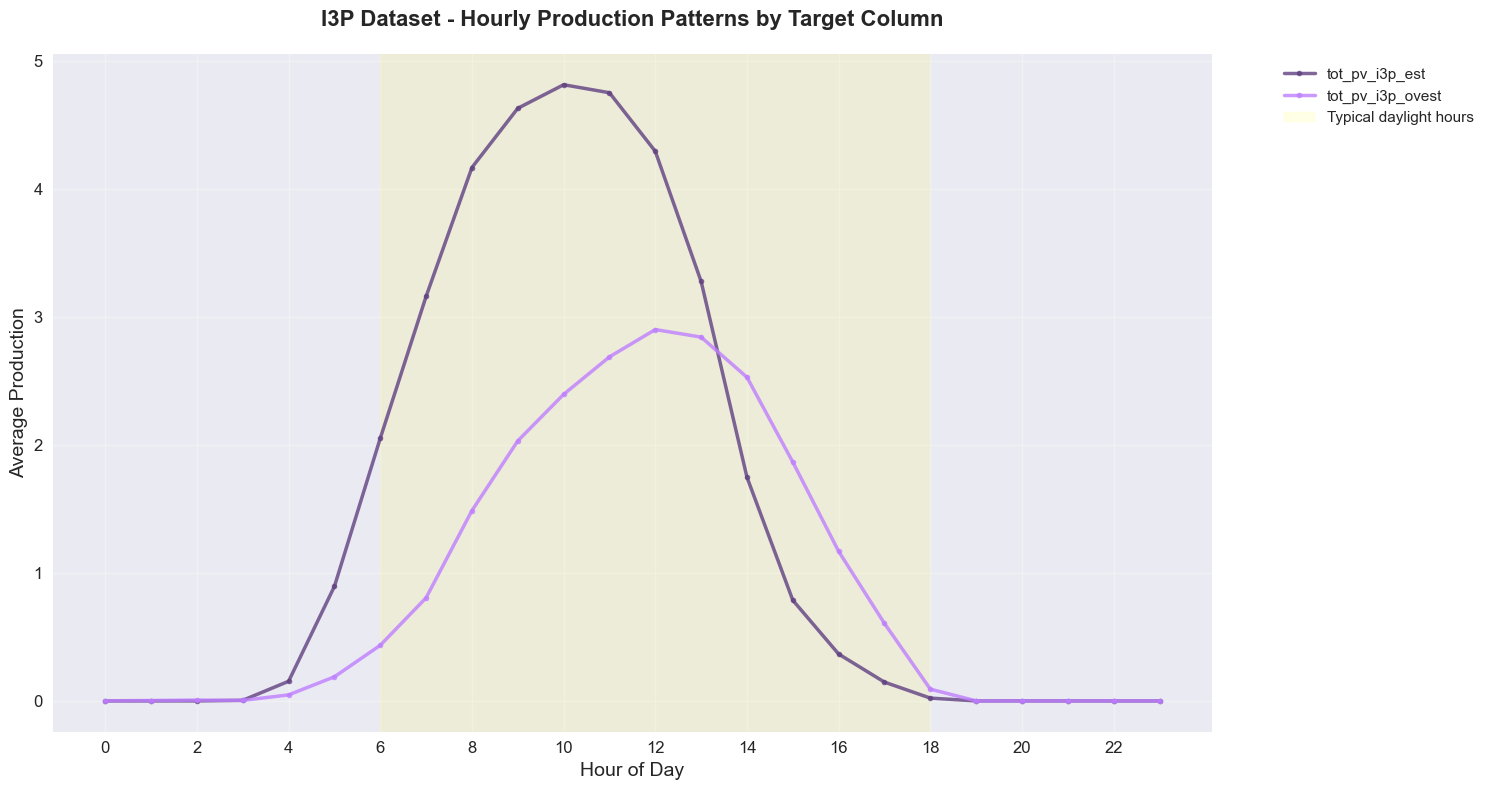



INDIVIDUAL TARGET COLUMN ANALYSIS COMPLETE


In [12]:
# INDIVIDUAL TARGET COLUMN ANALYSIS FOR ALL DATASETS
print("=" * 100)
print("INDIVIDUAL TARGET COLUMN ANALYSIS - DETAILED BREAKDOWN")
print("=" * 100)

# Define dataset information with their dataframes and target columns
datasets_info = [
    {'name': 'Dataset 1', 'df': df1, 'targets': set(available_targets_1) - {'total_pv_production'}, 'color_base': '#ff7f7f'},
    {'name': 'Dataset 2', 'df': df2, 'targets': set(available_targets_2) - {'total_pv_production'}, 'color_base': '#7fbfff'},
    {'name': 'Dataset 3', 'df': df3, 'targets': set(available_targets_3) - {'total_pv_production'}, 'color_base': '#7fff7f'},
    {'name': 'Dataset 4', 'df': df4, 'targets': set(available_targets_4) - {'total_pv_production'}, 'color_base': '#ffbf7f'},
    {'name': 'I3P Dataset', 'df': df_i3p, 'targets': set(available_targets_i3p) - {'total_pv_production'}, 'color_base': '#bf7fff'}
]

# Function to generate color variations
def generate_colors(base_color, num_colors):
    import matplotlib.colors as mcolors
    base_rgb = mcolors.hex2color(base_color)
    return [tuple(min(1.0, c * (0.5 + i * 0.5 / max(1, num_colors - 1))) for c in base_rgb) for i in range(num_colors)]

# Label helper
def add_labels(ax, bars, values):
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:,.0f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none')
            )

# Process each dataset
for dataset_info in datasets_info:
    dataset_name = dataset_info['name']
    df = dataset_info['df']
    targets = dataset_info['targets']
    base_color = dataset_info['color_base']
    
    print(f"\n{dataset_name}:")
    print(f"Target columns: {targets}")
    
    if not targets:
        print(f"No target columns found for {dataset_name}")
        continue
    
    df_copy = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'])
    df_copy.set_index('date', inplace=True)
    
    colors = generate_colors(base_color, len(targets))
    
    # 1. Monthly Analysis
    print(f"\n1. Monthly Analysis - {dataset_name}")
    print("-" * 50)

    fig, ax = plt.subplots(figsize=(16, 10))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    width = 0.8 / len(targets)
    x = np.arange(1, 13)
    total_monthly_data = {}

    for i, target in enumerate(targets):
        if target in df_copy.columns:
            monthly_totals = df_copy[target].groupby(df_copy.index.month).sum()
            total = monthly_totals.sum()
            total_monthly_data[target] = {'monthly_totals': monthly_totals, 'total_production': total}
            
            offset = (i - len(targets)/2 + 0.5) * width
            bars = ax.bar(x + offset, monthly_totals.values, width,
                          label=f'{target} ({total:,.0f})',
                          color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.8)
            
            add_labels(ax, bars, monthly_totals.values)

    total_dataset_production = sum(data['total_production'] for data in total_monthly_data.values())
    ax.set_title(f'{dataset_name} - Monthly Production by Target Column\nTotal Dataset Production: {total_dataset_production:,.0f}',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Month', fontsize=14)
    ax.set_ylabel('Total Production', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(month_names, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

    for target, data in total_monthly_data.items():
        print(f"\n  {target} Monthly Breakdown:")
        for month, total in data['monthly_totals'].items():
            print(f"    {month_names[month-1]}: {total:,.0f} ")
        print(f"    Total: {data['total_production']:,.0f} ")
  

    # 2. Seasonal Analysis
    print(f"\n2. Seasonal Analysis - {dataset_name}")
    print("-" * 50)

    fig, ax = plt.subplots(figsize=(14, 10))
    seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
    season_mapping = {3: 'Spring', 4: 'Spring', 5: 'Spring',
                      6: 'Summer', 7: 'Summer', 8: 'Summer',
                      9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
                      12: 'Winter', 1: 'Winter', 2: 'Winter'}
    
    x = np.arange(len(seasons))
    width = 0.8 / len(targets)
    total_seasonal_data = {}

    for i, target in enumerate(targets):
        if target in df_copy.columns:
            df_copy['season'] = df_copy.index.month.map(season_mapping)
            seasonal_totals = df_copy.groupby('season')[target].sum()
            ordered_totals = [seasonal_totals.get(season, 0) for season in seasons]
            total = sum(ordered_totals)
            total_seasonal_data[target] = {'seasonal_totals': dict(zip(seasons, ordered_totals)), 'total_production': total}
            
            offset = (i - len(targets)/2 + 0.5) * width
            bars = ax.bar(x + offset, ordered_totals, width,
                          label=f'{target}', color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.8)
            
            add_labels(ax, bars, ordered_totals)

    ax.set_title(f'{dataset_name} - Seasonal Production by Target Column',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Total Production', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(seasons, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

    for target, data in total_seasonal_data.items():
        print(f"\n  {target} Seasonal Breakdown:")
        for season, total in data['seasonal_totals'].items():
            print(f"    {season}: {total:,.0f}")

    # 3. Hourly Analysis
    print(f"\n3. Hourly Analysis - {dataset_name}")
    print("-" * 50)

    fig, ax = plt.subplots(figsize=(15, 8))

    for i, target in enumerate(targets):
        if target in df_copy.columns:
            hourly_avg = df_copy.groupby(df_copy.index.hour)[target].mean()
            ax.plot(hourly_avg.index, hourly_avg.values,
                    label=f'{target}', color=colors[i], linewidth=2.5,
                    marker='o', markersize=4, alpha=0.8)
            if not hourly_avg.empty:
                peak_hour = hourly_avg.idxmax()
                print(f"  {target}: Peak at {peak_hour}:00 ({hourly_avg.max():.1f}average)")

    ax.set_title(f'{dataset_name} - Hourly Production Patterns by Target Column',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Hour of Day', fontsize=14)
    ax.set_ylabel('Average Production', fontsize=14)
    ax.set_xticks(range(0, 24, 2))
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.axvspan(6, 18, color='yellow', alpha=0.1, label='Typical daylight hours')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"\n{'=' * 80}")

print("\n" + "=" * 100)
print("INDIVIDUAL TARGET COLUMN ANALYSIS COMPLETE")
print("=" * 100)


ENHANCED HOURLY ANALYSIS WITH PEAK INDICATORS

Dataset 1:
Target columns: {'tot_pv_ec', 'tot_pv_ec_inv3'}

Enhanced Hourly Analysis - Dataset 1
--------------------------------------------------
  tot_pv_ec: Peak at 11:00 (0.0 average)
  tot_pv_ec_inv3: Peak at 0:00 (0.0 average)


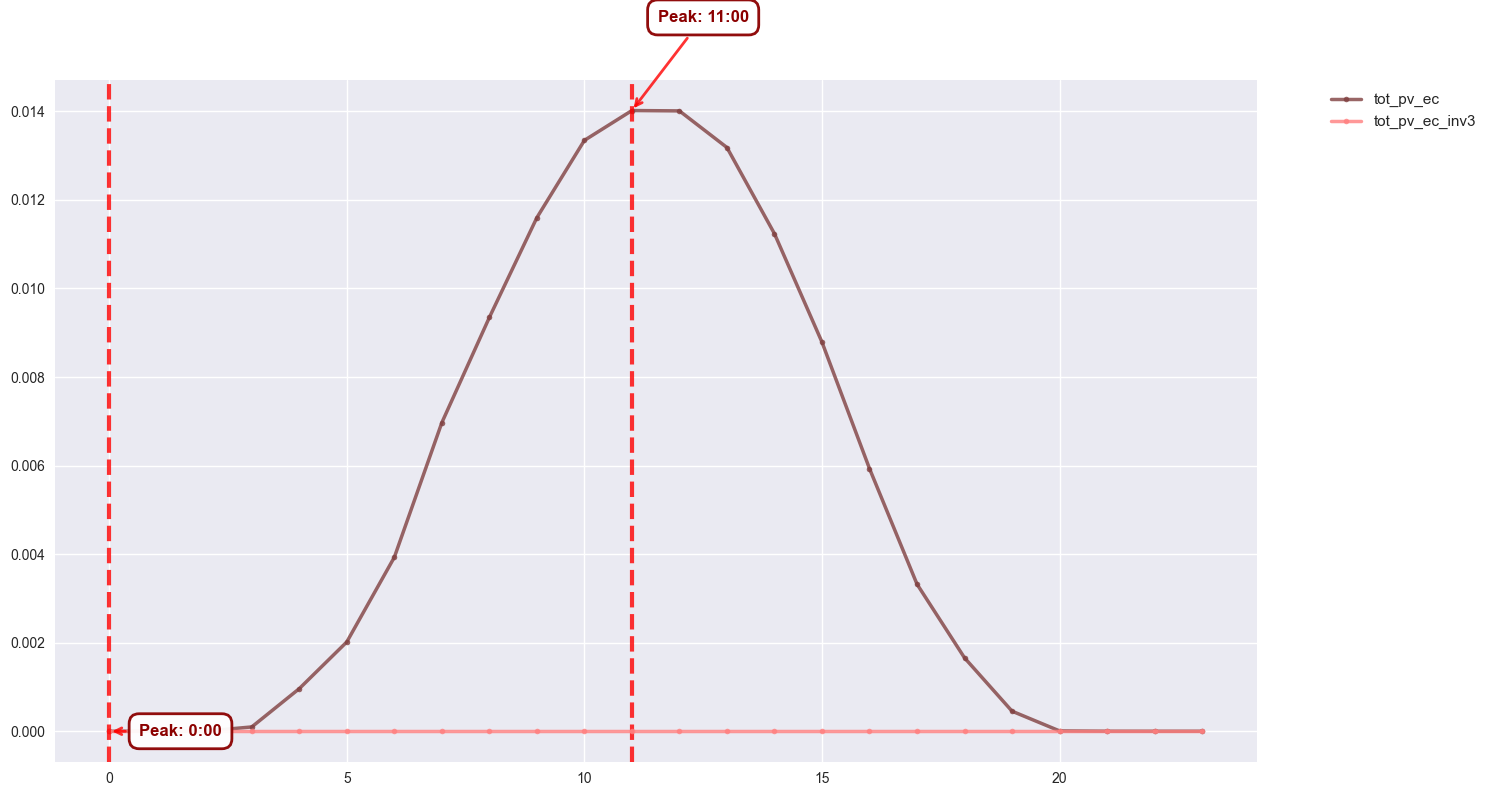

  Peak hours for Dataset 1: [np.int32(0), np.int32(11)]
  Peak hours range from 0:00 to 11:00


Dataset 2:
Target columns: {'tot_pv_ec_inv4', 'tot_pv_aule_r', 'tot_pv_castelfidardo', 'tot_pv_i3p', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2'}

Enhanced Hourly Analysis - Dataset 2
--------------------------------------------------
  tot_pv_ec_inv4: Peak at 12:00 (2.9 average)
  tot_pv_aule_r: Peak at 11:00 (1.6 average)
  tot_pv_castelfidardo: Peak at 11:00 (24.9 average)
  tot_pv_i3p: Peak at 11:00 (4.9 average)
  tot_pv_ec_inv1: Peak at 12:00 (2.9 average)
  tot_pv_ec_inv2: Peak at 10:00 (4.8 average)


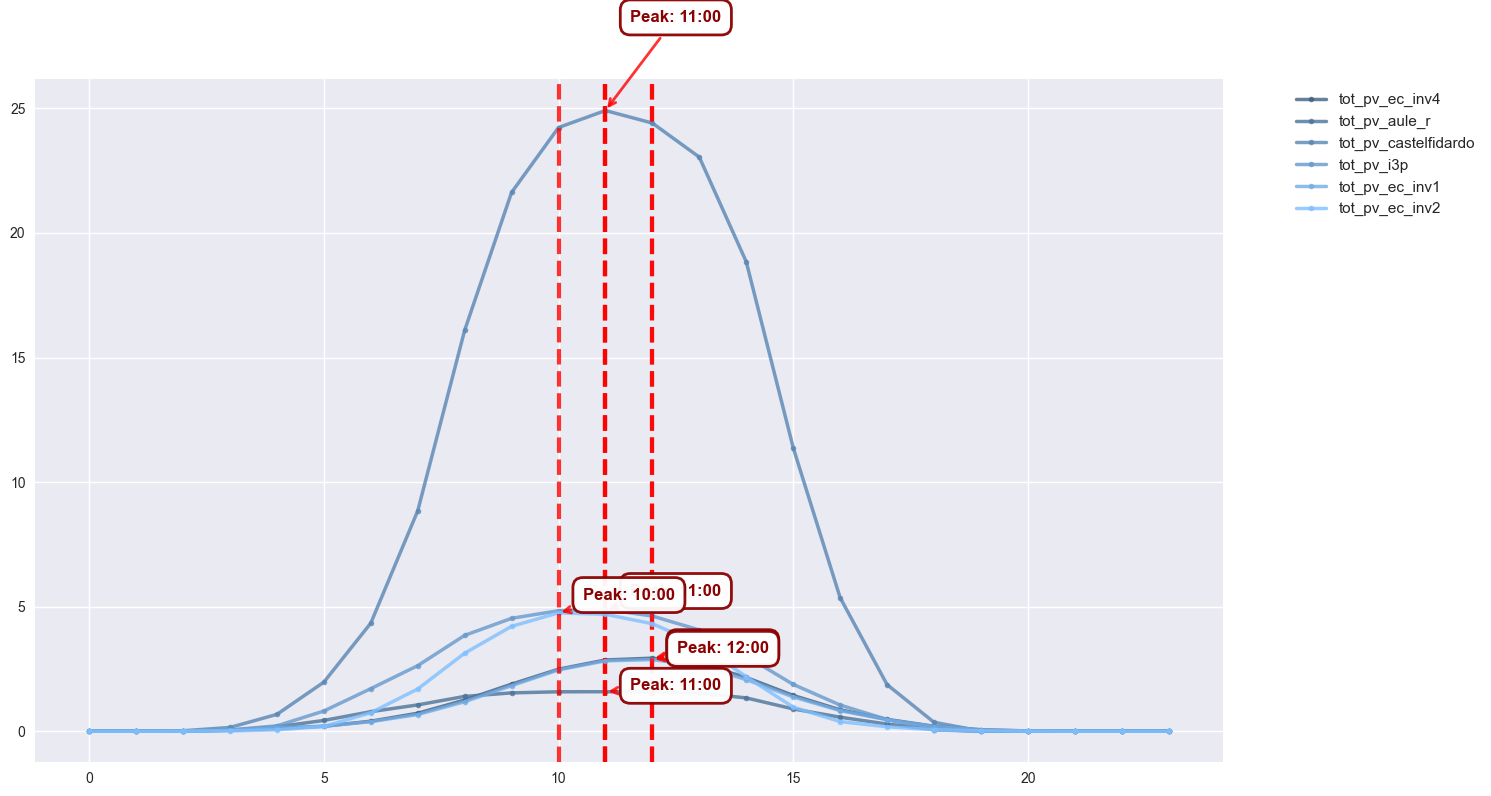

  Peak hours for Dataset 2: [np.int32(10), np.int32(11), np.int32(12)]
  Peak hours range from 10:00 to 12:00


Dataset 3:
Target columns: {'tot_pv_aule_p', 'tot_pv_aule_p_i2', 'tot_pv_aule_p_i1'}

Enhanced Hourly Analysis - Dataset 3
--------------------------------------------------
  tot_pv_aule_p: Peak at 11:00 (15.3 average)
  tot_pv_aule_p_i2: Peak at 11:00 (8.6 average)
  tot_pv_aule_p_i1: Peak at 11:00 (6.8 average)


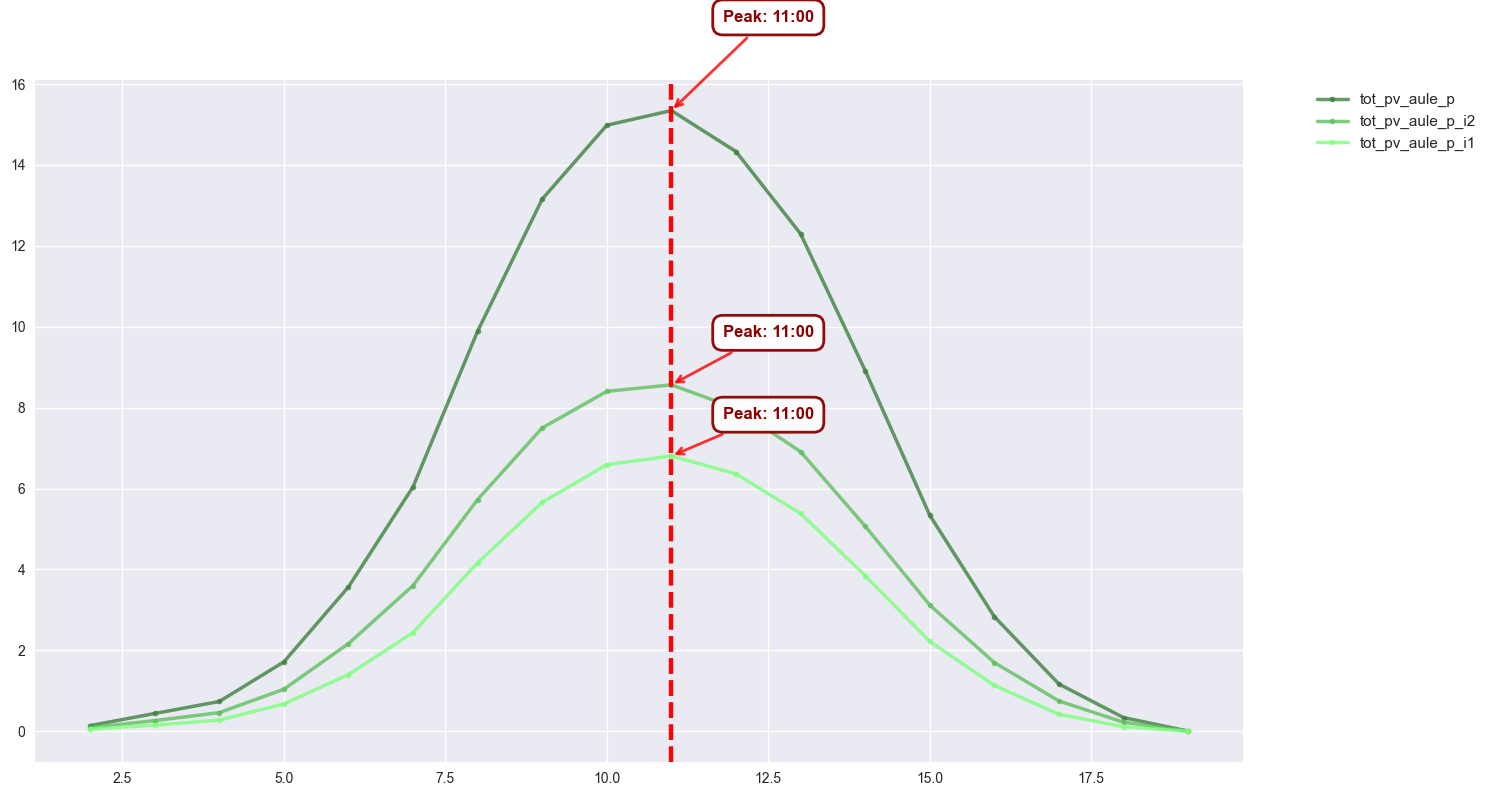

  Peak hours for Dataset 3: [np.int32(11)]
  All targets peak at the same hour: 11:00


Dataset 4:
Target columns: {'tot_pv_cit'}

Enhanced Hourly Analysis - Dataset 4
--------------------------------------------------
  tot_pv_cit: Peak at 11:00 (207.4 average)


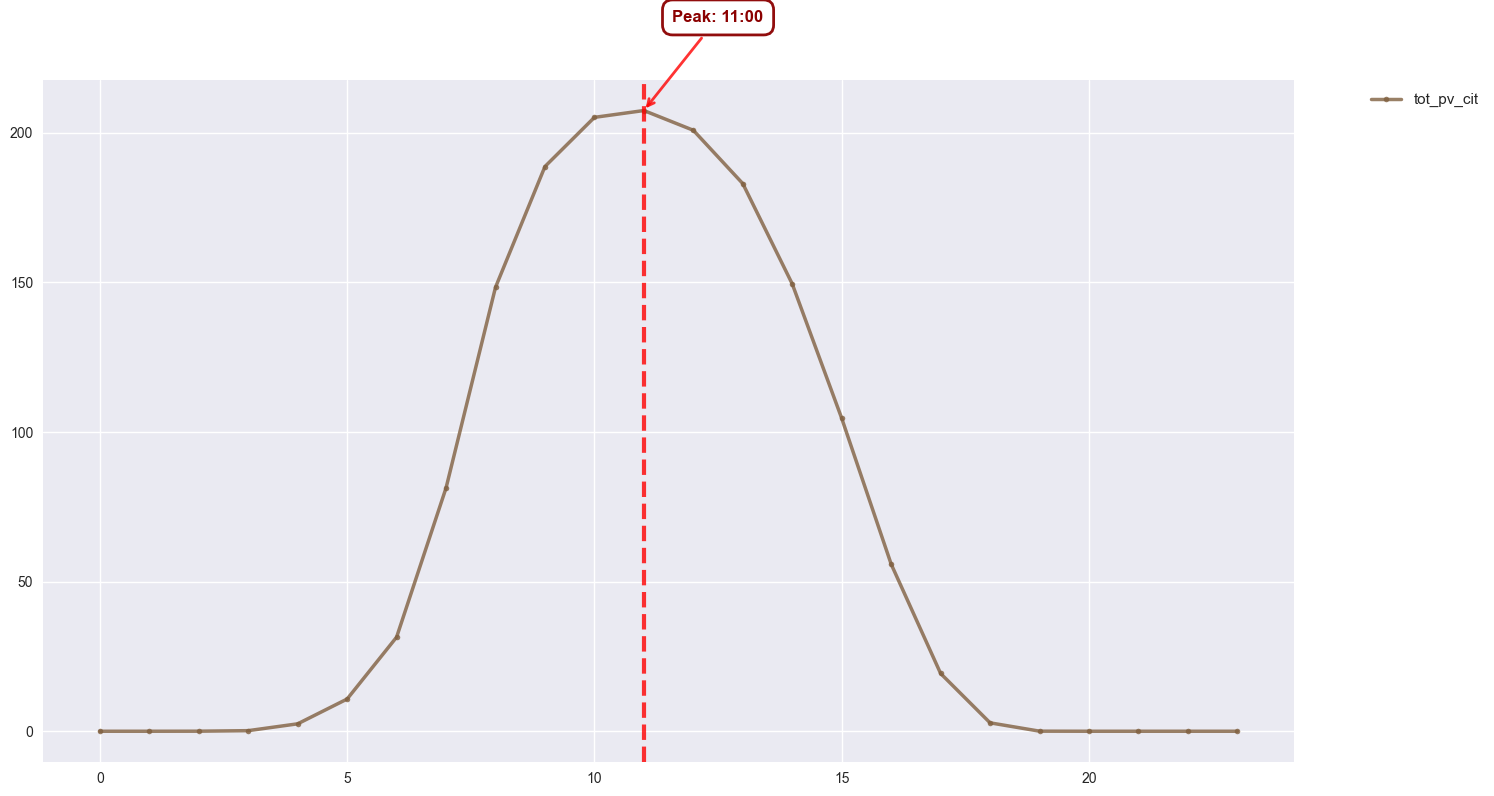

  Peak hours for Dataset 4: [np.int32(11)]
  All targets peak at the same hour: 11:00


I3P Dataset:
Target columns: {'tot_pv_i3p_est', 'tot_pv_i3p_ovest'}

Enhanced Hourly Analysis - I3P Dataset
--------------------------------------------------
  tot_pv_i3p_est: Peak at 10:00 (4.8 average)
  tot_pv_i3p_ovest: Peak at 12:00 (2.9 average)


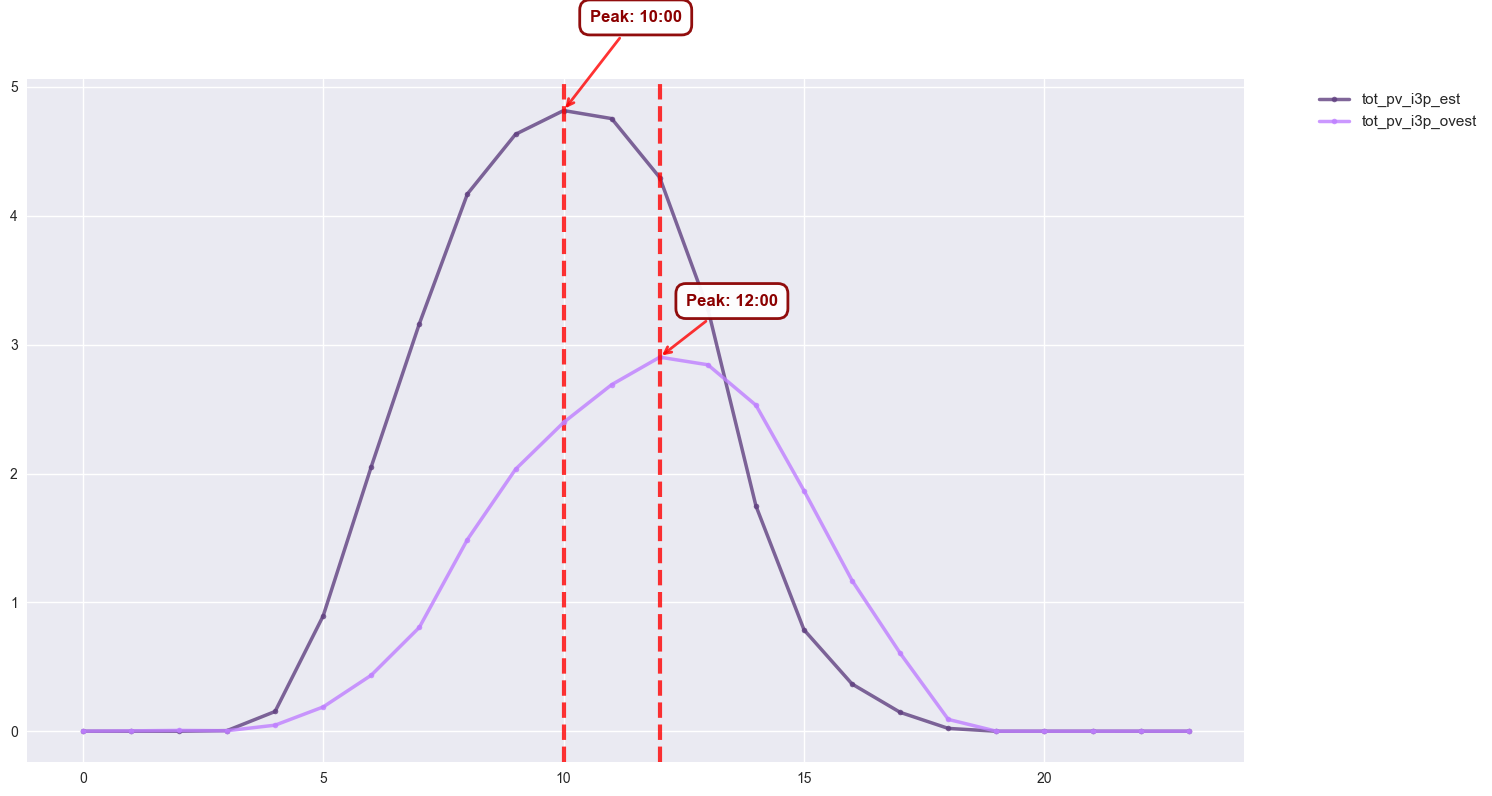

  Peak hours for I3P Dataset: [np.int32(10), np.int32(12)]
  Peak hours range from 10:00 to 12:00


ENHANCED HOURLY ANALYSIS WITH PEAK INDICATORS COMPLETE


In [13]:
from matplotlib.lines import Line2D

# Enhanced hourly analysis with vertical red lines for peak hours
print("=" * 100)
print("ENHANCED HOURLY ANALYSIS WITH PEAK INDICATORS")
print("=" * 100)

# Define dataset information with their dataframes and target columns
datasets_info = [
    {'name': 'Dataset 1', 'df': df1, 'targets': set(available_targets_1) - {'total_pv_production'}, 'color_base': '#ff7f7f'},
    {'name': 'Dataset 2', 'df': df2, 'targets': set(available_targets_2) - {'total_pv_production'}, 'color_base': '#7fbfff'},
    {'name': 'Dataset 3', 'df': df3, 'targets': set(available_targets_3) - {'total_pv_production'}, 'color_base': '#7fff7f'},
    {'name': 'Dataset 4', 'df': df4, 'targets': set(available_targets_4) - {'total_pv_production'}, 'color_base': '#ffbf7f'},
    {'name': 'I3P Dataset', 'df': df_i3p, 'targets': set(available_targets_i3p) - {'total_pv_production'}, 'color_base': '#bf7fff'}
]

# Function to generate color variations
def generate_colors(base_color, num_colors):
    import matplotlib.colors as mcolors
    base_rgb = mcolors.hex2color(base_color)
    return [tuple(min(1.0, c * (0.5 + i * 0.5 / max(1, num_colors - 1))) for c in base_rgb) for i in range(num_colors)]

# Process each dataset for enhanced hourly analysis
for dataset_info in datasets_info:
    dataset_name = dataset_info['name']
    df = dataset_info['df']
    targets = dataset_info['targets']
    base_color = dataset_info['color_base']
    
    print(f"\n{dataset_name}:")
    print(f"Target columns: {targets}")
    
    if not targets:
        print(f"No target columns found for {dataset_name}")
        continue
    
    df_copy = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'])
    df_copy.set_index('date', inplace=True)
    
    colors = generate_colors(base_color, len(targets))
    
    # Enhanced Hourly Analysis with Peak Indicators
    print(f"\nEnhanced Hourly Analysis - {dataset_name}")
    print("-" * 50)

    fig, ax = plt.subplots(figsize=(15, 8))
    peak_hours = []

    for i, target in enumerate(targets):
        if target in df_copy.columns:
            hourly_avg = df_copy.groupby(df_copy.index.hour)[target].mean()
            ax.plot(hourly_avg.index, hourly_avg.values,
                    label=f'{target}', color=colors[i], linewidth=2.5,
                    marker='o', markersize=4, alpha=0.8)
            
            if not hourly_avg.empty:
                peak_hour = hourly_avg.idxmax()
                peak_value = hourly_avg.max()
                peak_hours.append(peak_hour)

                # Add vertical red dashed line for peak hour
                ax.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.8, linewidth=3)
                
                # Add peak annotation with better readability
                ax.annotate(f'Peak: {peak_hour}:00',
                           xy=(peak_hour, peak_value),
                           xytext=(peak_hour + 1.5, peak_value * 1.15),
                           arrowprops=dict(arrowstyle='->', color='red', alpha=0.8, lw=2),
                           fontsize=12, color='darkred', fontweight='bold',
                           bbox=dict(boxstyle="round,pad=0.6", facecolor='white', alpha=0.95, 
                                   edgecolor='darkred', linewidth=2),
                           ha='center', va='center')
                
                print(f"  {target}: Peak at {peak_hour}:00 ({peak_value:.1f} average)")
    legend_labels = ax.get_legend_handles_labels()[1] + ['Peak Hours']

    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()
   

    # Summary of peak hours
    if peak_hours:
        unique_peaks = list(set(peak_hours))
        print(f"  Peak hours for {dataset_name}: {sorted(unique_peaks)}")
        if len(unique_peaks) == 1:
            print(f"  All targets peak at the same hour: {unique_peaks[0]}:00")
        else:
            print(f"  Peak hours range from {min(unique_peaks)}:00 to {max(unique_peaks)}:00")

    print(f"\n{'=' * 80}")

print("\n" + "=" * 100)
print("ENHANCED HOURLY ANALYSIS WITH PEAK INDICATORS COMPLETE")
print("=" * 100)